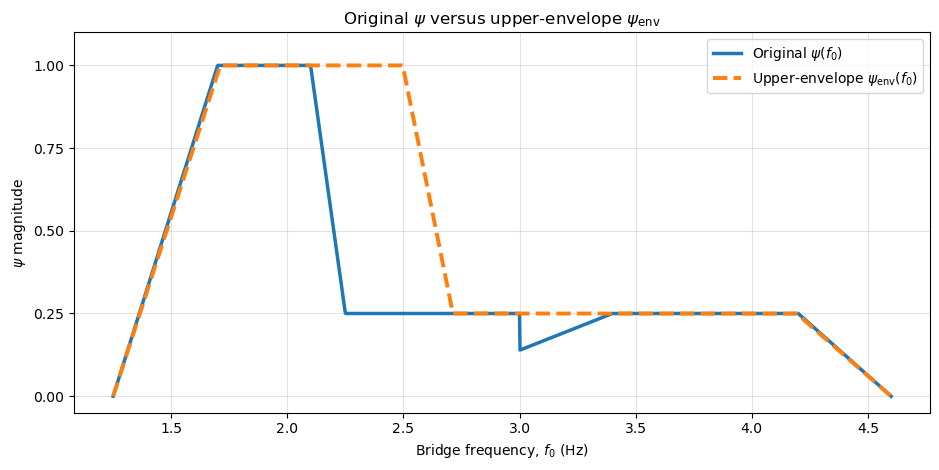

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_su

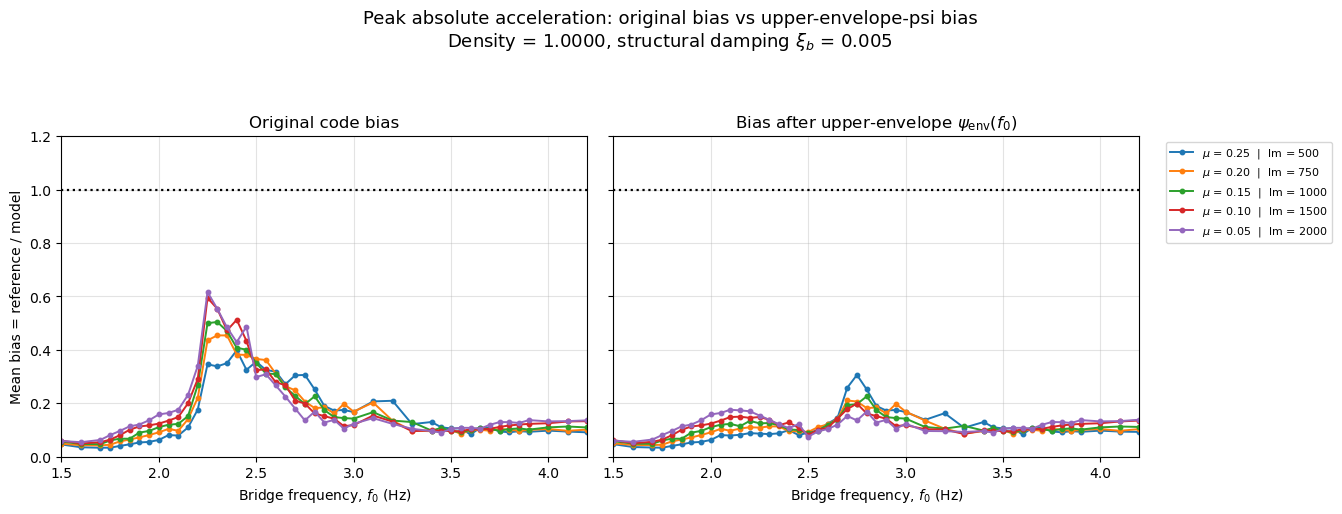

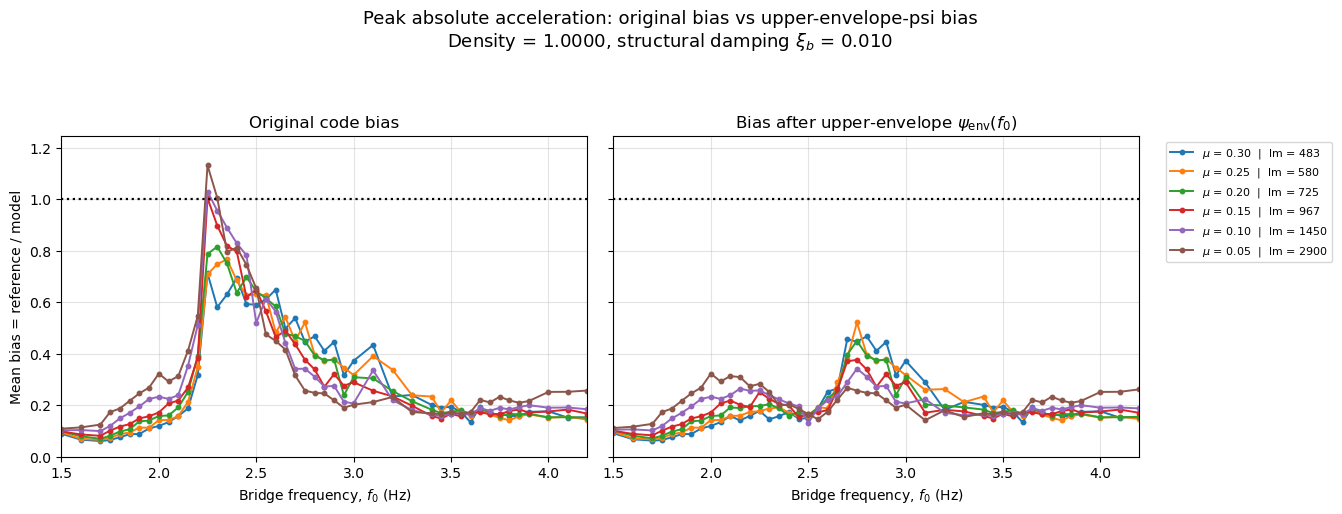

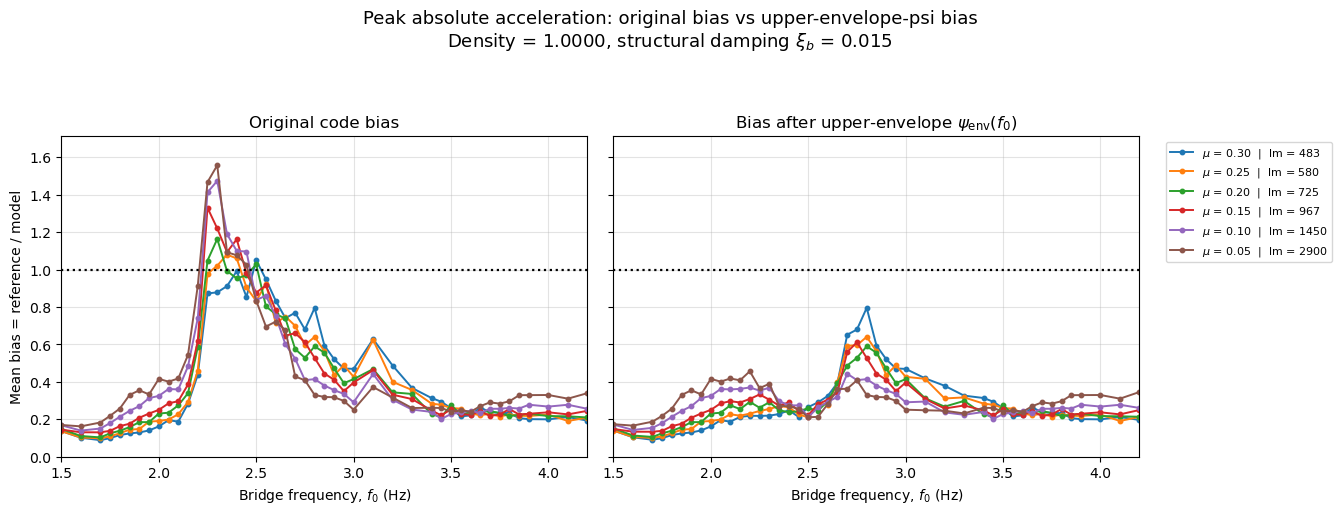

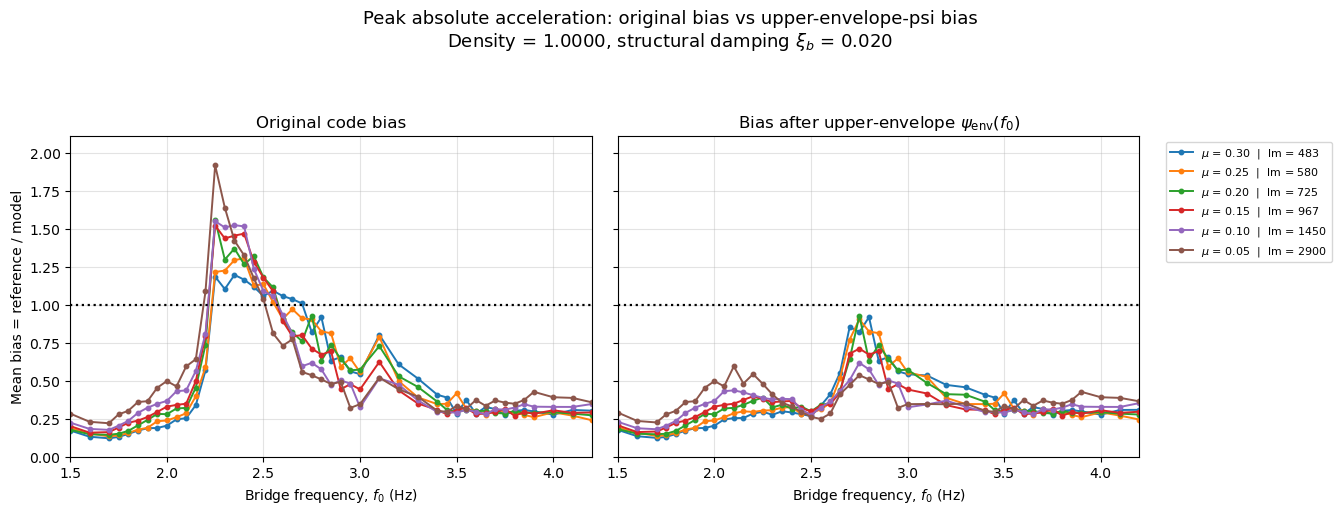

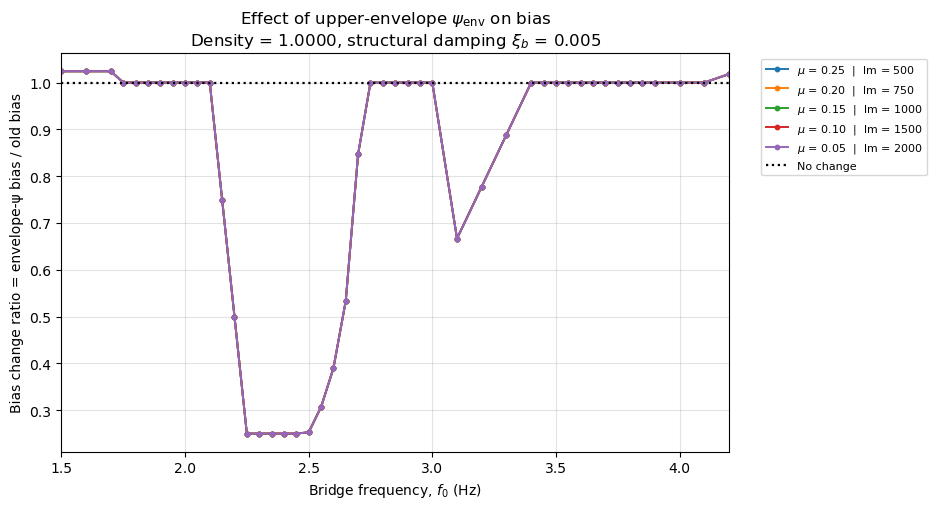

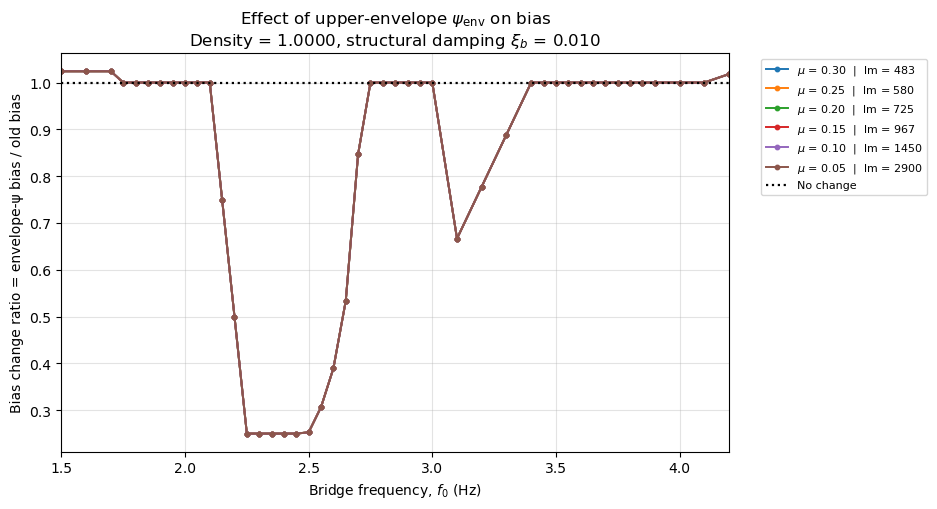

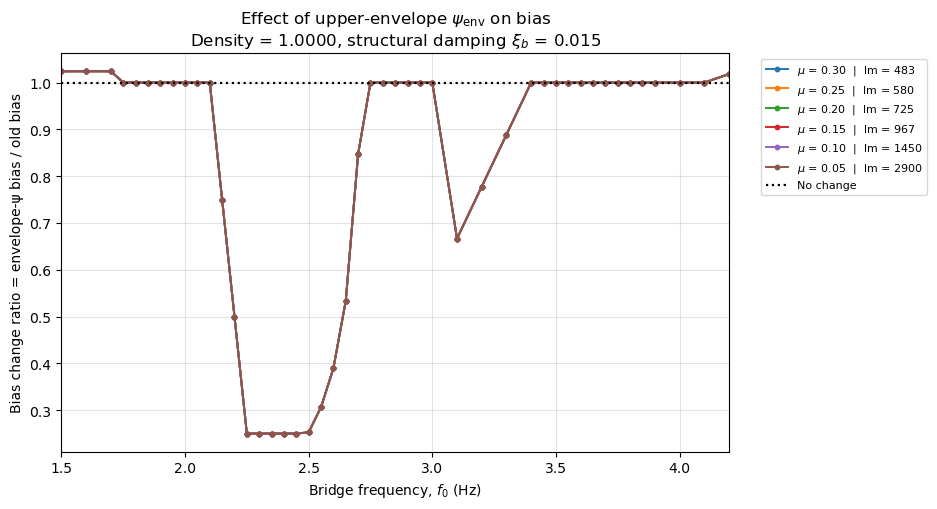

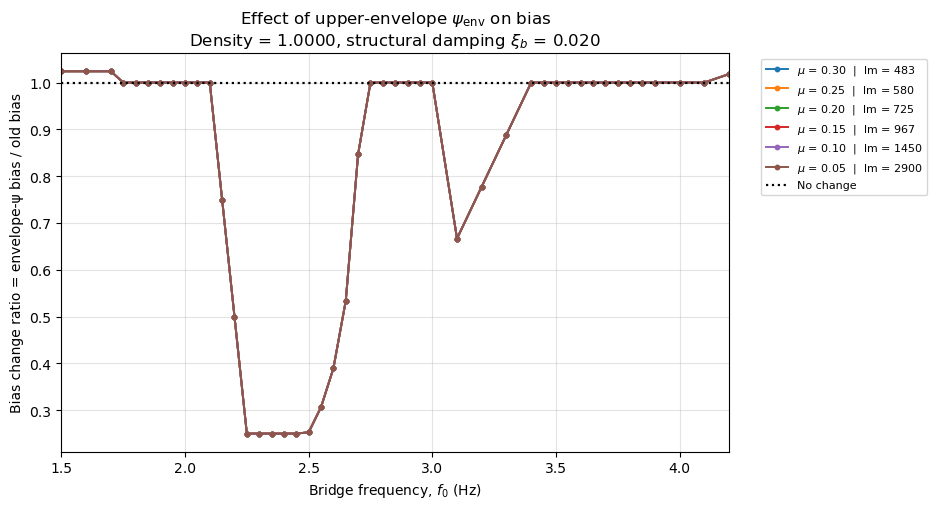


Summary table:
 damping_key  linear_mass_key  mass_ratio  old_bias_mean  env_bias_mean  old_bias_max  env_bias_max  mean_bias_change_ratio
       0.005              500        0.25       0.160823       0.108266      0.398131      0.306204                0.831589
       0.005              750        0.20       0.167101       0.108297      0.454150      0.210449                0.831589
       0.005             1000        0.15       0.173092       0.112188      0.504448      0.226072                0.831589
       0.005             1500        0.10       0.181362       0.116096      0.594561      0.198859                0.831589
       0.005             2000        0.05       0.184129       0.119601      0.616419      0.175922                0.831589
       0.010              483        0.30       0.291698       0.195941      0.712788      0.467535                0.831589
       0.010              580        0.25       0.296683       0.196153      0.766111      0.521570                0

In [23]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Use None to load all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column you plotted as original bias / correction factor
OLD_BIAS_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

SAVE_FIGURES = False
FIG_DPI = 300

PSI_EPS = 1e-8


# ==================================================
# LINEAR MASS TO MASS RATIO
# Edit this table only if your lm values are different.
# ==================================================

linear_mass_to_mass_ratio = {
    483:  0.30,
    500:  0.30,

    580:  0.25,
    500:  0.25,

    725:  0.20,
    750:  0.20,

    967:  0.15,
    1000: 0.15,

    1450: 0.10,
    1500: 0.10,

    2000: 0.05,
    2900: 0.05,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# UPPER-ENVELOPE PSI FUNCTION
#
# Your suggested envelope:
#
# For 1.2500 <= f0 <= 1.7109: psi_env =  2.169878*f0 - 2.712347
# For 1.7109 <= f0 <= 2.4968: psi_env =  1.000000
# For 2.4968 <= f0 <= 2.7130: psi_env = -3.469281*f0 + 9.662183
# For 2.7130 <= f0 <= 4.1928: psi_env =  0.250000
# For 4.1928 <= f0 <= 4.6000: psi_env = -0.613906*f0 + 2.823967
# ==================================================

def psi_upper_envelope(f):
    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # Breakpoints
    f_start = 1.2500
    a = 1.7109
    b = 2.4968
    c = 2.7130
    d = 4.1928
    f_end = 4.6000

    # Segment 1: ramp from 0 to 1
    m = (f >= f_start) & (f < a)
    psi[m] = 2.169878 * f[m] - 2.712347

    # Segment 2: plateau at 1
    m = (f >= a) & (f < b)
    psi[m] = 1.0

    # Segment 3: ramp from 1 to 0.25
    m = (f >= b) & (f < c)
    psi[m] = -3.469281 * f[m] + 9.662183

    # Segment 4: plateau at 0.25
    m = (f >= c) & (f < d)
    psi[m] = 0.25

    # Segment 5: ramp from 0.25 to 0
    m = (f >= d) & (f <= f_end)
    psi[m] = -0.613906 * f[m] + 2.823967

    # Outside range: keep zero
    psi = np.clip(psi, 0.0, 1.0)

    return psi


# ==================================================
# QUICK CHECK: PLOT OLD PSI VS UPPER-ENVELOPE PSI
# ==================================================

f_check = np.linspace(1.25, 4.60, 1500)

plt.figure(figsize=(9.5, 4.8))

plt.plot(
    f_check,
    psi_original(f_check),
    linewidth=2.5,
    label=r"Original $\psi(f_0)$"
)

plt.plot(
    f_check,
    psi_upper_envelope(f_check),
    "--",
    linewidth=2.8,
    label=r"Upper-envelope $\psi_{\mathrm{env}}(f_0)$"
)

plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$ magnitude")
plt.title(r"Original $\psi$ versus upper-envelope $\psi_{\mathrm{env}}$")
plt.ylim(-0.05, 1.10)
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# LOAD lm BIAS FILES
# Expected:
# density1.0000_damping0.005_lm483_bias_summary.pkl
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm bias summary files found.")

raw_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded lm dataframe shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())


# ==================================================
# CLEAN lm DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    OLD_BIAS_COL,
]

for col in needed_cols:
    if col not in raw_df.columns:
        raise KeyError(f"Missing required column: {col}")

    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df = raw_df.dropna(subset=needed_cols).copy()

# Keep peak absolute acceleration only
if "measure" in raw_df.columns:
    raw_df = raw_df[
        raw_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if raw_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'."
        )

raw_df["damping_key"] = raw_df["target_beamdamp"].round(3)
raw_df["linear_mass_key"] = raw_df["linear_mass"].round(0).astype(int)

raw_df = raw_df[
    (raw_df["bridge_frequency"] >= PLOT_FMIN) &
    (raw_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# Stable mass-ratio label from lm
raw_df["mass_ratio"] = raw_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

missing_lm = sorted(
    raw_df.loc[raw_df["mass_ratio"].isna(), "linear_mass_key"].unique()
)

if len(missing_lm) > 0:
    raise ValueError(
        "These linear masses are missing from linear_mass_to_mass_ratio:\n"
        f"{missing_lm}\n\n"
        "Add them to the dictionary near the top."
    )

# Average only exact duplicate points
compare_df = (
    raw_df
    .groupby(
        ["damping_key", "linear_mass_key", "mass_ratio", "bridge_frequency"],
        as_index=False
    )
    .agg(old_bias=(OLD_BIAS_COL, "mean"))
    .sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )
)

print("\nFinal comparison dataframe shape:", compare_df.shape)

print("\nAvailable lm and mass-ratio mapping:")
print(
    compare_df[["linear_mass_key", "mass_ratio"]]
    .drop_duplicates()
    .sort_values("mass_ratio", ascending=False)
    .to_string(index=False)
)

print("\nFrequency coverage:")
coverage = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# COMPUTE BIAS IF UPPER-ENVELOPE PSI IS USED
# ==================================================

compare_df["psi_old"] = psi_original(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

compare_df["psi_env"] = psi_upper_envelope(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

psi_old_safe = np.maximum(
    compare_df["psi_old"].to_numpy(dtype=float),
    PSI_EPS
)

psi_env_safe = np.maximum(
    compare_df["psi_env"].to_numpy(dtype=float),
    PSI_EPS
)

# Model_new = Model_old * psi_env / psi_old
# Bias = Reference / Model
# Therefore:
# Bias_new = Bias_old * psi_old / psi_env

compare_df["env_bias"] = (
    compare_df["old_bias"] * psi_old_safe / psi_env_safe
)

compare_df["bias_ratio_env_over_old"] = (
    compare_df["env_bias"] / compare_df["old_bias"]
)

compare_df["psi_scale_env_over_old"] = (
    psi_env_safe / psi_old_safe
)

compare_df.to_csv(
    "old_vs_upper_envelope_psi_bias_from_lm_files.csv",
    index=False
)

print("\nSaved: old_vs_upper_envelope_psi_bias_from_lm_files.csv")


# ==================================================
# PLOT OLD BIAS VS UPPER-ENVELOPE-PSI BIAS
# One figure per damping ratio.
# Each figure has all lm / mass-ratio lines.
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("env_bias", r"Bias after upper-envelope $\psi_{\mathrm{env}}(f_0)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for lm in sorted(damp_df["linear_mass_key"].unique()):

            sub = damp_df[
                damp_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            mu = sub["mass_ratio"].iloc[0]

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.4,
                label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        damp_df[["old_bias", "env_bias"]].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs upper-envelope-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_upper_envelope_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_damping{damping:.3f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()


# ==================================================
# OPTIONAL: PLOT HOW MUCH THE BIAS CHANGES
# env_bias / old_bias
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    plt.figure(figsize=(9.5, 5.2))

    for lm in sorted(damp_df["linear_mass_key"].unique()):

        sub = damp_df[
            damp_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu = sub["mass_ratio"].iloc[0]

        plt.plot(
            sub["bridge_frequency"],
            sub["bias_ratio_env_over_old"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.6,
        color="black",
        label="No change"
    )

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Bias change ratio = envelope-ψ bias / old bias")

    plt.title(
        r"Effect of upper-envelope $\psi_{\mathrm{env}}$ on bias"
        "\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


# ==================================================
# OPTIONAL: SUMMARY TABLE
# ==================================================

summary_df = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"], as_index=False)
    .agg(
        old_bias_mean=("old_bias", "mean"),
        env_bias_mean=("env_bias", "mean"),
        old_bias_max=("old_bias", "max"),
        env_bias_max=("env_bias", "max"),
        mean_bias_change_ratio=("bias_ratio_env_over_old", "mean"),
    )
    .sort_values(["damping_key", "mass_ratio"], ascending=[True, False])
)

print("\nSummary table:")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    "summary_upper_envelope_psi_bias_effect.csv",
    index=False
)

print("\nSaved: summary_upper_envelope_psi_bias_effect.csv")


RAW P95 FACTORS AFTER PSI-ENVELOPE CORRECTION

Percentile = P95
Frequency range = 1.50 - 4.20 Hz

Definition:
C95_raw(mu, xi_b) = P95[env_bias(f)] across frequency

P95 values:

 mass_ratio  damping  p95_factor  n_frequency_points
   0.050000 0.005000    0.169882                  46
   0.100000 0.005000    0.159411                  46
   0.150000 0.005000    0.188448                  46
   0.200000 0.005000    0.194412                  46
   0.250000 0.005000    0.236357                  46
   0.050000 0.010000    0.304946                  46
   0.100000 0.010000    0.285556                  46
   0.150000 0.010000    0.334540                  46
   0.200000 0.010000    0.389106                  46
   0.250000 0.010000    0.380176                  46
   0.300000 0.010000    0.446751                  46
   0.050000 0.015000    0.414026                  46
   0.100000 0.015000    0.402034                  46
   0.150000 0.015000    0.506524                  46
   0.200000 0.015000    0.

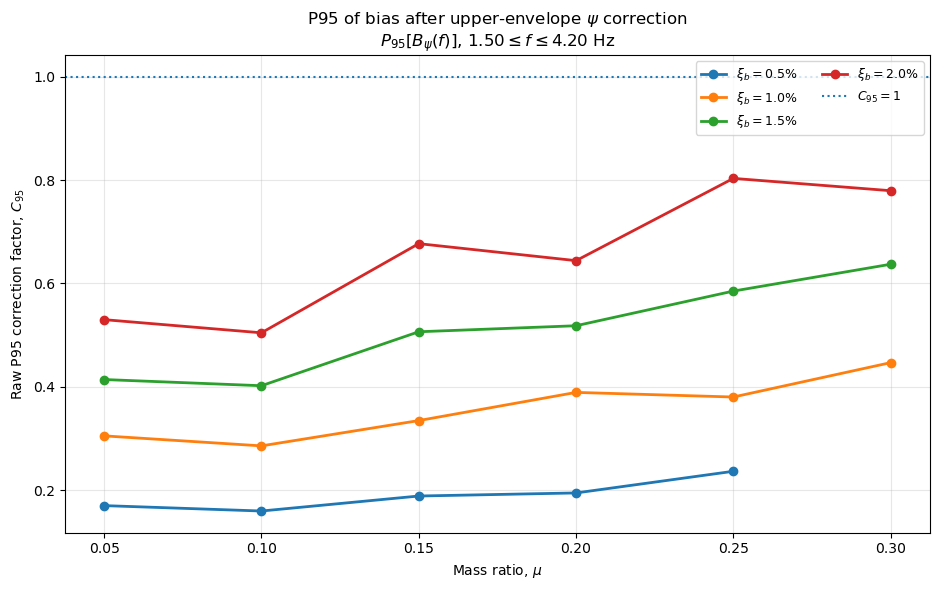

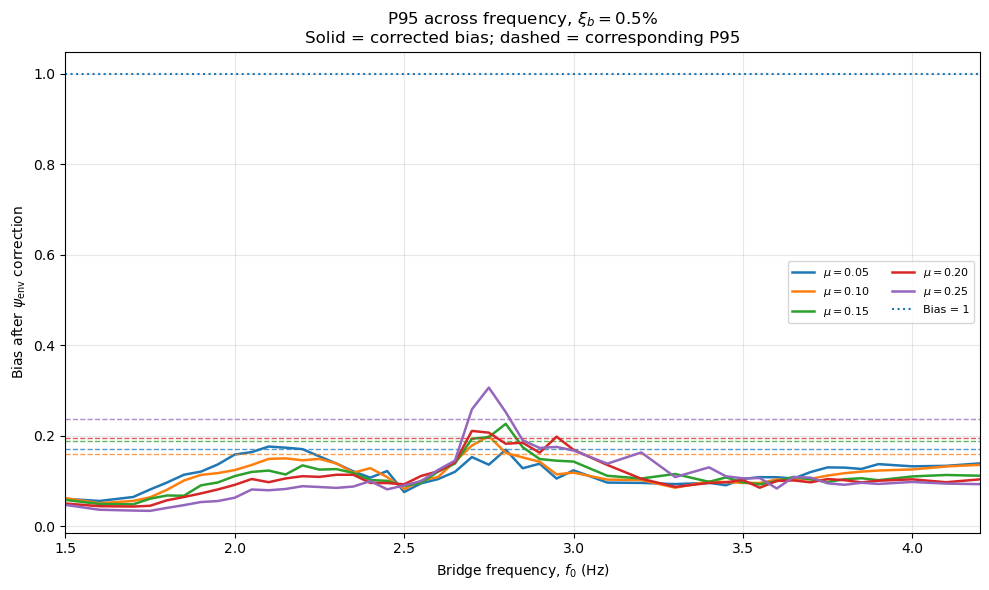

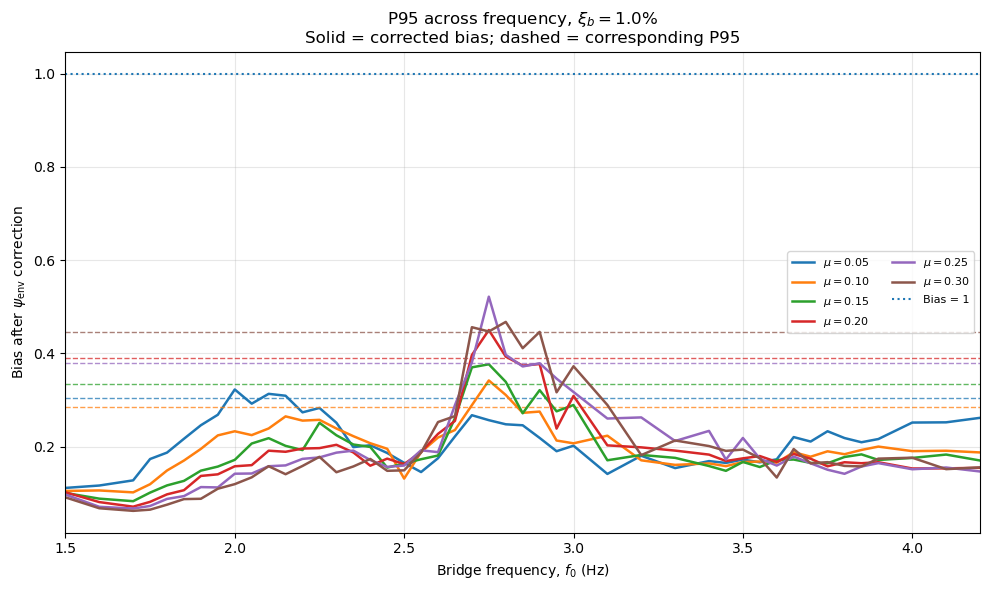

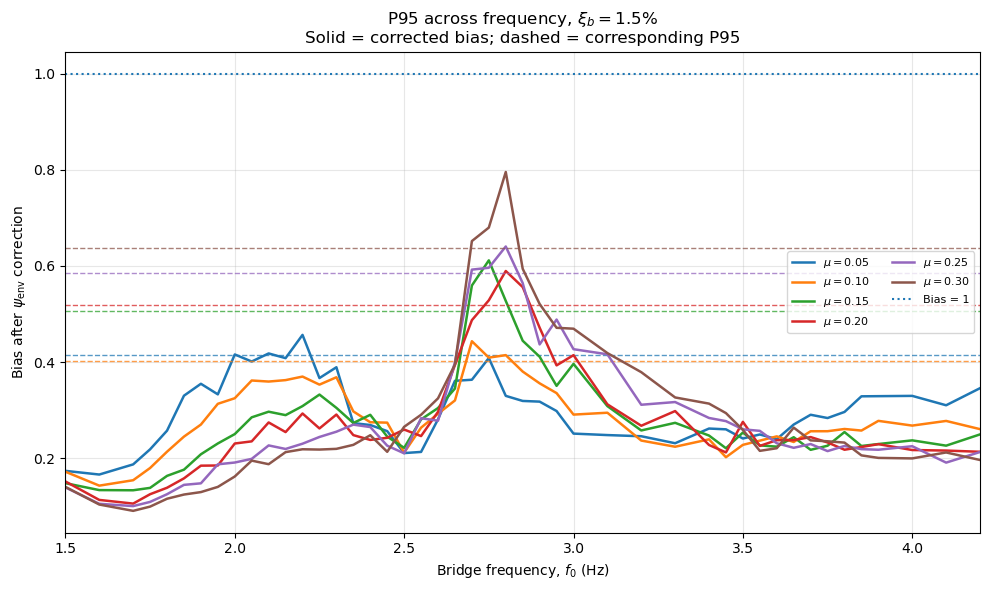

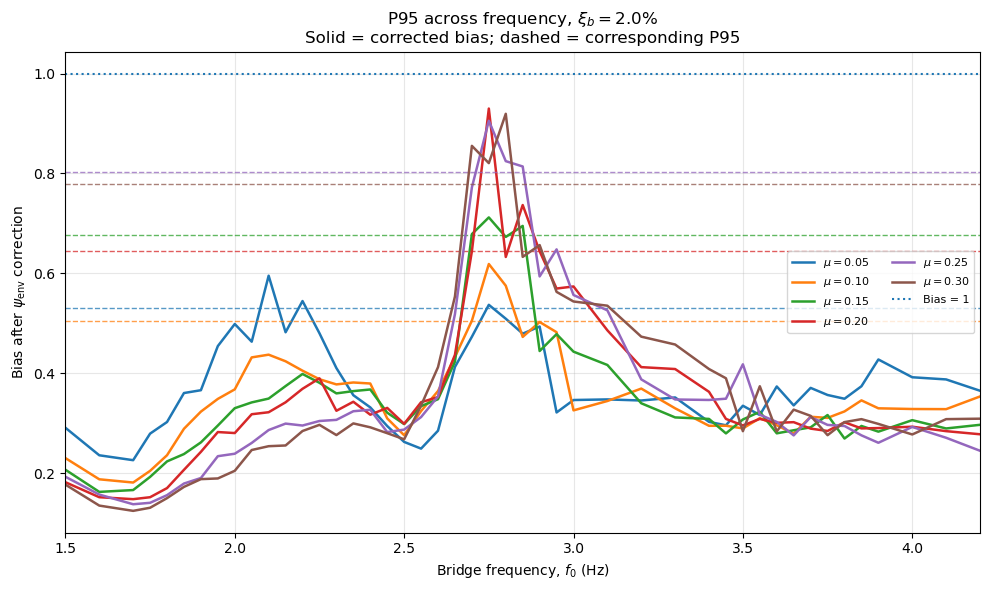


Saved:
P95_upper_envelope_psi_factors.csv


In [24]:
# ============================================================
# P95 OF BIAS AFTER PSI-ENVELOPE CORRECTION
#
# For every (mu, xi_b):
#
#     C95_raw(mu, xi_b)
#         = P95[ env_bias(f) ]
#
# Percentile is taken ACROSS FREQUENCY.
#
# Current frequency range:
#
#     1.50 <= f <= 4.20 Hz
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

PERCENTILE = 95

BIAS_COLUMN = "env_bias"

P95_FMIN = 1.50
P95_FMAX = 4.20

EPS = 1e-12


# ============================================================
# 1. CHECK INPUT
# ============================================================

if "compare_df" not in globals():

    raise NameError(
        "compare_df does not exist. "
        "Run the loading + psi correction cell first."
    )


if BIAS_COLUMN not in compare_df.columns:

    raise KeyError(
        f"{BIAS_COLUMN} is missing from compare_df."
    )


# ============================================================
# 2. COPY DATA
# ============================================================

p95_work_df = compare_df.copy()


# ============================================================
# 3. NUMERIC CLEANING
# ============================================================

for col in [
    "bridge_frequency",
    "damping_key",
    "linear_mass_key",
    "mass_ratio",
    BIAS_COLUMN,
]:

    p95_work_df[col] = pd.to_numeric(
        p95_work_df[col],
        errors="coerce"
    )


p95_work_df = p95_work_df.dropna(
    subset=[
        "bridge_frequency",
        "damping_key",
        "mass_ratio",
        BIAS_COLUMN,
    ]
).copy()


# ============================================================
# 4. FREQUENCY RANGE
# ============================================================

p95_work_df = p95_work_df[
    (
        p95_work_df["bridge_frequency"]
        >= P95_FMIN
    )
    &
    (
        p95_work_df["bridge_frequency"]
        <= P95_FMAX
    )
].copy()


# ============================================================
# 5. HANDLE MULTIPLE lm VALUES MAPPING TO SAME mu
#
# Average duplicate representations at each frequency first,
# then calculate the percentile across frequency.
# ============================================================

p95_frequency_df = (

    p95_work_df

    .groupby(
        [
            "damping_key",
            "mass_ratio",
            "bridge_frequency",
        ],
        as_index=False
    )

    .agg(
        env_bias=(
            BIAS_COLUMN,
            "mean"
        )
    )

    .sort_values(
        [
            "damping_key",
            "mass_ratio",
            "bridge_frequency",
        ]
    )
)


# ============================================================
# 6. CALCULATE RAW P95 FACTOR ACROSS FREQUENCY
# ============================================================

rows = []


for (
    damping,
    mass_ratio
), sub in p95_frequency_df.groupby(
    [
        "damping_key",
        "mass_ratio",
    ]
):

    sub = sub.sort_values(
        "bridge_frequency"
    )


    y = sub[
        "env_bias"
    ].to_numpy(
        dtype=float
    )


    f = sub[
        "bridge_frequency"
    ].to_numpy(
        dtype=float
    )


    valid = (

        np.isfinite(y)

        &

        np.isfinite(f)

        &

        (y > EPS)
    )


    y = y[valid]
    f = f[valid]


    if len(y) == 0:

        continue


    C95 = np.percentile(
        y,
        PERCENTILE
    )


    rows.append({

        "damping":
            float(damping),

        "mass_ratio":
            float(mass_ratio),

        "p95_factor":
            float(C95),

        "n_frequency_points":
            len(y),

        "frequency_min":
            np.min(f),

        "frequency_max":
            np.max(f),

        "bias_min":
            np.min(y),

        "bias_mean":
            np.mean(y),

        "bias_max":
            np.max(y),
    })


p95_factor_df = pd.DataFrame(
    rows
)


p95_factor_df = (

    p95_factor_df

    .sort_values(
        [
            "damping",
            "mass_ratio",
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. PRINT TABLE
# ============================================================

print(
    "\n============================================================"
)

print(
    "RAW P95 FACTORS AFTER PSI-ENVELOPE CORRECTION"
)

print(
    "============================================================"
)


print(
    f"\nPercentile = P{PERCENTILE}"
)


print(
    f"Frequency range = "
    f"{P95_FMIN:.2f} - {P95_FMAX:.2f} Hz"
)


print(
    "\nDefinition:"
)


print(
    "C95_raw(mu, xi_b) = "
    "P95[env_bias(f)] across frequency"
)


print(
    "\nP95 values:\n"
)


print(

    p95_factor_df[
        [
            "mass_ratio",
            "damping",
            "p95_factor",
            "n_frequency_points",
        ]
    ]

    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 8. PLOT P95 VS MASS RATIO
#
# One curve for each damping ratio.
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.5, 6.0)
)


for damping in sorted(
    p95_factor_df[
        "damping"
    ].unique()
):


    sub = p95_factor_df[

        np.isclose(
            p95_factor_df[
                "damping"
            ],
            damping
        )

    ].copy()


    sub = sub.sort_values(
        "mass_ratio"
    )


    ax.plot(

        sub[
            "mass_ratio"
        ],

        sub[
            "p95_factor"
        ],

        marker="o",

        markersize=6,

        linewidth=2.0,

        label=(
            rf"$\xi_b={100*damping:.1f}\%$"
        )
    )


ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.5,
    label=r"$C_{95}=1$"
)


ax.set_xlabel(
    r"Mass ratio, $\mu$"
)


ax.set_ylabel(
    r"Raw P95 correction factor, $C_{95}$"
)


ax.set_title(
    r"P95 of bias after upper-envelope $\psi$ correction"
    "\n"
    rf"$P_{{95}}[B_\psi(f)]$, "
    rf"${P95_FMIN:.2f}\leq f\leq{P95_FMAX:.2f}$ Hz"
)


ax.grid(
    True,
    alpha=0.30
)


ax.legend(
    ncol=2,
    fontsize=9
)


plt.tight_layout()

plt.show()


# ============================================================
# 9. SHOW FREQUENCY CURVES + THEIR P95 LEVELS
#
# Solid  = corrected bias along frequency
# Dashed = corresponding P95
# ============================================================

for damping in sorted(
    p95_factor_df[
        "damping"
    ].unique()
):


    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    damp_df = p95_frequency_df[

        np.isclose(
            p95_frequency_df[
                "damping_key"
            ],
            damping
        )

    ].copy()


    for mass_ratio in sorted(
        damp_df[
            "mass_ratio"
        ].unique()
    ):


        sub = damp_df[

            np.isclose(
                damp_df[
                    "mass_ratio"
                ],
                mass_ratio
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        line, = ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "env_bias"
            ],

            linewidth=1.8,

            label=(
                rf"$\mu={mass_ratio:.2f}$"
            )
        )


        row = p95_factor_df[

            np.isclose(
                p95_factor_df[
                    "damping"
                ],
                damping
            )

            &

            np.isclose(
                p95_factor_df[
                    "mass_ratio"
                ],
                mass_ratio
            )

        ]


        if not row.empty:

            C95 = float(
                row.iloc[0][
                    "p95_factor"
                ]
            )


            ax.hlines(

                C95,

                xmin=P95_FMIN,

                xmax=P95_FMAX,

                color=line.get_color(),

                linestyle="--",

                linewidth=1.0,

                alpha=0.75
            )


    ax.axhline(
        1.0,
        linestyle=":",
        linewidth=1.5,
        label="Bias = 1"
    )


    ax.set_xlim(
        P95_FMIN,
        P95_FMAX
    )


    ax.set_xlabel(
        r"Bridge frequency, $f_0$ (Hz)"
    )


    ax.set_ylabel(
        r"Bias after $\psi_{\mathrm{env}}$ correction"
    )


    ax.set_title(

        rf"P95 across frequency, "
        rf"$\xi_b={100*damping:.1f}\%$"

        "\n"

        r"Solid = corrected bias; "
        r"dashed = corresponding P95"
    )


    ax.grid(
        True,
        alpha=0.30
    )


    ax.legend(
        ncol=2,
        fontsize=8
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 10. SAVE
# ============================================================

p95_factor_df.to_csv(

    "P95_upper_envelope_psi_factors.csv",

    index=False,

    encoding="utf-8-sig"
)


print(
    "\nSaved:"
    "\nP95_upper_envelope_psi_factors.csv"
)


Raw P95 data used for surface fitting:


,mass_ratio,xi_b,P95_bias
0,0.05,0.005,0.169882
1,0.10,0.005,0.159411
2,0.15,0.005,0.188448
3,0.20,0.005,0.194412
4,0.25,0.005,0.236357
5,0.05,0.010,0.304946
6,0.10,0.010,0.285556
7,0.15,0.010,0.334540
8,0.20,0.010,0.389106
9,0.25,0.010,0.380176



Candidate polynomial surfaces:


,degree_mu,degree_xi,n_coefficients,full_rank_in_all_folds,minimum_fold_rank,LODO_CV_R2,LODO_CV_RMSE,LODO_CV_MAE
0,1,1,4,True,4,0.97496,0.029633,0.02455



Comparison of the two polynomial surfaces:


,surface,degree_mu,degree_xi,n_coefficients,R2_fit,adjusted_R2_fit,RMSE_fit,R2_final,RMSE_final,intercept_correction,LODO_CV_R2,LODO_CV_RMSE,LODO_CV_MAE
0,"(1,1)",1,1,4,0.976919,0.973275,0.02845,0.678108,0.106246,0.102366,0.97496,0.029633,0.02455



Selected surface based on minimum LODO-CV RMSE:
Degree in mu   = 1
Degree in xi_b = 1

TWO-VARIABLE P95 CORRECTION-FACTOR SURFACE

Calibration domain:
0.0500 <= mu <= 0.3000
0.0050 <= xi_b <= 0.0200

Normalised variables:
u = (mu - 0.17500000)/0.12500000
z = (xi_b - 0.01250000)/0.00750000

------------------------------------------------------------
1. LEAST-SQUARES SURFACE
------------------------------------------------------------

C95_model2_fit(mu, xi_b) =
0.04158216 + 20.23948843*xi_b + 0.04150542*mu + 58.88410158*mu*xi_b

R²_fit          = 0.976919
Adjusted R²_fit = 0.973275
RMSE_fit        = 0.028450
MAE_fit         = 0.023813

------------------------------------------------------------
2. FINAL CONSERVATIVE SURFACE
------------------------------------------------------------

C95_model2_final(mu, xi_b) =
0.14394804 + 20.23948843*xi_b + 0.04150542*mu + 58.88410158*mu*xi_b

Intercept correction = +0.10236588
R²_final             = 0.678108
RMSE_final           = 0.106246
MAE_f

,mass_ratio,xi_b,P95_bias,surface_fit,surface_final,raw_minus_fit,final_minus_raw
0,0.05,0.005,0.169882,0.159576,0.261942,0.010306,0.092060
1,0.10,0.005,0.159411,0.176372,0.278738,-0.016961,0.119327
2,0.15,0.005,0.188448,0.193168,0.295534,-0.004721,0.107087
3,0.20,0.005,0.194412,0.209965,0.312331,-0.015553,0.117919
4,0.25,0.005,0.236357,0.226761,0.329127,0.009596,0.092770
5,0.05,0.010,0.304946,0.275494,0.377860,0.029451,0.072915
6,0.10,0.010,0.285556,0.307012,0.409378,-0.021456,0.123822
7,0.15,0.010,0.334540,0.338529,0.440895,-0.003989,0.106355
8,0.20,0.010,0.389106,0.370046,0.472412,0.019060,0.083306
9,0.25,0.010,0.380176,0.401564,0.503930,-0.021388,0.123754



Minimum final-minus-raw margin:
0.050000000000000044

DOMAIN CHECK

Least-squares surface:
Minimum = 0.159576 at mu=0.050000, xi_b=0.005000
Maximum = 0.812128 at mu=0.300000, xi_b=0.020000
The equation remains between 0 and 1 over the calibrated domain.

Final conservative surface:
Minimum = 0.261942 at mu=0.050000, xi_b=0.005000
Maximum = 0.914494 at mu=0.300000, xi_b=0.020000
The equation remains between 0 and 1 over the calibrated domain.


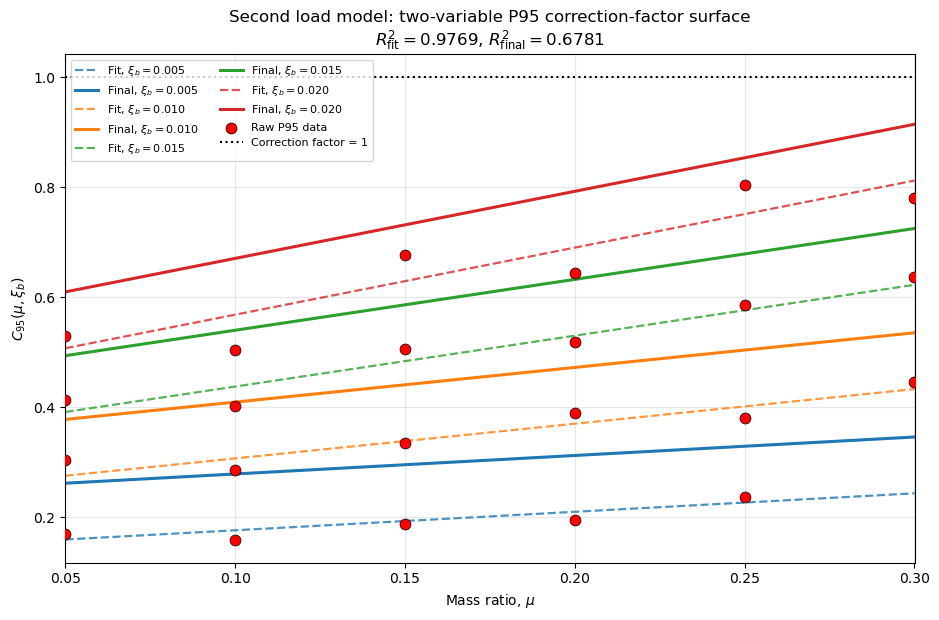

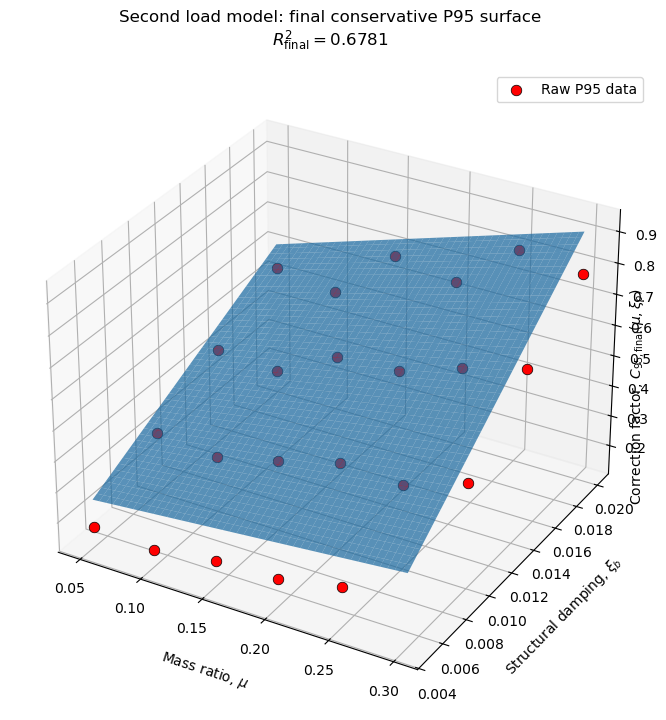

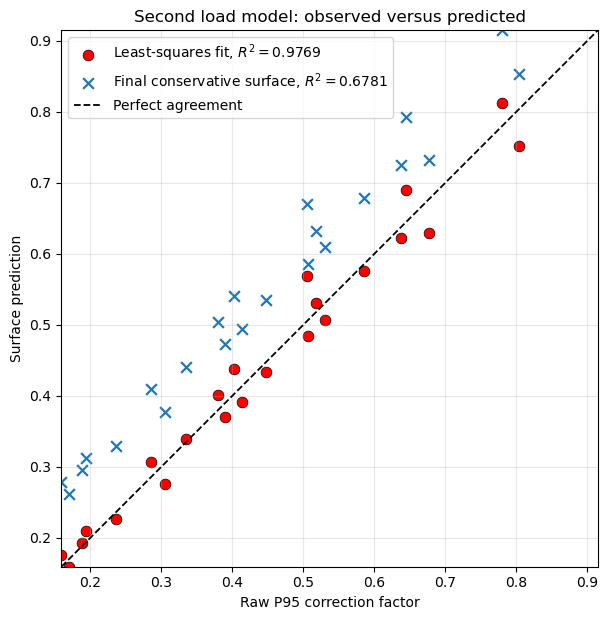


Example evaluation:
mu       = 0.1800
xi_b     = 0.0120
C95_fit  = 0.419117
C95_final= 0.521483


In [35]:
# ============================================================
# TWO-VARIABLE P95 CORRECTION-FACTOR SURFACE
# FOR THE SECOND LOAD MODEL
#
# Raw dataframe:
#
#     bias_percentile_df
#
# Required columns:
#
#     mass_ratio
#     xi_b
#     P95_bias
#
# Fits directly:
#
#     C95 = C95(mu, xi_b)
#
# Produces:
#
# 1. Least-squares surface:
#
#       C95_model2_fit(mu, xi_b)
#
# 2. Conservatively shifted surface:
#
#       C95_model2_final(mu, xi_b)
#
#       = C95_model2_fit(mu, xi_b)
#         + intercept correction
#
# The upward correction changes only the intercept.
#
# No clipping is applied.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import comb
from IPython.display import display


# ============================================================
# SETTINGS
# ============================================================

MODEL_LABEL = "Second load model"

SAFETY_MARGIN = 0.05

# Candidate tensor-product polynomial orders:
#
#     (degree in mu, degree in xi_b)
#
# Only degree 1 or 2 is considered for damping because there
# are four damping levels and LODO-CV leaves only three levels
# in each training fold.
CANDIDATE_DEGREES = [
    (1, 1),
    
]

DOMAIN_CHECK_POINTS = 501

SAVE_RESULTS = False


# ============================================================
# PREPARE RAW P95 DATA
# ============================================================

model2_surface_df = bias_percentile_df.copy()

required_columns = [
    "mass_ratio",
    "xi_b",
    "P95_bias",
]

missing_columns = [
    column
    for column in required_columns
    if column not in model2_surface_df.columns
]

if missing_columns:

    raise KeyError(
        "Missing required columns in bias_percentile_df: "
        f"{missing_columns}"
    )


for column in required_columns:

    model2_surface_df[column] = pd.to_numeric(
        model2_surface_df[column],
        errors="coerce",
    )


model2_surface_df = model2_surface_df.dropna(
    subset=required_columns
).copy()


# Average accidental duplicate entries, if any
model2_surface_df = (
    model2_surface_df
    .groupby(
        [
            "mass_ratio",
            "xi_b",
        ],
        as_index=False,
    )["P95_bias"]
    .mean()
)


model2_surface_df = model2_surface_df.sort_values(
    [
        "xi_b",
        "mass_ratio",
    ]
).reset_index(drop=True)


if model2_surface_df.empty:

    raise ValueError(
        "No valid P95 data remain after cleaning."
    )


print(
    "\nRaw P95 data used for surface fitting:"
)

display(
    model2_surface_df.round(6)
)


# ============================================================
# CALIBRATION DOMAIN
# ============================================================

MODEL2_MU_MIN = float(
    model2_surface_df["mass_ratio"].min()
)

MODEL2_MU_MAX = float(
    model2_surface_df["mass_ratio"].max()
)

MODEL2_XI_MIN = float(
    model2_surface_df["xi_b"].min()
)

MODEL2_XI_MAX = float(
    model2_surface_df["xi_b"].max()
)


MODEL2_MU_CENTER = 0.5 * (
    MODEL2_MU_MIN + MODEL2_MU_MAX
)

MODEL2_MU_SCALE = 0.5 * (
    MODEL2_MU_MAX - MODEL2_MU_MIN
)

MODEL2_XI_CENTER = 0.5 * (
    MODEL2_XI_MIN + MODEL2_XI_MAX
)

MODEL2_XI_SCALE = 0.5 * (
    MODEL2_XI_MAX - MODEL2_XI_MIN
)


if MODEL2_MU_SCALE <= 0:

    raise ValueError(
        "The mass-ratio range is zero."
    )


if MODEL2_XI_SCALE <= 0:

    raise ValueError(
        "The damping-ratio range is zero."
    )


# ============================================================
# NORMALISED VARIABLES
# ============================================================

def normalize_model2_variables(
    mu,
    xi_b,
):
    """
    Convert physical variables to approximately [-1, 1]:

        u = (mu - centre_mu) / scale_mu
        z = (xi_b - centre_xi) / scale_xi
    """

    mu = np.asarray(
        mu,
        dtype=float,
    )

    xi_b = np.asarray(
        xi_b,
        dtype=float,
    )

    u = (
        mu - MODEL2_MU_CENTER
    ) / MODEL2_MU_SCALE

    z = (
        xi_b - MODEL2_XI_CENTER
    ) / MODEL2_XI_SCALE

    return u, z


# ============================================================
# TENSOR-PRODUCT DESIGN MATRIX
#
# For degree (2,2), terms are:
#
#     1
#     z
#     z²
#     u
#     uz
#     uz²
#     u²
#     u²z
#     u²z²
# ============================================================

def build_model2_design_matrix(
    mu,
    xi_b,
    degree_mu,
    degree_xi,
):

    mu = np.asarray(
        mu,
        dtype=float,
    ).reshape(-1)

    xi_b = np.asarray(
        xi_b,
        dtype=float,
    ).reshape(-1)


    if len(mu) != len(xi_b):

        raise ValueError(
            "mu and xi_b must have equal lengths."
        )


    u, z = normalize_model2_variables(
        mu,
        xi_b,
    )


    columns = []
    terms = []


    for power_mu in range(
        degree_mu + 1
    ):

        for power_xi in range(
            degree_xi + 1
        ):

            columns.append(
                u**power_mu
                *
                z**power_xi
            )

            terms.append(
                (
                    power_mu,
                    power_xi,
                )
            )


    matrix = np.column_stack(
        columns
    )

    return matrix, terms


# ============================================================
# RAW ARRAYS
# ============================================================

model2_mu_data = model2_surface_df[
    "mass_ratio"
].to_numpy(dtype=float)

model2_xi_data = model2_surface_df[
    "xi_b"
].to_numpy(dtype=float)

model2_y_data = model2_surface_df[
    "P95_bias"
].to_numpy(dtype=float)


model2_unique_dampings = sorted(
    model2_surface_df["xi_b"].unique()
)


# ============================================================
# METRIC FUNCTIONS
# ============================================================

def calculate_metrics(
    observed,
    predicted,
):

    observed = np.asarray(
        observed,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )


    valid = (
        np.isfinite(observed)
        &
        np.isfinite(predicted)
    )


    observed = observed[valid]
    predicted = predicted[valid]


    if len(observed) == 0:

        return {
            "R2": np.nan,
            "RMSE": np.nan,
            "MAE": np.nan,
            "SSE": np.nan,
        }


    residual = (
        observed - predicted
    )

    sse = np.sum(
        residual**2
    )

    sst = np.sum(
        (
            observed
            -
            np.mean(observed)
        )**2
    )

    r_squared = (
        1.0 - sse / sst
        if sst > 0
        else np.nan
    )

    rmse = np.sqrt(
        np.mean(
            residual**2
        )
    )

    mae = np.mean(
        np.abs(
            residual
        )
    )


    return {
        "R2": r_squared,
        "RMSE": rmse,
        "MAE": mae,
        "SSE": sse,
    }


def adjusted_r_squared(
    r_squared,
    n_observations,
    n_predictors,
):
    """
    n_predictors excludes the intercept.
    """

    denominator = (
        n_observations
        -
        n_predictors
        -
        1
    )


    if (
        not np.isfinite(r_squared)
        or
        denominator <= 0
    ):

        return np.nan


    return (
        1.0
        -
        (
            1.0 - r_squared
        )
        *
        (
            n_observations - 1
        )
        /
        denominator
    )


# ============================================================
# LEAVE-ONE-DAMPING-LEVEL-OUT CROSS-VALIDATION
# ============================================================

model2_cv_rows = []


for degree_mu, degree_xi in CANDIDATE_DEGREES:

    cv_predictions = np.full(
        len(model2_y_data),
        np.nan,
    )

    candidate_valid = True

    rank_values = []


    for held_out_damping in model2_unique_dampings:

        test_mask = np.isclose(
            model2_xi_data,
            held_out_damping,
        )

        train_mask = ~test_mask


        X_train, _ = build_model2_design_matrix(
            model2_mu_data[train_mask],
            model2_xi_data[train_mask],
            degree_mu,
            degree_xi,
        )


        X_test, _ = build_model2_design_matrix(
            model2_mu_data[test_mask],
            model2_xi_data[test_mask],
            degree_mu,
            degree_xi,
        )


        matrix_rank = np.linalg.matrix_rank(
            X_train
        )

        rank_values.append(
            matrix_rank
        )


        # Reject rank-deficient candidates
        if matrix_rank < X_train.shape[1]:

            candidate_valid = False
            break


        beta_cv, *_ = np.linalg.lstsq(
            X_train,
            model2_y_data[train_mask],
            rcond=None,
        )


        cv_predictions[test_mask] = (
            X_test @ beta_cv
        )


    number_of_coefficients = (
        degree_mu + 1
    ) * (
        degree_xi + 1
    )


    if candidate_valid:

        cv_metrics = calculate_metrics(
            model2_y_data,
            cv_predictions,
        )

    else:

        cv_metrics = {
            "R2": np.nan,
            "RMSE": np.inf,
            "MAE": np.inf,
            "SSE": np.nan,
        }


    model2_cv_rows.append(
        {
            "degree_mu": degree_mu,
            "degree_xi": degree_xi,
            "n_coefficients":
                number_of_coefficients,
            "full_rank_in_all_folds":
                candidate_valid,
            "minimum_fold_rank":
                min(rank_values)
                if rank_values
                else np.nan,
            "LODO_CV_R2":
                cv_metrics["R2"],
            "LODO_CV_RMSE":
                cv_metrics["RMSE"],
            "LODO_CV_MAE":
                cv_metrics["MAE"],
        }
    )


model2_cv_results_df = pd.DataFrame(
    model2_cv_rows
)


model2_cv_results_df = (
    model2_cv_results_df[
        model2_cv_results_df[
            "full_rank_in_all_folds"
        ]
    ]
    .sort_values(
        [
            "LODO_CV_RMSE",
            "n_coefficients",
            "LODO_CV_MAE",
        ]
    )
    .reset_index(drop=True)
)


if model2_cv_results_df.empty:

    raise ValueError(
        "All candidate polynomial surfaces were "
        "rank deficient during cross-validation."
    )


print(
    "\nCandidate polynomial surfaces:"
)

display(
    model2_cv_results_df.round(6)
)


# ============================================================
# FIT AND COMPARE BOTH SPECIFIED SURFACES
#
# Models:
#   (1,1): linear-linear tensor-product surface
#   (2,2): quadratic-quadratic tensor-product surface
# ============================================================

comparison_rows = []
fitted_surface_models = {}


for degree_mu, degree_xi in CANDIDATE_DEGREES:

    # --------------------------------------------------------
    # Fit to all raw P95 data
    # --------------------------------------------------------

    X_model, terms_model = build_model2_design_matrix(
        model2_mu_data,
        model2_xi_data,
        degree_mu,
        degree_xi,
    )


    beta_model, *_ = np.linalg.lstsq(
        X_model,
        model2_y_data,
        rcond=None,
    )


    prediction_fit_model = (
        X_model @ beta_model
    )


    # --------------------------------------------------------
    # Conservative intercept correction
    # --------------------------------------------------------

    upward_shift_model = max(
        0.0,
        float(
            np.max(
                model2_y_data
                -
                prediction_fit_model
            )
        ),
    ) + SAFETY_MARGIN


    prediction_final_model = (
        prediction_fit_model
        +
        upward_shift_model
    )


    # --------------------------------------------------------
    # Training metrics
    # --------------------------------------------------------

    fit_metrics_model = calculate_metrics(
        model2_y_data,
        prediction_fit_model,
    )


    final_metrics_model = calculate_metrics(
        model2_y_data,
        prediction_final_model,
    )


    n_coefficients_model = (
        X_model.shape[1]
    )

    n_predictors_model = (
        n_coefficients_model - 1
    )


    adjusted_r2_model = adjusted_r_squared(
        fit_metrics_model["R2"],
        len(model2_y_data),
        n_predictors_model,
    )


    # --------------------------------------------------------
    # Obtain corresponding cross-validation results
    # --------------------------------------------------------

    cv_match = model2_cv_results_df[
        (
            model2_cv_results_df["degree_mu"]
            ==
            degree_mu
        )
        &
        (
            model2_cv_results_df["degree_xi"]
            ==
            degree_xi
        )
    ]


    if cv_match.empty:

        cv_r2_model = np.nan
        cv_rmse_model = np.nan
        cv_mae_model = np.nan

    else:

        cv_row = cv_match.iloc[0]

        cv_r2_model = float(
            cv_row["LODO_CV_R2"]
        )

        cv_rmse_model = float(
            cv_row["LODO_CV_RMSE"]
        )

        cv_mae_model = float(
            cv_row["LODO_CV_MAE"]
        )


    # --------------------------------------------------------
    # Store complete fitted model
    # --------------------------------------------------------

    model_name = (
        f"mu{degree_mu}_xi{degree_xi}"
    )


    fitted_surface_models[model_name] = {
        "degree_mu": degree_mu,
        "degree_xi": degree_xi,
        "X": X_model,
        "terms": terms_model,
        "beta": beta_model,
        "prediction_fit": prediction_fit_model,
        "prediction_final": prediction_final_model,
        "upward_shift": upward_shift_model,
        "fit_metrics": fit_metrics_model,
        "final_metrics": final_metrics_model,
        "adjusted_r2_fit": adjusted_r2_model,
        "cv_r2": cv_r2_model,
        "cv_rmse": cv_rmse_model,
        "cv_mae": cv_mae_model,
    }


    comparison_rows.append(
        {
            "surface": (
                f"({degree_mu},{degree_xi})"
            ),

            "degree_mu":
                degree_mu,

            "degree_xi":
                degree_xi,

            "n_coefficients":
                n_coefficients_model,

            "R2_fit":
                fit_metrics_model["R2"],

            "adjusted_R2_fit":
                adjusted_r2_model,

            "RMSE_fit":
                fit_metrics_model["RMSE"],

            "R2_final":
                final_metrics_model["R2"],

            "RMSE_final":
                final_metrics_model["RMSE"],

            "intercept_correction":
                upward_shift_model,

            "LODO_CV_R2":
                cv_r2_model,

            "LODO_CV_RMSE":
                cv_rmse_model,

            "LODO_CV_MAE":
                cv_mae_model,
        }
    )


surface_model_comparison_df = pd.DataFrame(
    comparison_rows
).sort_values(
    [
        "LODO_CV_RMSE",
        "n_coefficients",
    ]
).reset_index(drop=True)


print(
    "\nComparison of the two polynomial surfaces:"
)

display(
    surface_model_comparison_df.round(6)
)


# ============================================================
# SELECT THE BETTER OF THE TWO USING CROSS-VALIDATION RMSE
# ============================================================

selected_comparison_row = (
    surface_model_comparison_df.iloc[0]
)


MODEL2_DEGREE_MU = int(
    selected_comparison_row["degree_mu"]
)

MODEL2_DEGREE_XI = int(
    selected_comparison_row["degree_xi"]
)


selected_model_name = (
    f"mu{MODEL2_DEGREE_MU}"
    f"_xi{MODEL2_DEGREE_XI}"
)


selected_model = fitted_surface_models[
    selected_model_name
]


MODEL2_X_ALL = selected_model["X"]

MODEL2_NORMALISED_TERMS = selected_model[
    "terms"
]

MODEL2_SURFACE_BETA = selected_model[
    "beta"
]

model2_prediction_fit = selected_model[
    "prediction_fit"
]

model2_prediction_final = selected_model[
    "prediction_final"
]

MODEL2_UPWARD_SHIFT = selected_model[
    "upward_shift"
]

model2_fit_metrics = selected_model[
    "fit_metrics"
]

model2_final_metrics = selected_model[
    "final_metrics"
]

MODEL2_ADJUSTED_R2_FIT = selected_model[
    "adjusted_r2_fit"
]


print(
    "\nSelected surface based on minimum "
    "LODO-CV RMSE:"
)

print(
    f"Degree in mu   = {MODEL2_DEGREE_MU}"
)

print(
    f"Degree in xi_b = {MODEL2_DEGREE_XI}"
)

# ============================================================
# FIT SELECTED SURFACE TO ALL RAW DATA
# ============================================================

MODEL2_X_ALL, MODEL2_NORMALISED_TERMS = (
    build_model2_design_matrix(
        model2_mu_data,
        model2_xi_data,
        MODEL2_DEGREE_MU,
        MODEL2_DEGREE_XI,
    )
)


MODEL2_SURFACE_BETA, *_ = np.linalg.lstsq(
    MODEL2_X_ALL,
    model2_y_data,
    rcond=None,
)


model2_prediction_fit = (
    MODEL2_X_ALL
    @
    MODEL2_SURFACE_BETA
)


# ============================================================
# CONSERVATIVE INTERCEPT CORRECTION
#
# This moves the whole surface upward so that:
#
# C95_final(mu_i, xi_i) >= raw P95_i
#
# at every calibration point.
# ============================================================

MODEL2_LARGEST_POSITIVE_RESIDUAL = float(
    np.max(
        model2_y_data
        -
        model2_prediction_fit
    )
)


MODEL2_UPWARD_SHIFT = (
    max(
        0.0,
        MODEL2_LARGEST_POSITIVE_RESIDUAL,
    )
    +
    SAFETY_MARGIN
)


model2_prediction_final = (
    model2_prediction_fit
    +
    MODEL2_UPWARD_SHIFT
)


# ============================================================
# FIT STATISTICS
# ============================================================

model2_fit_metrics = calculate_metrics(
    model2_y_data,
    model2_prediction_fit,
)

model2_final_metrics = calculate_metrics(
    model2_y_data,
    model2_prediction_final,
)


MODEL2_N_OBSERVATIONS = len(
    model2_y_data
)

MODEL2_N_COEFFICIENTS = (
    MODEL2_X_ALL.shape[1]
)

MODEL2_N_PREDICTORS = (
    MODEL2_N_COEFFICIENTS - 1
)


MODEL2_ADJUSTED_R2_FIT = adjusted_r_squared(
    model2_fit_metrics["R2"],
    MODEL2_N_OBSERVATIONS,
    MODEL2_N_PREDICTORS,
)


# ============================================================
# SURFACE EVALUATION FUNCTIONS
# ============================================================

def _evaluate_model2_surface(
    mu,
    xi_b,
    apply_intercept_correction,
    check_domain=True,
):

    mu_array = np.asarray(
        mu,
        dtype=float,
    )

    xi_array = np.asarray(
        xi_b,
        dtype=float,
    )


    mu_broadcast, xi_broadcast = np.broadcast_arrays(
        mu_array,
        xi_array,
    )


    if check_domain:

        outside_domain = (
            (mu_broadcast < MODEL2_MU_MIN)
            |
            (mu_broadcast > MODEL2_MU_MAX)
            |
            (xi_broadcast < MODEL2_XI_MIN)
            |
            (xi_broadcast > MODEL2_XI_MAX)
        )


        if np.any(outside_domain):

            raise ValueError(
                "\nInputs outside calibrated domain:\n"
                f"{MODEL2_MU_MIN:.4f} <= mu <= "
                f"{MODEL2_MU_MAX:.4f}\n"
                f"{MODEL2_XI_MIN:.4f} <= xi_b <= "
                f"{MODEL2_XI_MAX:.4f}"
            )


    X_evaluation, _ = build_model2_design_matrix(
        mu_broadcast.reshape(-1),
        xi_broadcast.reshape(-1),
        MODEL2_DEGREE_MU,
        MODEL2_DEGREE_XI,
    )


    values = (
        X_evaluation
        @
        MODEL2_SURFACE_BETA
    )


    if apply_intercept_correction:

        values = (
            values
            +
            MODEL2_UPWARD_SHIFT
        )


    values = values.reshape(
        mu_broadcast.shape
    )


    if values.ndim == 0:

        return float(values)


    return values


def C95_model2_fit(
    mu,
    xi_b,
    check_domain=True,
):
    """
    Least-squares P95 surface without intercept correction.
    """

    return _evaluate_model2_surface(
        mu=mu,
        xi_b=xi_b,
        apply_intercept_correction=False,
        check_domain=check_domain,
    )


def C95_model2_final(
    mu,
    xi_b,
    check_domain=True,
):
    """
    Final conservative P95 surface with intercept correction.
    """

    return _evaluate_model2_surface(
        mu=mu,
        xi_b=xi_b,
        apply_intercept_correction=True,
        check_domain=check_domain,
    )


# ============================================================
# EXPAND NORMALISED POLYNOMIAL INTO PHYSICAL VARIABLES
#
# Converts:
#
#     u = (mu - centre_mu)/scale_mu
#     z = (xi_b - centre_xi)/scale_xi
#
# into:
#
#     C95 = sum A_pq mu^p xi_b^q
# ============================================================

def expand_model2_to_physical_variables(
    beta,
    terms,
    intercept_shift=0.0,
):

    coefficients = {}


    for beta_ij, (power_u, power_z) in zip(
        beta,
        terms,
    ):

        for power_mu in range(
            power_u + 1
        ):

            mu_coefficient = (
                comb(
                    power_u,
                    power_mu,
                )
                *
                (
                    -MODEL2_MU_CENTER
                )**(
                    power_u
                    -
                    power_mu
                )
                /
                MODEL2_MU_SCALE**power_u
            )


            for power_xi in range(
                power_z + 1
            ):

                xi_coefficient = (
                    comb(
                        power_z,
                        power_xi,
                    )
                    *
                    (
                        -MODEL2_XI_CENTER
                    )**(
                        power_z
                        -
                        power_xi
                    )
                    /
                    MODEL2_XI_SCALE**power_z
                )


                key = (
                    power_mu,
                    power_xi,
                )


                coefficients[key] = (
                    coefficients.get(
                        key,
                        0.0,
                    )
                    +
                    beta_ij
                    *
                    mu_coefficient
                    *
                    xi_coefficient
                )


    coefficients[(0, 0)] = (
        coefficients.get(
            (0, 0),
            0.0,
        )
        +
        intercept_shift
    )


    return coefficients


MODEL2_PHYSICAL_COEFFICIENTS_FIT = (
    expand_model2_to_physical_variables(
        beta=MODEL2_SURFACE_BETA,
        terms=MODEL2_NORMALISED_TERMS,
        intercept_shift=0.0,
    )
)


MODEL2_PHYSICAL_COEFFICIENTS_FINAL = (
    expand_model2_to_physical_variables(
        beta=MODEL2_SURFACE_BETA,
        terms=MODEL2_NORMALISED_TERMS,
        intercept_shift=MODEL2_UPWARD_SHIFT,
    )
)


# ============================================================
# CREATE READABLE EQUATION STRINGS
# ============================================================

def model2_physical_term_name(
    power_mu,
    power_xi,
):

    factors = []


    if power_mu == 1:

        factors.append(
            "mu"
        )

    elif power_mu > 1:

        factors.append(
            f"mu^{power_mu}"
        )


    if power_xi == 1:

        factors.append(
            "xi_b"
        )

    elif power_xi > 1:

        factors.append(
            f"xi_b^{power_xi}"
        )


    return "*".join(
        factors
    )


def make_model2_equation_string(
    coefficients,
    tolerance=1e-12,
):

    ordered_terms = sorted(
        coefficients.keys(),
        key=lambda powers: (
            powers[0],
            powers[1],
        ),
    )


    equation_parts = []


    for power_mu, power_xi in ordered_terms:

        coefficient = coefficients[
            (
                power_mu,
                power_xi,
            )
        ]


        if abs(coefficient) < tolerance:

            continue


        sign = (
            "+"
            if coefficient >= 0
            else "-"
        )

        coefficient_magnitude = abs(
            coefficient
        )

        term_name = model2_physical_term_name(
            power_mu,
            power_xi,
        )


        if term_name:

            equation_parts.append(
                f"{sign} "
                f"{coefficient_magnitude:.8f}*"
                f"{term_name}"
            )

        else:

            equation_parts.append(
                f"{sign} "
                f"{coefficient_magnitude:.8f}"
            )


    equation = " ".join(
        equation_parts
    )


    if equation.startswith("+ "):

        equation = equation[2:]


    return equation


MODEL2_EQUATION_FIT = (
    make_model2_equation_string(
        MODEL2_PHYSICAL_COEFFICIENTS_FIT
    )
)


MODEL2_EQUATION_FINAL = (
    make_model2_equation_string(
        MODEL2_PHYSICAL_COEFFICIENTS_FINAL
    )
)


# ============================================================
# PRINT EQUATIONS AND STATISTICS
# ============================================================

print(
    "\n============================================================"
)

print(
    "TWO-VARIABLE P95 CORRECTION-FACTOR SURFACE"
)

print(
    "============================================================"
)


print(
    "\nCalibration domain:"
)

print(
    f"{MODEL2_MU_MIN:.4f} <= mu <= "
    f"{MODEL2_MU_MAX:.4f}"
)

print(
    f"{MODEL2_XI_MIN:.4f} <= xi_b <= "
    f"{MODEL2_XI_MAX:.4f}"
)


print(
    "\nNormalised variables:"
)

print(
    f"u = (mu - {MODEL2_MU_CENTER:.8f})"
    f"/{MODEL2_MU_SCALE:.8f}"
)

print(
    f"z = (xi_b - {MODEL2_XI_CENTER:.8f})"
    f"/{MODEL2_XI_SCALE:.8f}"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "1. LEAST-SQUARES SURFACE"
)

print(
    "------------------------------------------------------------"
)

print(
    "\nC95_model2_fit(mu, xi_b) ="
)

print(
    MODEL2_EQUATION_FIT
)

print(
    f"\nR²_fit          = "
    f"{model2_fit_metrics['R2']:.6f}"
)

print(
    f"Adjusted R²_fit = "
    f"{MODEL2_ADJUSTED_R2_FIT:.6f}"
)

print(
    f"RMSE_fit        = "
    f"{model2_fit_metrics['RMSE']:.6f}"
)

print(
    f"MAE_fit         = "
    f"{model2_fit_metrics['MAE']:.6f}"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "2. FINAL CONSERVATIVE SURFACE"
)

print(
    "------------------------------------------------------------"
)

print(
    "\nC95_model2_final(mu, xi_b) ="
)

print(
    MODEL2_EQUATION_FINAL
)

print(
    f"\nIntercept correction = "
    f"+{MODEL2_UPWARD_SHIFT:.8f}"
)

print(
    f"R²_final             = "
    f"{model2_final_metrics['R2']:.6f}"
)

print(
    f"RMSE_final           = "
    f"{model2_final_metrics['RMSE']:.6f}"
)

print(
    f"MAE_final            = "
    f"{model2_final_metrics['MAE']:.6f}"
)


print(
    "\nRelationship:"
)

print(
    "C95_model2_final(mu, xi_b) = "
    "C95_model2_fit(mu, xi_b) "
    f"+ {MODEL2_UPWARD_SHIFT:.8f}"
)


# ============================================================
# POINT-BY-POINT COMPARISON
# ============================================================

model2_surface_check_df = (
    model2_surface_df.copy()
)


model2_surface_check_df[
    "surface_fit"
] = model2_prediction_fit


model2_surface_check_df[
    "surface_final"
] = model2_prediction_final


model2_surface_check_df[
    "raw_minus_fit"
] = (
    model2_y_data
    -
    model2_prediction_fit
)


model2_surface_check_df[
    "final_minus_raw"
] = (
    model2_prediction_final
    -
    model2_y_data
)


print(
    "\nComparison at calibration points:"
)

display(
    model2_surface_check_df.round(6)
)


print(
    "\nMinimum final-minus-raw margin:"
)

print(
    model2_surface_check_df[
        "final_minus_raw"
    ].min()
)


# ============================================================
# DENSE DOMAIN CHECK
#
# Checks whether clipping would be required.
# ============================================================

model2_mu_check = np.linspace(
    MODEL2_MU_MIN,
    MODEL2_MU_MAX,
    DOMAIN_CHECK_POINTS,
)

model2_xi_check = np.linspace(
    MODEL2_XI_MIN,
    MODEL2_XI_MAX,
    DOMAIN_CHECK_POINTS,
)


MODEL2_MU_CHECK, MODEL2_XI_CHECK = np.meshgrid(
    model2_mu_check,
    model2_xi_check,
)


MODEL2_C95_FIT_CHECK = C95_model2_fit(
    MODEL2_MU_CHECK,
    MODEL2_XI_CHECK,
)

MODEL2_C95_FINAL_CHECK = C95_model2_final(
    MODEL2_MU_CHECK,
    MODEL2_XI_CHECK,
)


def report_model2_domain_range(
    name,
    values,
):

    minimum_index = np.unravel_index(
        np.nanargmin(values),
        values.shape,
    )

    maximum_index = np.unravel_index(
        np.nanargmax(values),
        values.shape,
    )


    minimum_value = float(
        values[minimum_index]
    )

    maximum_value = float(
        values[maximum_index]
    )


    print(
        f"\n{name}:"
    )

    print(
        f"Minimum = {minimum_value:.6f} "
        f"at mu={MODEL2_MU_CHECK[minimum_index]:.6f}, "
        f"xi_b={MODEL2_XI_CHECK[minimum_index]:.6f}"
    )

    print(
        f"Maximum = {maximum_value:.6f} "
        f"at mu={MODEL2_MU_CHECK[maximum_index]:.6f}, "
        f"xi_b={MODEL2_XI_CHECK[maximum_index]:.6f}"
    )


    if (
        minimum_value >= 0.0
        and
        maximum_value <= 1.0
    ):

        print(
            "The equation remains between 0 and 1 "
            "over the calibrated domain."
        )

    else:

        print(
            "WARNING: The equation leaves [0,1] "
            "inside the calibrated domain."
        )


print(
    "\n============================================================"
)

print(
    "DOMAIN CHECK"
)

print(
    "============================================================"
)


report_model2_domain_range(
    "Least-squares surface",
    MODEL2_C95_FIT_CHECK,
)

report_model2_domain_range(
    "Final conservative surface",
    MODEL2_C95_FINAL_CHECK,
)


# ============================================================
# PLOT 1
#
# SURFACE SLICES AT EACH DAMPING LEVEL
#
# Dashed lines = least-squares surface
# Solid lines  = final conservative surface
# Red points   = raw P95 values
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        9.5,
        6.3,
    )
)


line_colours = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]


for damping_index, damping in enumerate(
    model2_unique_dampings
):

    colour = line_colours[
        damping_index
        %
        len(line_colours)
    ]


    mu_smooth = np.linspace(
        MODEL2_MU_MIN,
        MODEL2_MU_MAX,
        500,
    )

    xi_smooth = np.full_like(
        mu_smooth,
        damping,
    )


    fit_smooth = C95_model2_fit(
        mu_smooth,
        xi_smooth,
    )

    final_smooth = C95_model2_final(
        mu_smooth,
        xi_smooth,
    )


    ax.plot(
        mu_smooth,
        fit_smooth,
        linestyle="--",
        linewidth=1.6,
        color=colour,
        alpha=0.80,
        label=(
            rf"Fit, $\xi_b={damping:.3f}$"
        ),
    )


    ax.plot(
        mu_smooth,
        final_smooth,
        linestyle="-",
        linewidth=2.2,
        color=colour,
        label=(
            rf"Final, $\xi_b={damping:.3f}$"
        ),
    )


ax.scatter(
    model2_mu_data,
    model2_y_data,
    s=62,
    color="red",
    edgecolor="black",
    linewidth=0.5,
    zorder=6,
    label="Raw P95 data",
)


ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.5,
    color="black",
    label="Correction factor = 1",
)


ax.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax.set_ylabel(
    r"$C_{95}(\mu,\xi_b)$"
)

ax.set_title(
    f"{MODEL_LABEL}: two-variable P95 correction-factor surface\n"
    rf"$R^2_{{\mathrm{{fit}}}}="
    rf"{model2_fit_metrics['R2']:.4f}$, "
    rf"$R^2_{{\mathrm{{final}}}}="
    rf"{model2_final_metrics['R2']:.4f}$"
)

ax.set_xlim(
    MODEL2_MU_MIN,
    MODEL2_MU_MAX,
)

ax.grid(
    True,
    alpha=0.30,
)

ax.legend(
    ncol=2,
    fontsize=8,
)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2
#
# THREE-DIMENSIONAL FINAL SURFACE
#
# Surface    = final conservative surface
# Red points = raw P95 values
# ============================================================

model2_mu_grid = np.linspace(
    MODEL2_MU_MIN,
    MODEL2_MU_MAX,
    180,
)

model2_xi_grid = np.linspace(
    MODEL2_XI_MIN,
    MODEL2_XI_MAX,
    180,
)


MODEL2_MU_GRID, MODEL2_XI_GRID = np.meshgrid(
    model2_mu_grid,
    model2_xi_grid,
)


MODEL2_C95_FINAL_GRID = C95_model2_final(
    MODEL2_MU_GRID,
    MODEL2_XI_GRID,
)


fig = plt.figure(
    figsize=(
        10.5,
        7.8,
    )
)


ax = fig.add_subplot(
    111,
    projection="3d",
)


ax.plot_surface(
    MODEL2_MU_GRID,
    MODEL2_XI_GRID,
    MODEL2_C95_FINAL_GRID,
    alpha=0.72,
)


ax.scatter(
    model2_mu_data,
    model2_xi_data,
    model2_y_data,
    s=58,
    color="red",
    edgecolor="black",
    linewidth=0.5,
    depthshade=False,
    label="Raw P95 data",
)


ax.set_xlabel(
    r"Mass ratio, $\mu$",
    labelpad=10,
)

ax.set_ylabel(
    r"Structural damping, $\xi_b$",
    labelpad=10,
)


# Manual vertical-axis label avoids 3D clipping
ax.set_zlabel("")

ax.text2D(
    0.98,
    0.49,
    r"Correction factor, "
    r"$C_{95,\mathrm{final}}(\mu,\xi_b)$",
    transform=ax.transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=10,
)


ax.set_title(
    f"{MODEL_LABEL}: final conservative P95 surface\n"
    rf"$R^2_{{\mathrm{{final}}}}="
    rf"{model2_final_metrics['R2']:.4f}$",
    pad=18,
)

ax.legend()


fig.subplots_adjust(
    left=0.02,
    right=0.94,
    bottom=0.06,
    top=0.88,
)

plt.show()


# ============================================================
# PLOT 3
#
# OBSERVED VERSUS PREDICTED
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6.8,
        6.3,
    )
)


ax.scatter(
    model2_y_data,
    model2_prediction_fit,
    s=60,
    color="red",
    edgecolor="black",
    linewidth=0.5,
    label=(
        rf"Least-squares fit, "
        rf"$R^2={model2_fit_metrics['R2']:.4f}$"
    ),
)


ax.scatter(
    model2_y_data,
    model2_prediction_final,
    s=60,
    marker="x",
    linewidth=1.6,
    label=(
        rf"Final conservative surface, "
        rf"$R^2={model2_final_metrics['R2']:.4f}$"
    ),
)


plot_minimum = min(
    np.min(model2_y_data),
    np.min(model2_prediction_fit),
    np.min(model2_prediction_final),
)

plot_maximum = max(
    np.max(model2_y_data),
    np.max(model2_prediction_fit),
    np.max(model2_prediction_final),
)


ax.plot(
    [
        plot_minimum,
        plot_maximum,
    ],
    [
        plot_minimum,
        plot_maximum,
    ],
    linestyle="--",
    linewidth=1.3,
    color="black",
    label="Perfect agreement",
)


ax.set_xlabel(
    "Raw P95 correction factor"
)

ax.set_ylabel(
    "Surface prediction"
)

ax.set_title(
    f"{MODEL_LABEL}: observed versus predicted"
)

ax.set_xlim(
    plot_minimum,
    plot_maximum,
)

ax.set_ylim(
    plot_minimum,
    plot_maximum,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    True,
    alpha=0.30,
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# EXAMPLE USE
# ============================================================

example_mu = 0.18
example_xi = 0.012


example_fit = C95_model2_fit(
    example_mu,
    example_xi,
)

example_final = C95_model2_final(
    example_mu,
    example_xi,
)


print(
    "\nExample evaluation:"
)

print(
    f"mu       = {example_mu:.4f}"
)

print(
    f"xi_b     = {example_xi:.4f}"
)

print(
    f"C95_fit  = {example_fit:.6f}"
)

print(
    f"C95_final= {example_final:.6f}"
)


# ============================================================
# OPTIONAL SAVE
# ============================================================

if SAVE_RESULTS:

    model2_surface_check_df.to_csv(
        "model2_C95_surface_check.csv",
        index=False,
    )


    model2_cv_results_df.to_csv(
        "model2_C95_cross_validation.csv",
        index=False,
    )


    model2_fit_coefficient_df = pd.DataFrame(
        [
            {
                "power_mu": power_mu,
                "power_xi": power_xi,
                "coefficient": coefficient,
            }

            for (
                power_mu,
                power_xi,
            ), coefficient
            in MODEL2_PHYSICAL_COEFFICIENTS_FIT.items()
        ]
    ).sort_values(
        [
            "power_mu",
            "power_xi",
        ]
    )


    model2_final_coefficient_df = pd.DataFrame(
        [
            {
                "power_mu": power_mu,
                "power_xi": power_xi,
                "coefficient": coefficient,
            }

            for (
                power_mu,
                power_xi,
            ), coefficient
            in MODEL2_PHYSICAL_COEFFICIENTS_FINAL.items()
        ]
    ).sort_values(
        [
            "power_mu",
            "power_xi",
        ]
    )


    model2_fit_coefficient_df.to_csv(
        "model2_C95_fit_coefficients.csv",
        index=False,
    )

    model2_final_coefficient_df.to_csv(
        "model2_C95_final_coefficients.csv",
        index=False,
    )


    with open(
        "model2_C95_equations.txt",
        "w",
        encoding="utf-8",
    ) as file:

        file.write(
            "LEAST-SQUARES SURFACE\n"
        )

        file.write(
            "C95_model2_fit(mu, xi_b) =\n"
        )

        file.write(
            MODEL2_EQUATION_FIT
        )

        file.write(
            "\n\n"
        )

        file.write(
            f"R2_fit = "
            f"{model2_fit_metrics['R2']:.8f}\n"
        )

        file.write(
            f"Adjusted_R2_fit = "
            f"{MODEL2_ADJUSTED_R2_FIT:.8f}\n"
        )

        file.write(
            "\n========================================\n\n"
        )

        file.write(
            "FINAL CONSERVATIVE SURFACE\n"
        )

        file.write(
            "C95_model2_final(mu, xi_b) =\n"
        )

        file.write(
            MODEL2_EQUATION_FINAL
        )

        file.write(
            "\n\n"
        )

        file.write(
            f"Intercept correction = "
            f"{MODEL2_UPWARD_SHIFT:.8f}\n"
        )

        file.write(
            f"R2_final = "
            f"{model2_final_metrics['R2']:.8f}\n"
        )

        file.write(
            "\n========================================\n\n"
        )

        file.write(
            "CALIBRATION DOMAIN\n"
        )

        file.write(
            f"{MODEL2_MU_MIN:.8f} <= mu <= "
            f"{MODEL2_MU_MAX:.8f}\n"
        )

        file.write(
            f"{MODEL2_XI_MIN:.8f} <= xi_b <= "
            f"{MODEL2_XI_MAX:.8f}\n"
        )


    print(
        "\nSaved second-load-model surface results."
    )


Raw P95 data:


,mass_ratio,xi_b,P95_bias
0,0.05,0.005,0.169882
1,0.10,0.005,0.159411
2,0.15,0.005,0.188448
3,0.20,0.005,0.194412
4,0.25,0.005,0.236357
5,0.05,0.010,0.304946
6,0.10,0.010,0.285556
7,0.15,0.010,0.334540
8,0.20,0.010,0.389106
9,0.25,0.010,0.380176



RESTRICTED P95 CORRECTION-FACTOR SURFACE

Required form:
C95(mu,xi_b) = a0 + a1*xi_b + a2*mu*xi_b

NO standalone mu term.

------------------------------------------------------------
LEAST-SQUARES FIT
------------------------------------------------------------

C95_model2_fit(mu,xi_b) =
0.04818409 +19.80817986*xi_b +61.57552758*mu*xi_b

R²_fit          = 0.976874
Adjusted R²_fit = 0.974561
RMSE_fit        = 0.028478
MAE_fit         = 0.023946

LODO-CV:
R²   = 0.974981
RMSE = 0.029621
MAE  = 0.024638

------------------------------------------------------------
FINAL CONSERVATIVE EQUATION
------------------------------------------------------------

C95_model2_final(mu,xi_b) =
0.14949343 +19.80817986*xi_b +61.57552758*mu*xi_b

Automatic intercept shift = 0.05130934
Additional safety margin  = 0.05000000
TOTAL intercept correction = 0.10130934

R²_final   = 0.684199
RMSE_final = 0.105236

Point-by-point comparison:


,mass_ratio,xi_b,P95_bias,surface_fit,surface_final,raw_minus_fit,final_minus_raw
0,0.05,0.005,0.169882,0.162619,0.263928,0.007263,0.094047
1,0.10,0.005,0.159411,0.178013,0.279322,-0.018601,0.119911
2,0.15,0.005,0.188448,0.193407,0.294716,-0.004959,0.106268
3,0.20,0.005,0.194412,0.208801,0.310110,-0.014389,0.115698
4,0.25,0.005,0.236357,0.224194,0.325504,0.012163,0.089147
5,0.05,0.010,0.304946,0.277054,0.378363,0.027892,0.073417
6,0.10,0.010,0.285556,0.307841,0.409151,-0.022286,0.123595
7,0.15,0.010,0.334540,0.338629,0.439939,-0.004089,0.105399
8,0.20,0.010,0.389106,0.369417,0.470726,0.019689,0.081620
9,0.25,0.010,0.380176,0.400205,0.501514,-0.020029,0.121338



Minimum final-minus-raw margin = 0.050000000000000044


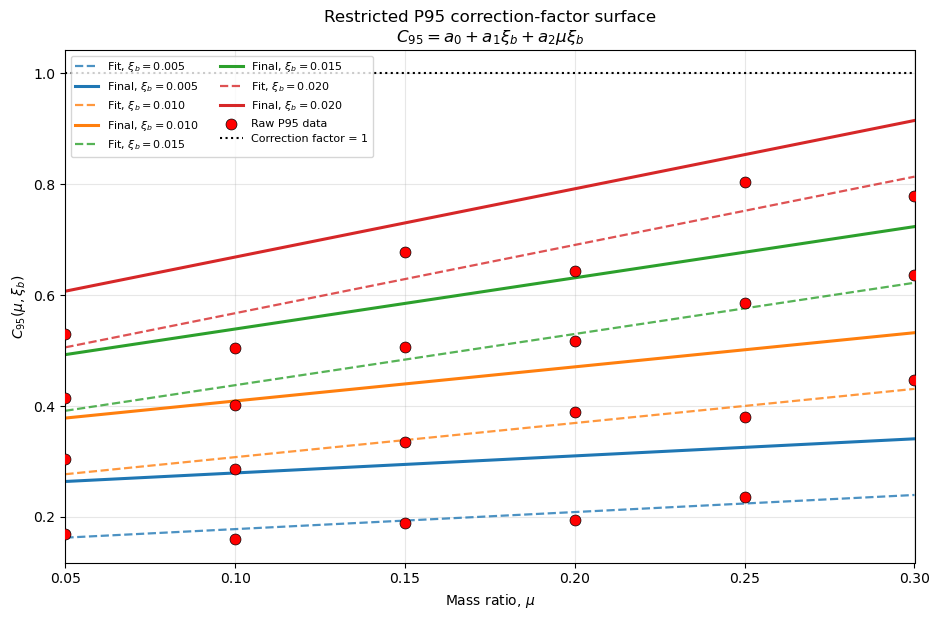

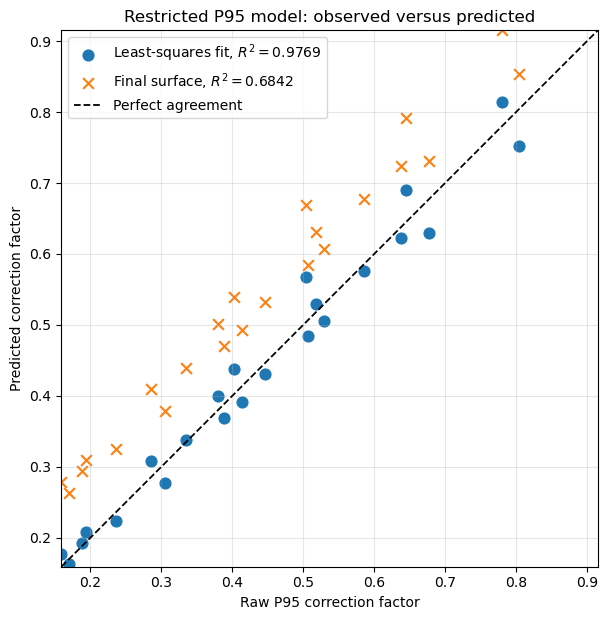

In [39]:
# ============================================================
# RESTRICTED THREE-TERM P95 CORRECTION-FACTOR SURFACE
#
# SECOND LOAD MODEL
#
# REQUIRED FORM:
#
# C95(mu, xi_b)
#
#     = a0
#     + a1 * xi_b
#     + a2 * mu * xi_b
#
#
# IMPORTANT:
#
# THERE IS NO STANDALONE mu TERM.
#
# Fitted terms are exactly:
#
#     1
#     xi_b
#     mu * xi_b
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. SETTINGS
# ============================================================

MODEL_LABEL = "Second load model"

# Extra MANUAL shift after the automatic conservative shift
SAFETY_MARGIN = 0.05

DOMAIN_CHECK_POINTS = 501

SAVE_RESULTS = False


# ============================================================
# 2. PREPARE RAW P95 DATA
# ============================================================

model2_surface_df = (

    bias_percentile_df.copy()
)


required_columns = [

    "mass_ratio",

    "xi_b",

    "P95_bias",
]


missing_columns = [

    column

    for column in required_columns

    if column not in model2_surface_df.columns
]


if missing_columns:

    raise KeyError(

        "Missing required columns in bias_percentile_df: "

        f"{missing_columns}"
    )


for column in required_columns:

    model2_surface_df[
        column
    ] = pd.to_numeric(

        model2_surface_df[
            column
        ],

        errors="coerce"
    )


model2_surface_df = (

    model2_surface_df

    .dropna(
        subset=required_columns
    )

    .groupby(
        [
            "mass_ratio",
            "xi_b",
        ],
        as_index=False
    )[
        "P95_bias"
    ]

    .mean()

    .sort_values(
        [
            "xi_b",
            "mass_ratio",
        ]
    )

    .reset_index(
        drop=True
    )
)


if model2_surface_df.empty:

    raise ValueError(
        "No valid P95 data remain."
    )


print(
    "\nRaw P95 data:"
)

display(
    model2_surface_df.round(6)
)


# ============================================================
# 3. CALIBRATION DOMAIN
# ============================================================

MODEL2_MU_MIN = float(

    model2_surface_df[
        "mass_ratio"
    ].min()
)


MODEL2_MU_MAX = float(

    model2_surface_df[
        "mass_ratio"
    ].max()
)


MODEL2_XI_MIN = float(

    model2_surface_df[
        "xi_b"
    ].min()
)


MODEL2_XI_MAX = float(

    model2_surface_df[
        "xi_b"
    ].max()
)


# ============================================================
# 4. RAW ARRAYS
# ============================================================

model2_mu_data = (

    model2_surface_df[
        "mass_ratio"
    ]

    .to_numpy(
        dtype=float
    )
)


model2_xi_data = (

    model2_surface_df[
        "xi_b"
    ]

    .to_numpy(
        dtype=float
    )
)


model2_y_data = (

    model2_surface_df[
        "P95_bias"
    ]

    .to_numpy(
        dtype=float
    )
)


model2_unique_dampings = sorted(

    model2_surface_df[
        "xi_b"
    ].unique()
)


# ============================================================
# 5. DESIGN MATRIX
#
# EXACT PHYSICAL EQUATION:
#
# C95 = a0 + a1*xi_b + a2*mu*xi_b
#
# NO standalone mu term.
# ============================================================

def build_model2_design_matrix(
    mu,
    xi_b,
):


    mu = np.asarray(
        mu,
        dtype=float
    ).reshape(-1)


    xi_b = np.asarray(
        xi_b,
        dtype=float
    ).reshape(-1)


    if len(mu) != len(xi_b):

        raise ValueError(
            "mu and xi_b must have equal lengths."
        )


    X = np.column_stack(

        [

            # a0
            np.ones_like(
                mu
            ),

            # a1 * xi_b
            xi_b,

            # a2 * mu * xi_b
            mu * xi_b,
        ]
    )


    return X


# ============================================================
# 6. METRICS
# ============================================================

def calculate_metrics(
    observed,
    predicted,
):


    observed = np.asarray(
        observed,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    valid = (

        np.isfinite(
            observed
        )

        &

        np.isfinite(
            predicted
        )
    )


    observed = observed[
        valid
    ]


    predicted = predicted[
        valid
    ]


    if len(observed) == 0:

        return {

            "R2":
                np.nan,

            "RMSE":
                np.nan,

            "MAE":
                np.nan,

            "SSE":
                np.nan,
        }


    residual = (

        observed

        -

        predicted
    )


    SSE = np.sum(
        residual**2
    )


    SST = np.sum(

        (
            observed
            -
            np.mean(
                observed
            )
        )**2
    )


    R2 = (

        1.0
        -
        SSE / SST

        if SST > 0

        else np.nan
    )


    RMSE = np.sqrt(

        np.mean(
            residual**2
        )
    )


    MAE = np.mean(

        np.abs(
            residual
        )
    )


    return {

        "R2":
            R2,

        "RMSE":
            RMSE,

        "MAE":
            MAE,

        "SSE":
            SSE,
    }


def adjusted_r_squared(
    r_squared,
    n_observations,
    n_predictors,
):


    denominator = (

        n_observations

        -

        n_predictors

        -

        1
    )


    if (

        not np.isfinite(
            r_squared
        )

        or

        denominator <= 0
    ):

        return np.nan


    return (

        1.0

        -

        (
            1.0
            -
            r_squared
        )

        *

        (
            n_observations
            -
            1
        )

        /

        denominator
    )


# ============================================================
# 7. LEAVE-ONE-DAMPING-LEVEL-OUT CROSS-VALIDATION
# ============================================================

cv_predictions = np.full(

    len(
        model2_y_data
    ),

    np.nan
)


cv_rank_values = []


for held_out_damping in (
    model2_unique_dampings
):


    test_mask = np.isclose(

        model2_xi_data,

        held_out_damping
    )


    train_mask = ~test_mask


    X_train = build_model2_design_matrix(

        model2_mu_data[
            train_mask
        ],

        model2_xi_data[
            train_mask
        ]
    )


    X_test = build_model2_design_matrix(

        model2_mu_data[
            test_mask
        ],

        model2_xi_data[
            test_mask
        ]
    )


    matrix_rank = np.linalg.matrix_rank(
        X_train
    )


    cv_rank_values.append(
        matrix_rank
    )


    if matrix_rank < X_train.shape[1]:

        raise ValueError(

            "Restricted three-term model became "
            "rank deficient during LODO-CV."
        )


    beta_cv, *_ = np.linalg.lstsq(

        X_train,

        model2_y_data[
            train_mask
        ],

        rcond=None
    )


    cv_predictions[
        test_mask
    ] = (

        X_test

        @

        beta_cv
    )


model2_cv_metrics = calculate_metrics(

    model2_y_data,

    cv_predictions
)


# ============================================================
# 8. FIT RESTRICTED MODEL TO ALL RAW P95 DATA
# ============================================================

MODEL2_X_ALL = build_model2_design_matrix(

    model2_mu_data,

    model2_xi_data
)


MODEL2_SURFACE_BETA, *_ = np.linalg.lstsq(

    MODEL2_X_ALL,

    model2_y_data,

    rcond=None
)


# ------------------------------------------------------------
# Coefficients
# ------------------------------------------------------------

MODEL2_A0 = float(
    MODEL2_SURFACE_BETA[0]
)


MODEL2_A_XI = float(
    MODEL2_SURFACE_BETA[1]
)


MODEL2_A_MUXI = float(
    MODEL2_SURFACE_BETA[2]
)


# ============================================================
# 9. LEAST-SQUARES PREDICTION
# ============================================================

model2_prediction_fit = (

    MODEL2_X_ALL

    @

    MODEL2_SURFACE_BETA
)


# ============================================================
# 10. AUTOMATIC CONSERVATIVE INTERCEPT CORRECTION
#
# Find largest point where raw P95 lies ABOVE fitted equation.
# ============================================================

MODEL2_LARGEST_POSITIVE_RESIDUAL = float(

    np.max(

        model2_y_data

        -

        model2_prediction_fit
    )
)


MODEL2_AUTOMATIC_SHIFT = max(

    0.0,

    MODEL2_LARGEST_POSITIVE_RESIDUAL
)


# ============================================================
# 11. FINAL INTERCEPT SHIFT
#
# automatic shift
# +
# manual SAFETY_MARGIN
# ============================================================

MODEL2_UPWARD_SHIFT = (

    MODEL2_AUTOMATIC_SHIFT

    +

    SAFETY_MARGIN
)


model2_prediction_final = (

    model2_prediction_fit

    +

    MODEL2_UPWARD_SHIFT
)


# ============================================================
# 12. FINAL PHYSICAL COEFFICIENTS
#
# Only the CONSTANT changes.
#
# xi_b and mu*xi_b coefficients stay unchanged.
# ============================================================

MODEL2_A0_FINAL = (

    MODEL2_A0

    +

    MODEL2_UPWARD_SHIFT
)


MODEL2_A_XI_FINAL = (
    MODEL2_A_XI
)


MODEL2_A_MUXI_FINAL = (
    MODEL2_A_MUXI
)


# ============================================================
# 13. METRICS
# ============================================================

model2_fit_metrics = calculate_metrics(

    model2_y_data,

    model2_prediction_fit
)


model2_final_metrics = calculate_metrics(

    model2_y_data,

    model2_prediction_final
)


MODEL2_ADJUSTED_R2_FIT = adjusted_r_squared(

    model2_fit_metrics[
        "R2"
    ],

    len(
        model2_y_data
    ),

    # xi and mu*xi
    2
)


# ============================================================
# 14. EVALUATION FUNCTIONS
# ============================================================

def _check_model2_domain(
    mu,
    xi_b,
):


    mu = np.asarray(
        mu,
        dtype=float
    )


    xi_b = np.asarray(
        xi_b,
        dtype=float
    )


    outside = (

        (
            mu
            <
            MODEL2_MU_MIN
        )

        |

        (
            mu
            >
            MODEL2_MU_MAX
        )

        |

        (
            xi_b
            <
            MODEL2_XI_MIN
        )

        |

        (
            xi_b
            >
            MODEL2_XI_MAX
        )
    )


    if np.any(
        outside
    ):

        raise ValueError(

            "Inputs outside calibrated domain:\n"

            f"{MODEL2_MU_MIN:.4f} <= mu <= "
            f"{MODEL2_MU_MAX:.4f}\n"

            f"{MODEL2_XI_MIN:.4f} <= xi_b <= "
            f"{MODEL2_XI_MAX:.4f}"
        )


def C95_model2_fit(
    mu,
    xi_b,
    check_domain=True,
):


    mu = np.asarray(
        mu,
        dtype=float
    )


    xi_b = np.asarray(
        xi_b,
        dtype=float
    )


    mu, xi_b = np.broadcast_arrays(
        mu,
        xi_b
    )


    if check_domain:

        _check_model2_domain(
            mu,
            xi_b
        )


    values = (

        MODEL2_A0

        +

        MODEL2_A_XI
        *
        xi_b

        +

        MODEL2_A_MUXI
        *
        mu
        *
        xi_b
    )


    if values.ndim == 0:

        return float(
            values
        )


    return values


def C95_model2_final(
    mu,
    xi_b,
    check_domain=True,
):


    mu = np.asarray(
        mu,
        dtype=float
    )


    xi_b = np.asarray(
        xi_b,
        dtype=float
    )


    mu, xi_b = np.broadcast_arrays(
        mu,
        xi_b
    )


    if check_domain:

        _check_model2_domain(
            mu,
            xi_b
        )


    values = (

        MODEL2_A0_FINAL

        +

        MODEL2_A_XI_FINAL
        *
        xi_b

        +

        MODEL2_A_MUXI_FINAL
        *
        mu
        *
        xi_b
    )


    if values.ndim == 0:

        return float(
            values
        )


    return values


# ============================================================
# 15. READABLE EQUATIONS
# ============================================================

MODEL2_EQUATION_FIT = (

    f"{MODEL2_A0:.8f} "

    f"{MODEL2_A_XI:+.8f}*xi_b "

    f"{MODEL2_A_MUXI:+.8f}*mu*xi_b"
)


MODEL2_EQUATION_FINAL = (

    f"{MODEL2_A0_FINAL:.8f} "

    f"{MODEL2_A_XI_FINAL:+.8f}*xi_b "

    f"{MODEL2_A_MUXI_FINAL:+.8f}*mu*xi_b"
)


# ============================================================
# 16. PRINT RESULTS
# ============================================================

print(
    "\n============================================================"
)

print(
    "RESTRICTED P95 CORRECTION-FACTOR SURFACE"
)

print(
    "============================================================"
)


print(
    "\nRequired form:"
)

print(
    "C95(mu,xi_b) = "
    "a0 + a1*xi_b + a2*mu*xi_b"
)


print(
    "\nNO standalone mu term."
)


print(
    "\n------------------------------------------------------------"
)

print(
    "LEAST-SQUARES FIT"
)

print(
    "------------------------------------------------------------"
)


print(
    "\nC95_model2_fit(mu,xi_b) ="
)

print(
    MODEL2_EQUATION_FIT
)


print(
    f"\nR²_fit          = "
    f"{model2_fit_metrics['R2']:.6f}"
)


print(
    f"Adjusted R²_fit = "
    f"{MODEL2_ADJUSTED_R2_FIT:.6f}"
)


print(
    f"RMSE_fit        = "
    f"{model2_fit_metrics['RMSE']:.6f}"
)


print(
    f"MAE_fit         = "
    f"{model2_fit_metrics['MAE']:.6f}"
)


print(
    "\nLODO-CV:"
)


print(
    f"R²   = "
    f"{model2_cv_metrics['R2']:.6f}"
)


print(
    f"RMSE = "
    f"{model2_cv_metrics['RMSE']:.6f}"
)


print(
    f"MAE  = "
    f"{model2_cv_metrics['MAE']:.6f}"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "FINAL CONSERVATIVE EQUATION"
)

print(
    "------------------------------------------------------------"
)


print(
    "\nC95_model2_final(mu,xi_b) ="
)

print(
    MODEL2_EQUATION_FINAL
)


print(
    f"\nAutomatic intercept shift = "
    f"{MODEL2_AUTOMATIC_SHIFT:.8f}"
)


print(
    f"Additional safety margin  = "
    f"{SAFETY_MARGIN:.8f}"
)


print(
    f"TOTAL intercept correction = "
    f"{MODEL2_UPWARD_SHIFT:.8f}"
)


print(
    f"\nR²_final   = "
    f"{model2_final_metrics['R2']:.6f}"
)


print(
    f"RMSE_final = "
    f"{model2_final_metrics['RMSE']:.6f}"
)


# ============================================================
# 17. POINT-BY-POINT CHECK
# ============================================================

model2_surface_check_df = (

    model2_surface_df.copy()
)


model2_surface_check_df[
    "surface_fit"
] = model2_prediction_fit


model2_surface_check_df[
    "surface_final"
] = model2_prediction_final


model2_surface_check_df[
    "raw_minus_fit"
] = (

    model2_y_data

    -

    model2_prediction_fit
)


model2_surface_check_df[
    "final_minus_raw"
] = (

    model2_prediction_final

    -

    model2_y_data
)


print(
    "\nPoint-by-point comparison:"
)


display(
    model2_surface_check_df.round(6)
)


print(
    "\nMinimum final-minus-raw margin =",
    model2_surface_check_df[
        "final_minus_raw"
    ].min()
)


# ============================================================
# 18. PLOT SURFACE SLICES
# ============================================================

fig, ax = plt.subplots(

    figsize=(
        9.5,
        6.3
    )
)


line_colours = plt.rcParams[
    "axes.prop_cycle"
].by_key()[
    "color"
]


for damping_index, damping in enumerate(
    model2_unique_dampings
):


    colour = line_colours[

        damping_index

        %

        len(
            line_colours
        )
    ]


    mu_smooth = np.linspace(

        MODEL2_MU_MIN,

        MODEL2_MU_MAX,

        500
    )


    xi_smooth = np.full_like(

        mu_smooth,

        damping
    )


    fit_smooth = C95_model2_fit(

        mu_smooth,

        xi_smooth
    )


    final_smooth = C95_model2_final(

        mu_smooth,

        xi_smooth
    )


    ax.plot(

        mu_smooth,

        fit_smooth,

        linestyle="--",

        linewidth=1.6,

        color=colour,

        alpha=0.80,

        label=(
            rf"Fit, $\xi_b={damping:.3f}$"
        )
    )


    ax.plot(

        mu_smooth,

        final_smooth,

        linestyle="-",

        linewidth=2.2,

        color=colour,

        label=(
            rf"Final, $\xi_b={damping:.3f}$"
        )
    )


ax.scatter(

    model2_mu_data,

    model2_y_data,

    s=62,

    color="red",

    edgecolor="black",

    linewidth=0.5,

    zorder=6,

    label="Raw P95 data"
)


ax.axhline(

    1.0,

    linestyle=":",

    linewidth=1.5,

    color="black",

    label="Correction factor = 1"
)


ax.set_xlabel(
    r"Mass ratio, $\mu$"
)


ax.set_ylabel(
    r"$C_{95}(\mu,\xi_b)$"
)


ax.set_title(

    "Restricted P95 correction-factor surface\n"

    r"$C_{95}=a_0+a_1\xi_b+a_2\mu\xi_b$"
)


ax.set_xlim(

    MODEL2_MU_MIN,

    MODEL2_MU_MAX
)


ax.grid(
    True,
    alpha=0.30
)


ax.legend(
    ncol=2,
    fontsize=8
)


plt.tight_layout()

plt.show()


# ============================================================
# 19. OBSERVED vs PREDICTED
# ============================================================

fig, ax = plt.subplots(

    figsize=(
        6.8,
        6.3
    )
)


ax.scatter(

    model2_y_data,

    model2_prediction_fit,

    s=60,

    label=(
        rf"Least-squares fit, "
        rf"$R^2={model2_fit_metrics['R2']:.4f}$"
    )
)


ax.scatter(

    model2_y_data,

    model2_prediction_final,

    s=60,

    marker="x",

    label=(
        rf"Final surface, "
        rf"$R^2={model2_final_metrics['R2']:.4f}$"
    )
)


plot_min = min(

    np.min(
        model2_y_data
    ),

    np.min(
        model2_prediction_fit
    ),

    np.min(
        model2_prediction_final
    )
)


plot_max = max(

    np.max(
        model2_y_data
    ),

    np.max(
        model2_prediction_fit
    ),

    np.max(
        model2_prediction_final
    )
)


ax.plot(

    [
        plot_min,
        plot_max
    ],

    [
        plot_min,
        plot_max
    ],

    linestyle="--",

    color="black",

    linewidth=1.3,

    label="Perfect agreement"
)


ax.set_xlabel(
    "Raw P95 correction factor"
)


ax.set_ylabel(
    "Predicted correction factor"
)


ax.set_title(
    "Restricted P95 model: observed versus predicted"
)


ax.set_xlim(
    plot_min,
    plot_max
)


ax.set_ylim(
    plot_min,
    plot_max
)


ax.set_aspect(
    "equal",
    adjustable="box"
)


ax.grid(
    True,
    alpha=0.30
)


ax.legend()


plt.tight_layout()

plt.show()


RAW P95 MERGE CHECK

Rows without raw P95 factor = 0

BIAS DEFINITIONS

Blue:
bias_after_psi = env_bias

Orange:
bias_after_raw_P95 = env_bias / C95_raw

Green:
bias_after_idealised_P95 = env_bias / C95_model2_final

Final idealised P95 equation:
0.14949343 +19.80817986*xi_b +61.57552758*mu*xi_b

BIAS SUMMARY

               Case  Mean bias  Minimum bias  Maximum bias  Number Bias > 1  Percentage Bias > 1
After corrected psi   0.243375      0.033808      0.929996                0             0.000000
      After raw P95   0.577120      0.139523      1.443600               69             6.521739
After idealised P95   0.448573      0.103864      1.174297                6             0.567108

Added plotting-only proxy:
mu=.25, xi=.005 -> mu=.30, xi=.005


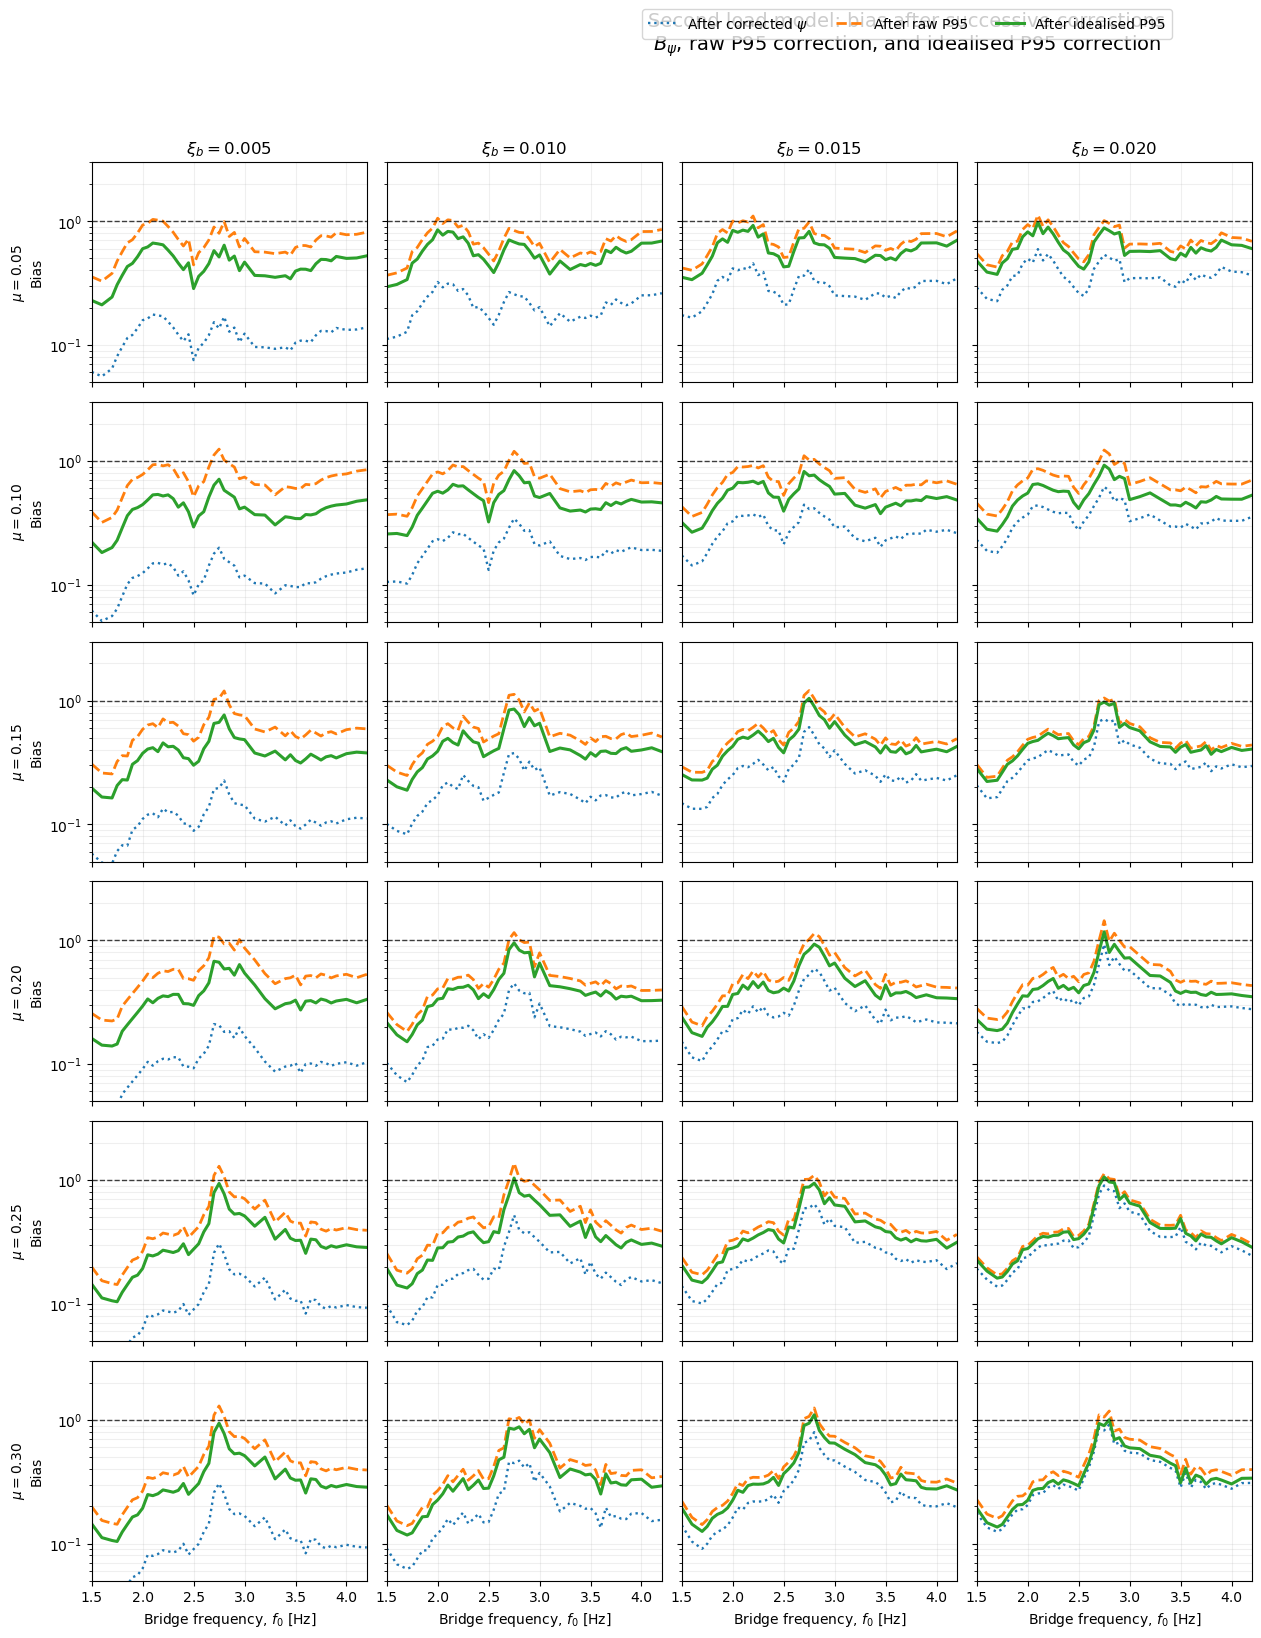


Created:
  model2_P95_bias_df
  bias_summary_model2_df

model2_P95_bias_df contains REAL analytical data only.


In [40]:
# ============================================================
# BIAS AFTER PSI + P95 CORRECTIONS
#
# WORKFLOW:
#
# 1. After psi correction only:
#
#        B_psi = env_bias
#
# 2. After exact RAW P95 correction:
#
#        B_raw95 =
#            B_psi / C95_raw(mu, xi_b)
#
# 3. After IDEALISED P95 correction:
#
#        B_ideal95 =
#            B_psi / C95_model2_final(mu, xi_b)
#
#
# INPUTS ALREADY CREATED BY PREVIOUS CELLS:
#
#     p95_frequency_df
#     p95_factor_df
#     C95_model2_final
#
# NO REFITTING IS DONE HERE.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

EPS = 1e-12

BIAS_YMIN = 0.05
BIAS_YMAX = 3.00

USE_LOG_Y = True


# ------------------------------------------------------------
# Plotting-only proxy requested earlier
#
# Copy mu=.25, xi=.005 into missing mu=.30, xi=.005 panel.
#
# IMPORTANT:
# This is ONLY to fill the visual panel.
# Do not use the proxy for probability calculations.
# ------------------------------------------------------------

ADD_030_0005_PROXY = True

SOURCE_MU = 0.25
SOURCE_XI = 0.005

TARGET_MU = 0.30
TARGET_XI = 0.005


# ============================================================
# 1. CHECK THE ACTUAL OBJECTS FROM YOUR WORKFLOW
# ============================================================

required_objects = [

    "p95_frequency_df",

    "p95_factor_df",

    "C95_model2_final",
]


missing = [

    name

    for name in required_objects

    if name not in globals()
]


if missing:

    raise NameError(

        "Missing required previous-cell outputs:\n"

        f"{missing}\n\n"

        "Required order:\n"
        "1. loading + psi correction\n"
        "2. raw P95-across-frequency cell\n"
        "3. P95 idealisation cell\n"
        "4. this cell"
    )


# ============================================================
# 2. START DIRECTLY FROM THE DATA USED TO CALCULATE P95
#
# p95_frequency_df already has:
#
#     damping_key
#     mass_ratio
#     bridge_frequency
#     env_bias
#
# and duplicates mapping to the same mu have ALREADY been
# averaged at each frequency in your P95 cell.
# ============================================================

bias_compare_model2_df = (

    p95_frequency_df.copy()
)


required_columns = [

    "damping_key",

    "mass_ratio",

    "bridge_frequency",

    "env_bias",
]


missing_columns = [

    column

    for column in required_columns

    if column not in
    bias_compare_model2_df.columns
]


if missing_columns:

    raise KeyError(

        "Missing columns from p95_frequency_df:\n"

        f"{missing_columns}"
    )


for column in required_columns:

    bias_compare_model2_df[
        column
    ] = pd.to_numeric(

        bias_compare_model2_df[
            column
        ],

        errors="coerce"
    )


bias_compare_model2_df = (

    bias_compare_model2_df

    .dropna(
        subset=required_columns
    )

    .copy()
)


bias_compare_model2_df = (

    bias_compare_model2_df[

        (
            bias_compare_model2_df[
                "bridge_frequency"
            ]
            >=
            PLOT_FMIN
        )

        &

        (
            bias_compare_model2_df[
                "bridge_frequency"
            ]
            <=
            PLOT_FMAX
        )

    ]

    .copy()
)


# ============================================================
# 3. RENAME FOR PLOTTING CONVENIENCE
# ============================================================

bias_compare_model2_df[
    "target_beamdamp"
] = (

    bias_compare_model2_df[
        "damping_key"
    ]
)


bias_compare_model2_df[
    "bias_after_psi"
] = (

    bias_compare_model2_df[
        "env_bias"
    ]
)


# ============================================================
# 4. PREPARE RAW P95 LOOKUP
#
# Comes DIRECTLY from your second cell:
#
#     p95_factor_df
#
# Columns:
#
#     damping
#     mass_ratio
#     p95_factor
# ============================================================

raw_lookup = (

    p95_factor_df[
        [
            "damping",
            "mass_ratio",
            "p95_factor",
        ]
    ]

    .copy()
)


for column in [

    "damping",

    "mass_ratio",

    "p95_factor",
]:

    raw_lookup[
        column
    ] = pd.to_numeric(

        raw_lookup[
            column
        ],

        errors="coerce"
    )


raw_lookup = (

    raw_lookup

    .dropna()

    .copy()
)


# ============================================================
# 5. MERGE KEYS
# ============================================================

bias_compare_model2_df[
    "_mu_key"
] = (

    bias_compare_model2_df[
        "mass_ratio"
    ]

    .round(6)
)


bias_compare_model2_df[
    "_xi_key"
] = (

    bias_compare_model2_df[
        "target_beamdamp"
    ]

    .round(6)
)


raw_lookup[
    "_mu_key"
] = (

    raw_lookup[
        "mass_ratio"
    ]

    .round(6)
)


raw_lookup[
    "_xi_key"
] = (

    raw_lookup[
        "damping"
    ]

    .round(6)
)


# ============================================================
# 6. ATTACH EXACT RAW P95 FACTOR
# ============================================================

bias_compare_model2_df = (

    bias_compare_model2_df

    .merge(

        raw_lookup[
            [
                "_mu_key",
                "_xi_key",
                "p95_factor",
            ]
        ],

        on=[
            "_mu_key",
            "_xi_key",
        ],

        how="left",

        validate="many_to_one"
    )

    .rename(
        columns={
            "p95_factor":
                "C95_raw"
        }
    )
)


# ============================================================
# 7. CHECK RAW P95 MATCHING
# ============================================================

missing_raw = (

    bias_compare_model2_df[
        "C95_raw"
    ]

    .isna()

    .sum()
)


print(
    "\n============================================================"
)

print(
    "RAW P95 MERGE CHECK"
)

print(
    "============================================================"
)


print(
    f"\nRows without raw P95 factor = "
    f"{missing_raw}"
)


# ============================================================
# 8. BIAS AFTER EXACT RAW P95
#
#
#                  env_bias
# B_raw95 = -----------------------
#                  C95_raw
# ============================================================

bias_compare_model2_df[
    "bias_after_raw_P95"
] = np.nan


valid_raw = (

    np.isfinite(
        bias_compare_model2_df[
            "bias_after_psi"
        ]
    )

    &

    np.isfinite(
        bias_compare_model2_df[
            "C95_raw"
        ]
    )

    &

    (
        bias_compare_model2_df[
            "C95_raw"
        ]
        >
        EPS
    )
)


bias_compare_model2_df.loc[
    valid_raw,
    "bias_after_raw_P95"
] = (

    bias_compare_model2_df.loc[
        valid_raw,
        "bias_after_psi"
    ]

    /

    bias_compare_model2_df.loc[
        valid_raw,
        "C95_raw"
    ]
)


# ============================================================
# 9. IDEALISED P95 FACTOR
#
# Uses your THIRD CELL directly:
#
#     C95_model2_final(mu, xi_b)
#
# This is the conservatively shifted idealisation.
# ============================================================

mu = (

    bias_compare_model2_df[
        "mass_ratio"
    ]

    .to_numpy(
        dtype=float
    )
)


xi = (

    bias_compare_model2_df[
        "target_beamdamp"
    ]

    .to_numpy(
        dtype=float
    )
)


# ------------------------------------------------------------
# Only evaluate points inside the fitted P95 domain.
# ------------------------------------------------------------

if all(

    name in globals()

    for name in [

        "MODEL2_MU_MIN",
        "MODEL2_MU_MAX",
        "MODEL2_XI_MIN",
        "MODEL2_XI_MAX",
    ]
):


    inside_surface_domain = (

        (
            mu
            >=
            MODEL2_MU_MIN
        )

        &

        (
            mu
            <=
            MODEL2_MU_MAX
        )

        &

        (
            xi
            >=
            MODEL2_XI_MIN
        )

        &

        (
            xi
            <=
            MODEL2_XI_MAX
        )
    )


else:

    # These should normally exist after the idealisation cell.
    inside_surface_domain = np.ones(
        len(
            bias_compare_model2_df
        ),
        dtype=bool
    )


bias_compare_model2_df[
    "C95_idealised"
] = np.nan


bias_compare_model2_df.loc[
    inside_surface_domain,
    "C95_idealised"
] = C95_model2_final(

    mu[
        inside_surface_domain
    ],

    xi[
        inside_surface_domain
    ],

    check_domain=True
)


# ============================================================
# 10. BIAS AFTER IDEALISED P95
#
#
#                   env_bias
# B_ideal95 = -----------------------
#              C95_model2_final
# ============================================================

bias_compare_model2_df[
    "bias_after_idealised_P95"
] = np.nan


valid_ideal = (

    np.isfinite(
        bias_compare_model2_df[
            "bias_after_psi"
        ]
    )

    &

    np.isfinite(
        bias_compare_model2_df[
            "C95_idealised"
        ]
    )

    &

    (
        bias_compare_model2_df[
            "C95_idealised"
        ]
        >
        EPS
    )
)


bias_compare_model2_df.loc[
    valid_ideal,
    "bias_after_idealised_P95"
] = (

    bias_compare_model2_df.loc[
        valid_ideal,
        "bias_after_psi"
    ]

    /

    bias_compare_model2_df.loc[
        valid_ideal,
        "C95_idealised"
    ]
)


# ============================================================
# 11. PRINT THE THREE BIAS DEFINITIONS
# ============================================================

print(
    "\n============================================================"
)

print(
    "BIAS DEFINITIONS"
)

print(
    "============================================================"
)


print(
    "\nBlue:"
)

print(
    "bias_after_psi = env_bias"
)


print(
    "\nOrange:"
)

print(
    "bias_after_raw_P95 "
    "= env_bias / C95_raw"
)


print(
    "\nGreen:"
)

print(
    "bias_after_idealised_P95 "
    "= env_bias / C95_model2_final"
)


if "MODEL2_EQUATION_FINAL" in globals():

    print(
        "\nFinal idealised P95 equation:"
    )

    print(
        MODEL2_EQUATION_FINAL
    )


# ============================================================
# 12. SUMMARY
# ============================================================

summary_rows = []


for name, column in {

    r"After corrected psi":
        "bias_after_psi",

    "After raw P95":
        "bias_after_raw_P95",

    "After idealised P95":
        "bias_after_idealised_P95",

}.items():


    values = (

        bias_compare_model2_df[
            column
        ]

        .to_numpy(
            dtype=float
        )
    )


    values = values[
        np.isfinite(values)
    ]


    if len(values) == 0:

        continue


    summary_rows.append({

        "Case":
            name,

        "Mean bias":
            np.mean(values),

        "Minimum bias":
            np.min(values),

        "Maximum bias":
            np.max(values),

        "Number Bias > 1":
            np.sum(
                values > 1.0
            ),

        "Percentage Bias > 1":
            100.0
            *
            np.mean(
                values > 1.0
            ),
    })


bias_summary_model2_df = pd.DataFrame(
    summary_rows
)


print(
    "\n============================================================"
)

print(
    "BIAS SUMMARY"
)

print(
    "============================================================\n"
)


print(

    bias_summary_model2_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"
    )
)


# ============================================================
# 13. COPY FOR PLOTTING
#
# The analytical dataframe above remains untouched by proxy.
# ============================================================

plot_bias_df = (

    bias_compare_model2_df.copy()
)


plot_bias_df[
    "proxy_for_plot_only"
] = False


# ============================================================
# 14. OPTIONAL VISUAL PROXY:
#
# mu=.25, xi=.005
#       ->
# mu=.30, xi=.005
#
# This follows your earlier requested figure arrangement.
#
# NOT FOR STATISTICS.
# ============================================================

if ADD_030_0005_PROXY:


    source = (

        plot_bias_df[

            np.isclose(
                plot_bias_df[
                    "mass_ratio"
                ],
                SOURCE_MU
            )

            &

            np.isclose(
                plot_bias_df[
                    "target_beamdamp"
                ],
                SOURCE_XI
            )

        ]

        .copy()

        .sort_values(
            "bridge_frequency"
        )
    )


    target = (

        plot_bias_df[

            np.isclose(
                plot_bias_df[
                    "mass_ratio"
                ],
                TARGET_MU
            )

            &

            np.isclose(
                plot_bias_df[
                    "target_beamdamp"
                ],
                TARGET_XI
            )

        ]

        .copy()
    )


    if (
        target.empty
        and
        not source.empty
    ):


        proxy = (
            source.copy()
        )


        proxy[
            "mass_ratio"
        ] = TARGET_MU


        proxy[
            "_mu_key"
        ] = round(
            TARGET_MU,
            6
        )


        proxy[
            "target_beamdamp"
        ] = TARGET_XI


        proxy[
            "damping_key"
        ] = TARGET_XI


        proxy[
            "_xi_key"
        ] = round(
            TARGET_XI,
            6
        )


        proxy[
            "proxy_for_plot_only"
        ] = True


        plot_bias_df = pd.concat(

            [
                plot_bias_df,
                proxy,
            ],

            ignore_index=True
        )


        print(
            "\nAdded plotting-only proxy:"
        )

        print(
            "mu=.25, xi=.005 "
            "-> mu=.30, xi=.005"
        )


# ============================================================
# 15. PLOT ORDER
# ============================================================

MU_ORDER = [

    0.05,

    0.10,

    0.15,

    0.20,

    0.25,

    0.30,
]


XI_ORDER = [

    0.005,

    0.010,

    0.015,

    0.020,

    0.025,

    0.030,
]


# ============================================================
# 16. PLOT
#
# BLUE DOTTED:
#
#     after psi-envelope correction only
#
# ORANGE DASHED:
#
#     after exact RAW P95 correction
#
# GREEN SOLID:
#
#     after IDEALISED P95 correction
# ============================================================

fig, axes = plt.subplots(

    nrows=
        len(
            MU_ORDER
        ),

    ncols=
        len(
            XI_ORDER
        ),

    figsize=(
        19,
        17
    ),

    sharex=True,

    sharey=True,

    squeeze=False
)


for row_index, mass_ratio in enumerate(
    MU_ORDER
):


    for column_index, damping in enumerate(
        XI_ORDER
    ):


        ax = axes[
            row_index,
            column_index
        ]


        sub = (

            plot_bias_df[

                np.isclose(
                    plot_bias_df[
                        "mass_ratio"
                    ],
                    mass_ratio
                )

                &

                np.isclose(
                    plot_bias_df[
                        "target_beamdamp"
                    ],
                    damping
                )

            ]

            .copy()

            .sort_values(
                "bridge_frequency"
            )
        )


        # ----------------------------------------------------
        # Missing actual combination
        # ----------------------------------------------------

        if sub.empty:

            ax.set_visible(
                False
            )

            continue


        # ====================================================
        # BLUE — PSI CORRECTION ONLY
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_psi"
            ],

            color=
                "tab:blue",

            linestyle=
                ":",

            linewidth=
                1.7,

            label=(
                r"After corrected $\psi$"
                if row_index == 0
                and column_index == 0
                else None
            )
        )


        # ====================================================
        # ORANGE — EXACT RAW P95
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_raw_P95"
            ],

            color=
                "tab:orange",

            linestyle=
                "--",

            linewidth=
                2.0,

            label=(
                "After raw P95"
                if row_index == 0
                and column_index == 0
                else None
            )
        )


        # ====================================================
        # GREEN — IDEALISED P95
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_idealised_P95"
            ],

            color=
                "tab:green",

            linestyle=
                "-",

            linewidth=
                2.2,

            label=(
                "After idealised P95"
                if row_index == 0
                and column_index == 0
                else None
            )
        )


        # ====================================================
        # BIAS = 1
        # ====================================================

        ax.axhline(

            1.0,

            color=
                "black",

            linestyle=
                "--",

            linewidth=
                1.0,

            alpha=
                0.75
        )



        # ====================================================
        # FORMAT
        # ====================================================

        ax.set_xlim(

            PLOT_FMIN,

            PLOT_FMAX
        )


        if USE_LOG_Y:

            ax.set_yscale(
                "log"
            )


        ax.set_ylim(

            BIAS_YMIN,

            BIAS_YMAX
        )


        ax.grid(

            True,

            which=
                "both",

            alpha=
                0.20
        )


        if row_index == 0:

            ax.set_title(

                rf"$\xi_b="
                rf"{damping:.3f}$"
            )


        if column_index == 0:

            ax.set_ylabel(

                rf"$\mu="
                rf"{mass_ratio:.2f}$"
                "\nBias"
            )


        if row_index == (
            len(
                MU_ORDER
            )
            -
            1
        ):

            ax.set_xlabel(

                r"Bridge frequency, "
                r"$f_0$ [Hz]"
            )


# ============================================================
# 17. COMMON LEGEND
# ============================================================

handles, labels = (

    axes[
        0,
        0
    ]

    .get_legend_handles_labels()
)


fig.legend(

    handles,

    labels,

    loc=
        "upper center",

    bbox_to_anchor=
        (
            0.5,
            0.985
        ),

    ncol=
        3,

    fontsize=
        10
)


fig.suptitle(

    "Second load model: bias after successive corrections\n"
    r"$B_\psi$, raw P95 correction, and idealised P95 correction",

    fontsize=
        14
)


fig.tight_layout(

    rect=[
        0.02,
        0.02,
        1.00,
        0.95
    ]
)


plt.show()


# ============================================================
# 18. SAVE CLEAN ANALYTICAL OUTPUT
#
# NO visual proxy is included here.
# ============================================================

model2_P95_bias_df = (

    bias_compare_model2_df[
        [
            "bridge_frequency",

            "target_beamdamp",

            "mass_ratio",

            "bias_after_psi",

            "C95_raw",

            "bias_after_raw_P95",

            "C95_idealised",

            "bias_after_idealised_P95",
        ]
    ]

    .sort_values(
        [
            "mass_ratio",

            "target_beamdamp",

            "bridge_frequency",
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nCreated:"
)

print(
    "  model2_P95_bias_df"
)

print(
    "  bias_summary_model2_df"
)

print(
    "\nmodel2_P95_bias_df contains REAL analytical data only."
)


Rows without raw P95 factor = 0

Mass ratios used:
[np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3)]

Damping ratios used:
[np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02)]

BRIDGE POPULATION

Inside 1.25–4.60 Hz: 160/250 = 64.00%


RAW CALCULATED P95


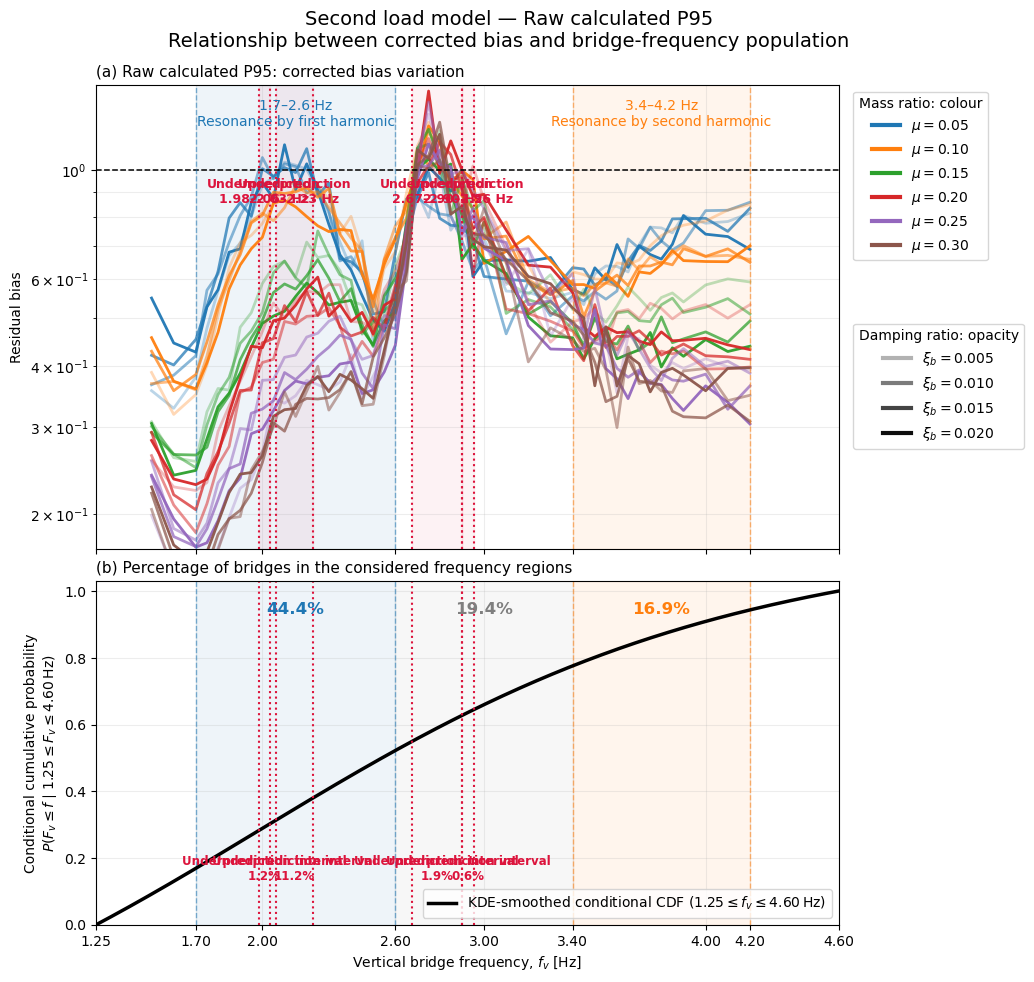


Underprediction intervals:

 Interval  Start frequency [Hz]  End frequency [Hz]  Width [Hz]  Number of bridges  Empirical probability [%]  KDE probability [%]
        1                1.9837              2.0326      0.0489                  2                     1.2500               1.9626
        2                2.0601              2.2302      0.1701                 18                    11.2500               6.7767
        3                2.6735              2.9000      0.2264                  3                     1.8750               7.8237
        4                2.9000              2.9568      0.0567                  1                     0.6250               1.8592


IDEALISED P95


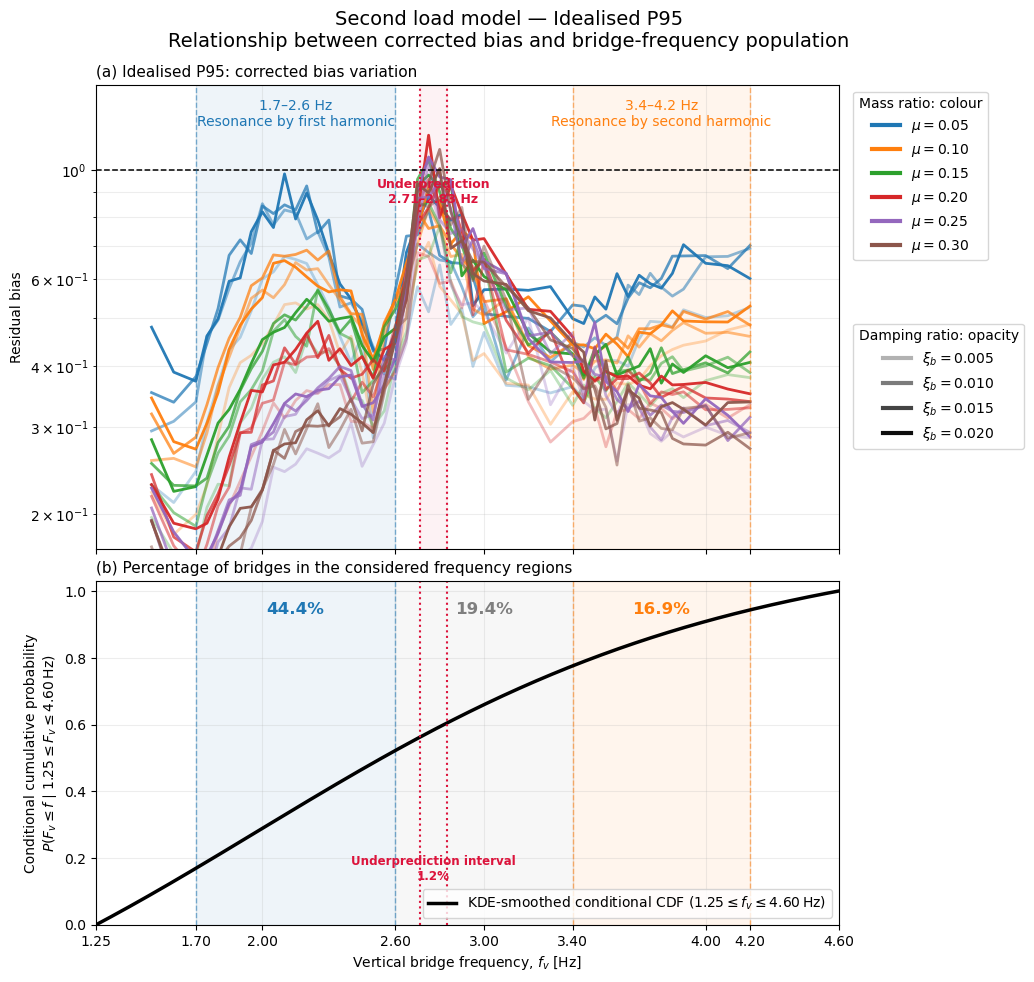


Underprediction intervals:

 Interval  Start frequency [Hz]  End frequency [Hz]  Width [Hz]  Number of bridges  Empirical probability [%]  KDE probability [%]
        1                2.7101              2.8341      0.1239                  2                     1.2500               4.3054

UNDERPREDICTION PROBABILITY SUMMARY

        Correction  Number of intervals  Total interval width [Hz]  Number of bridges  Empirical probability [%]  KDE probability [%]
Raw calculated P95                    4                     0.5022                 24                    15.0000              18.4221
     Idealised P95                    1                     0.1239                  2                     1.2500               4.3054

Created:
  model2_probability_bias_df
  raw_probability_df
  ideal_probability_df
  P95_probability_summary_df


In [43]:
# ============================================================
# SECOND LOAD MODEL
#
# RAW P95 vs IDEALISED P95
# BIAS + BRIDGE-FREQUENCY POPULATION PROBABILITY
#
# REQUIRED PREVIOUS OBJECTS:
#
#     compare_df
#     p95_factor_df
#     bias_percentile_df
#     C95_model2_final
#
# WORKFLOW:
#
#     B_psi = env_bias
#
#     B_raw95 =
#         env_bias / C95_raw(mu, xi_b)
#
#     B_ideal95 =
#         env_bias / C95_model2_final(mu, xi_b)
#
# Underprediction:
#
#     Bias > 1
#
# Population conditioning:
#
#     1.25 <= f_v <= 4.60 Hz
#
# Bias assessment:
#
#     1.50 <= f <= 4.20 Hz
#
# OUTPUT:
#
#     FIGURE 1 = Raw calculated P95
#     FIGURE 2 = Idealised P95
#
# Figures are shown SEPARATELY.
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid


# ============================================================
# 1. SETTINGS
# ============================================================

DATA_CSV = "data gong wei olivieri.csv"

FREQUENCY_COLUMN = "vertical_natural_frequency_Hz"

POP_FMIN = 1.25
POP_FMAX = 4.60

BIAS_FMIN = 1.50
BIAS_FMAX = 4.20

BIAS_THRESHOLD = 1.0

PERCENTILE = 95

# At a given frequency:
#
# "any"  = at least one mu-xi curve > 1
# "mean" = mean curve > 1
# "all"  = all curves > 1

UNDERPREDICTION_RULE = "any"

EPS = 1e-12

SAVE_PLOTS = False


# ============================================================
# 2. CHECK PREVIOUS CELLS
# ============================================================

required_objects = [

    "compare_df",

    "p95_factor_df",

    "bias_percentile_df",

    "C95_model2_final",
]


missing = [

    name

    for name in required_objects

    if name not in globals()
]


if missing:

    raise NameError(

        "Missing required previous-cell objects:\n"

        f"{missing}\n\n"

        "Run in this order:\n"
        "1. loading + psi-envelope correction\n"
        "2. raw P95 calculation\n"
        "3. conversion to bias_percentile_df\n"
        "4. P95 idealisation\n"
        "5. this probability cell"
    )


# ============================================================
# 3. PREPARE FREQUENCY-LEVEL BIAS DATA
#
# compare_df contains env_bias.
#
# Multiple lm values can represent the same mu.
#
# Average them at the SAME frequency first.
# ============================================================

probability_bias_df = (

    compare_df[
        [
            "bridge_frequency",
            "damping_key",
            "mass_ratio",
            "env_bias",
        ]
    ]

    .copy()
)


for column in [

    "bridge_frequency",

    "damping_key",

    "mass_ratio",

    "env_bias",
]:

    probability_bias_df[
        column
    ] = pd.to_numeric(

        probability_bias_df[
            column
        ],

        errors="coerce"
    )


probability_bias_df = (

    probability_bias_df

    .dropna()

    .groupby(
        [
            "damping_key",
            "mass_ratio",
            "bridge_frequency",
        ],
        as_index=False
    )

    .agg(
        env_bias=(
            "env_bias",
            "mean"
        )
    )

    .sort_values(
        [
            "mass_ratio",
            "damping_key",
            "bridge_frequency",
        ]
    )

    .reset_index(
        drop=True
    )
)


probability_bias_df[
    "target_beamdamp"
] = (

    probability_bias_df[
        "damping_key"
    ]
)


# ============================================================
# 4. FREQUENCY FILTER
# ============================================================

probability_bias_df = (

    probability_bias_df[

        (
            probability_bias_df[
                "bridge_frequency"
            ]
            >=
            BIAS_FMIN
        )

        &

        (
            probability_bias_df[
                "bridge_frequency"
            ]
            <=
            BIAS_FMAX
        )

    ]

    .copy()
)


# ============================================================
# 5. FILTER TO IDEALISATION CALIBRATION DOMAIN
# ============================================================

if all(

    name in globals()

    for name in [

        "MODEL2_MU_MIN",
        "MODEL2_MU_MAX",
        "MODEL2_XI_MIN",
        "MODEL2_XI_MAX",
    ]
):


    probability_bias_df = (

        probability_bias_df[

            (
                probability_bias_df[
                    "mass_ratio"
                ]
                >=
                MODEL2_MU_MIN
            )

            &

            (
                probability_bias_df[
                    "mass_ratio"
                ]
                <=
                MODEL2_MU_MAX
            )

            &

            (
                probability_bias_df[
                    "target_beamdamp"
                ]
                >=
                MODEL2_XI_MIN
            )

            &

            (
                probability_bias_df[
                    "target_beamdamp"
                ]
                <=
                MODEL2_XI_MAX
            )

        ]

        .copy()
    )


if probability_bias_df.empty:

    raise ValueError(
        "No bias data remain inside the calibrated domain."
    )


# ============================================================
# 6. RAW P95 LOOKUP
#
# We already converted:
#
#     p95_factor_df
#
# to:
#
#     bias_percentile_df
#
# with:
#
#     mass_ratio
#     xi_b
#     P95_bias
# ============================================================

raw_p95_lookup = (

    bias_percentile_df[
        [
            "mass_ratio",
            "xi_b",
            "P95_bias",
        ]
    ]

    .copy()
)


for column in [

    "mass_ratio",

    "xi_b",

    "P95_bias",
]:

    raw_p95_lookup[
        column
    ] = pd.to_numeric(

        raw_p95_lookup[
            column
        ],

        errors="coerce"
    )


raw_p95_lookup = (

    raw_p95_lookup

    .dropna()

    .groupby(
        [
            "mass_ratio",
            "xi_b",
        ],
        as_index=False
    )[
        "P95_bias"
    ]

    .mean()
)


# ============================================================
# 7. MERGE KEYS
# ============================================================

probability_bias_df[
    "_mu"
] = (

    probability_bias_df[
        "mass_ratio"
    ]

    .round(6)
)


probability_bias_df[
    "_xi"
] = (

    probability_bias_df[
        "target_beamdamp"
    ]

    .round(6)
)


raw_p95_lookup[
    "_mu"
] = (

    raw_p95_lookup[
        "mass_ratio"
    ]

    .round(6)
)


raw_p95_lookup[
    "_xi"
] = (

    raw_p95_lookup[
        "xi_b"
    ]

    .round(6)
)


# ============================================================
# 8. ADD RAW P95 FACTOR
# ============================================================

probability_bias_df = (

    probability_bias_df

    .merge(

        raw_p95_lookup[
            [
                "_mu",
                "_xi",
                "P95_bias",
            ]
        ],

        on=[
            "_mu",
            "_xi",
        ],

        how="left",

        validate="many_to_one"
    )

    .rename(
        columns={
            "P95_bias":
                "C95_raw"
        }
    )
)


missing_raw = (

    probability_bias_df[
        "C95_raw"
    ]

    .isna()

    .sum()
)


print(
    "\nRows without raw P95 factor =",
    missing_raw
)


# ============================================================
# 9. BIAS AFTER RAW P95
#
#                  B_psi
# B_raw95 = ------------------
#                C95_raw
# ============================================================

probability_bias_df[
    "bias_after_raw_P95"
] = np.nan


valid_raw = (

    np.isfinite(
        probability_bias_df[
            "env_bias"
        ]
    )

    &

    np.isfinite(
        probability_bias_df[
            "C95_raw"
        ]
    )

    &

    (
        probability_bias_df[
            "C95_raw"
        ]
        >
        EPS
    )
)


probability_bias_df.loc[
    valid_raw,
    "bias_after_raw_P95"
] = (

    probability_bias_df.loc[
        valid_raw,
        "env_bias"
    ]

    /

    probability_bias_df.loc[
        valid_raw,
        "C95_raw"
    ]
)


# ============================================================
# 10. IDEALISED P95 FACTOR
# ============================================================

mu_values = (

    probability_bias_df[
        "mass_ratio"
    ]

    .to_numpy(
        dtype=float
    )
)


xi_values = (

    probability_bias_df[
        "target_beamdamp"
    ]

    .to_numpy(
        dtype=float
    )
)


probability_bias_df[
    "C95_idealised"
] = C95_model2_final(

    mu_values,

    xi_values,

    check_domain=True
)


# ============================================================
# 11. BIAS AFTER IDEALISED P95
#
#                    B_psi
# B_ideal95 = ---------------------
#              C95_model2_final
# ============================================================

probability_bias_df[
    "bias_after_idealised_P95"
] = (

    probability_bias_df[
        "env_bias"
    ]

    /

    probability_bias_df[
        "C95_idealised"
    ]
)


# ============================================================
# 12. CASES
# ============================================================

BIAS_CASES = {

    "Raw calculated P95":
        "bias_after_raw_P95",

    "Idealised P95":
        "bias_after_idealised_P95",
}


# ============================================================
# 13. ACTUAL mu / xi VALUES
# ============================================================

MASS_RATIOS_TO_PLOT = sorted(

    probability_bias_df[
        "mass_ratio"
    ]

    .dropna()

    .unique()
)


DAMPINGS_TO_PLOT = sorted(

    probability_bias_df[
        "target_beamdamp"
    ]

    .dropna()

    .unique()
)


print(
    "\nMass ratios used:"
)

print(
    MASS_RATIOS_TO_PLOT
)


print(
    "\nDamping ratios used:"
)

print(
    DAMPINGS_TO_PLOT
)


# ============================================================
# 14. LOAD BRIDGE POPULATION
# ============================================================

population_df = pd.read_csv(

    DATA_CSV,

    encoding="utf-8-sig"
)


if FREQUENCY_COLUMN not in population_df.columns:

    raise KeyError(

        f"{FREQUENCY_COLUMN} "
        f"is missing from {DATA_CSV}."
    )


def clean_numeric_column(series):


    s = series.astype(str)


    s = s.str.replace(
        "−",
        "-",
        regex=False
    )


    s = s.str.replace(
        "%",
        "",
        regex=False
    )


    s = s.str.extract(

        r"([-+]?\d*\.?\d+"
        r"(?:[eE][-+]?\d+)?)"

    )[0]


    return pd.to_numeric(

        s,

        errors="coerce"
    )


freq = clean_numeric_column(

    population_df[
        FREQUENCY_COLUMN
    ]
)


freq = (

    freq

    .dropna()
)


freq = (

    freq[
        freq > 0
    ]

    .to_numpy(
        dtype=float
    )
)


# ============================================================
# 15. CONDITIONAL VSA POPULATION
# ============================================================

freq_vsa = np.sort(

    freq[

        (
            freq
            >=
            POP_FMIN
        )

        &

        (
            freq
            <=
            POP_FMAX
        )

    ]
)


n_vsa = len(
    freq_vsa
)


if n_vsa == 0:

    raise ValueError(
        "No bridge frequencies inside VSA range."
    )


print(
    "\n============================================================"
)

print(
    "BRIDGE POPULATION"
)

print(
    "============================================================"
)


print(

    f"\nInside "
    f"{POP_FMIN:.2f}–{POP_FMAX:.2f} Hz: "
    f"{n_vsa}/{len(freq)} "
    f"= {100*n_vsa/len(freq):.2f}%"
)


# ============================================================
# 16. KDE
# ============================================================

x_grid = np.linspace(

    0.0,

    freq.max()
    +
    0.5
    *
    freq.std(),

    2000
)


kde = gaussian_kde(
    freq
)


pdf = kde(
    x_grid
)


cdf_kde = cumulative_trapezoid(

    pdf,

    x_grid,

    initial=0.0
)


cdf_kde = (

    cdf_kde

    /

    cdf_kde[-1]
)


def kde_cdf_at(x):


    return np.interp(

        x,

        x_grid,

        cdf_kde,

        left=0.0,

        right=1.0
    )


F_POP_MIN = kde_cdf_at(
    POP_FMIN
)


F_POP_MAX = kde_cdf_at(
    POP_FMAX
)


KDE_POP_MASS = (

    F_POP_MAX

    -

    F_POP_MIN
)


# ============================================================
# 17. CONDITIONAL KDE CDF
# ============================================================

inside = (

    (
        x_grid
        >
        POP_FMIN
    )

    &

    (
        x_grid
        <
        POP_FMAX
    )
)


x_conditional = np.concatenate(

    [

        [
            POP_FMIN
        ],

        x_grid[
            inside
        ],

        [
            POP_FMAX
        ],
    ]
)


cdf_conditional = (

    np.concatenate(

        [

            [
                F_POP_MIN
            ],

            cdf_kde[
                inside
            ],

            [
                F_POP_MAX
            ],
        ]

    )

    -

    F_POP_MIN

) / KDE_POP_MASS


# ============================================================
# 18. POPULATION BANDS
# ============================================================

population_bands = [

    (
        1.70,
        2.60
    ),

    (
        2.60,
        3.40
    ),

    (
        3.40,
        4.20
    ),
]


population_band_colours = [

    "tab:blue",

    "tab:gray",

    "tab:orange",
]


population_band_percentages = {}


for lower, upper in population_bands:


    count = int(

        np.sum(

            (
                freq_vsa
                >=
                lower
            )

            &

            (
                freq_vsa
                <
                upper
            )
        )
    )


    population_band_percentages[
        (
            lower,
            upper
        )
    ] = (

        100.0
        *
        count
        /
        n_vsa
    )


# ============================================================
# 19. THRESHOLD CROSSING
# ============================================================

def interpolate_crossing(

    x1,
    y1,

    x2,
    y2,

    threshold=1.0
):


    if np.isclose(
        y1,
        y2
    ):

        return float(

            0.5

            *

            (
                x1
                +
                x2
            )
        )


    return float(

        x1

        +

        (
            threshold
            -
            y1
        )

        *

        (
            x2
            -
            x1
        )

        /

        (
            y2
            -
            y1
        )
    )


# ============================================================
# 20. FIND FREQUENCY INTERVALS WITH BIAS > 1
# ============================================================

def find_underprediction_intervals(

    data,

    bias_column
):


    work = (

        data[

            (
                data[
                    "bridge_frequency"
                ]
                >=
                BIAS_FMIN
            )

            &

            (
                data[
                    "bridge_frequency"
                ]
                <=
                BIAS_FMAX
            )

        ]

        .copy()
    )


    work = work[

        np.isfinite(
            work[
                bias_column
            ]
        )

    ].copy()


    work[
        "_frequency"
    ] = (

        work[
            "bridge_frequency"
        ]

        .round(6)
    )


    frequency_summary = (

        work

        .groupby(
            "_frequency"
        )[bias_column]

        .agg(

            mean_bias=
                "mean",

            maximum_bias=
                "max",

            minimum_bias=
                "min",

            number_curves=
                "count",

            number_underpredicting=
                lambda values:
                    np.sum(

                        np.asarray(
                            values,
                            dtype=float
                        )

                        >
                        BIAS_THRESHOLD
                    )
        )

        .reset_index()

        .sort_values(
            "_frequency"
        )

        .reset_index(
            drop=True
        )
    )


    if UNDERPREDICTION_RULE == "any":

        criterion_column = (
            "maximum_bias"
        )


    elif UNDERPREDICTION_RULE == "mean":

        criterion_column = (
            "mean_bias"
        )


    elif UNDERPREDICTION_RULE == "all":

        criterion_column = (
            "minimum_bias"
        )


    else:

        raise ValueError(
            "UNDERPREDICTION_RULE must be "
            "'any', 'mean', or 'all'."
        )


    frequency = (

        frequency_summary[
            "_frequency"
        ]

        .to_numpy(
            dtype=float
        )
    )


    criterion = (

        frequency_summary[
            criterion_column
        ]

        .to_numpy(
            dtype=float
        )
    )


    under = (

        criterion

        >

        BIAS_THRESHOLD
    )


    starts = np.where(

        under

        &

        ~np.r_[

            False,

            under[:-1]
        ]

    )[0]


    ends = np.where(

        under

        &

        ~np.r_[

            under[1:],

            False
        ]

    )[0]


    intervals = []


    for start, end in zip(

        starts,

        ends
    ):


        # ----------------------------------------------------
        # LEFT BOUNDARY
        # ----------------------------------------------------

        if start == 0:

            lower = BIAS_FMIN


        else:

            lower = interpolate_crossing(

                frequency[
                    start - 1
                ],

                criterion[
                    start - 1
                ],

                frequency[
                    start
                ],

                criterion[
                    start
                ],

                BIAS_THRESHOLD
            )


        # ----------------------------------------------------
        # RIGHT BOUNDARY
        # ----------------------------------------------------

        if end == (
            len(
                frequency
            )
            -
            1
        ):

            upper = BIAS_FMAX


        else:

            upper = interpolate_crossing(

                frequency[
                    end
                ],

                criterion[
                    end
                ],

                frequency[
                    end + 1
                ],

                criterion[
                    end + 1
                ],

                BIAS_THRESHOLD
            )


        lower = max(

            BIAS_FMIN,

            float(
                lower
            )
        )


        upper = min(

            BIAS_FMAX,

            float(
                upper
            )
        )


        if upper > lower:

            intervals.append(

                (
                    lower,
                    upper
                )
            )


    return (

        intervals,

        frequency_summary
    )


# ============================================================
# 21. CALCULATE POPULATION PROBABILITY
# ============================================================

def calculate_interval_probabilities(
    intervals
):


    rows = []


    for interval_number, (
        lower,
        upper
    ) in enumerate(

        intervals,

        start=1
    ):


        # ----------------------------------------------------
        # EMPIRICAL
        # ----------------------------------------------------

        n_interval = int(

            np.sum(

                (
                    freq_vsa
                    >=
                    lower
                )

                &

                (
                    freq_vsa
                    <
                    upper
                )
            )
        )


        empirical_probability = (

            n_interval

            /

            n_vsa
        )


        # ----------------------------------------------------
        # KDE
        # ----------------------------------------------------

        kde_probability = (

            (
                kde_cdf_at(
                    upper
                )

                -

                kde_cdf_at(
                    lower
                )
            )

            /

            KDE_POP_MASS
        )


        rows.append({

            "Interval":
                interval_number,

            "Start frequency [Hz]":
                lower,

            "End frequency [Hz]":
                upper,

            "Width [Hz]":
                upper
                -
                lower,

            "Number of bridges":
                n_interval,

            "Empirical probability [%]":
                100.0
                *
                empirical_probability,

            "KDE probability [%]":
                100.0
                *
                kde_probability,
        })


    return pd.DataFrame(
        rows
    )


# ============================================================
# 22. COLOUR = MASS RATIO
# ============================================================

colour_cycle = plt.rcParams[
    "axes.prop_cycle"
].by_key()[
    "color"
]


mu_color_map = {

    mu:
        colour_cycle[
            index
            %
            len(
                colour_cycle
            )
        ]

    for index, mu in enumerate(
        MASS_RATIOS_TO_PLOT
    )
}


# ============================================================
# 23. OPACITY = DAMPING
# ============================================================

alpha_values = np.linspace(

    0.30,

    0.95,

    len(
        DAMPINGS_TO_PLOT
    )
)


alpha_map = {

    xi:
        alpha

    for xi, alpha in zip(

        DAMPINGS_TO_PLOT,

        alpha_values
    )
}


# ============================================================
# 24. LEGENDS
# ============================================================

mu_handles = [

    Line2D(

        [0],
        [0],

        color=
            mu_color_map[
                mu
            ],

        linewidth=3,

        label=
            rf"$\mu={mu:.2f}$"
    )

    for mu in
    MASS_RATIOS_TO_PLOT
]


xi_handles = [

    Line2D(

        [0],
        [0],

        color="black",

        linewidth=3,

        alpha=
            alpha_map[
                xi
            ],

        label=
            rf"$\xi_b={xi:.3f}$"
    )

    for xi in
    DAMPINGS_TO_PLOT
]


# ============================================================
# 25. SAME BIAS SCALE FOR BOTH FIGURES
# ============================================================

all_bias = np.concatenate(

    [

        probability_bias_df[
            "bias_after_raw_P95"
        ].to_numpy(
            dtype=float
        ),

        probability_bias_df[
            "bias_after_idealised_P95"
        ].to_numpy(
            dtype=float
        ),
    ]
)


all_bias = all_bias[

    np.isfinite(
        all_bias
    )

    &

    (
        all_bias > 0
    )
]


BIAS_YMIN = 0.17


BIAS_YMAX = max(

    1.10,

    1.03
    *
    np.max(
        all_bias
    )
)


# ============================================================
# 26. CREATE ONE COMPLETE PROBABILITY FIGURE
# ============================================================

def make_probability_figure(

    case_name,

    bias_column
):


    intervals, frequency_summary = (

        find_underprediction_intervals(

            probability_bias_df,

            bias_column
        )
    )


    probability_df = (

        calculate_interval_probabilities(
            intervals
        )
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, (
        ax_top,
        ax_bottom
    ) = plt.subplots(

        2,
        1,

        figsize=(
            11,
            10
        ),

        sharex=True,

        gridspec_kw={

            "height_ratios":
                [
                    1.35,
                    1.0,
                ],

            "hspace":
                0.08,
        }
    )


    # ========================================================
    # TOP — RESIDUAL BIAS
    # ========================================================

    for (
        mu,
        xi
    ), sub in probability_bias_df.groupby(

        [
            "mass_ratio",
            "target_beamdamp",
        ]
    ):


        sub = sub.sort_values(
            "bridge_frequency"
        )


        valid = np.isfinite(

            sub[
                bias_column
            ]
        )


        if not np.any(
            valid
        ):

            continue


        mu_key = min(

            MASS_RATIOS_TO_PLOT,

            key=
                lambda value:
                    abs(
                        value
                        -
                        float(mu)
                    )
        )


        xi_key = min(

            DAMPINGS_TO_PLOT,

            key=
                lambda value:
                    abs(
                        value
                        -
                        float(xi)
                    )
        )


        ax_top.plot(

            sub.loc[
                valid,
                "bridge_frequency"
            ],

            sub.loc[
                valid,
                bias_column
            ],

            color=
                mu_color_map[
                    mu_key
                ],

            alpha=
                alpha_map[
                    xi_key
                ],

            linewidth=
                2.0
        )


    # --------------------------------------------------------
    # BIAS = 1
    # --------------------------------------------------------

    ax_top.axhline(

        BIAS_THRESHOLD,

        color=
            "black",

        linestyle=
            "--",

        linewidth=
            1.1
    )


    # ========================================================
    # IMPORTANT FREQUENCY REGIONS
    # ========================================================

    selected_bands = [

        (
            1.70,
            2.60
        ),

        (
            3.40,
            4.20
        ),
    ]


    selected_colours = [

        "tab:blue",

        "tab:orange",
    ]


    for (
        lower,
        upper
    ), colour in zip(

        selected_bands,

        selected_colours
    ):


        for axis in [

            ax_top,

            ax_bottom

        ]:


            axis.axvspan(

                lower,

                upper,

                color=
                    colour,

                alpha=
                    0.075
            )


            axis.axvline(

                lower,

                color=
                    colour,

                linestyle=
                    "--",

                linewidth=
                    1.0,

                alpha=
                    0.55
            )


            axis.axvline(

                upper,

                color=
                    colour,

                linestyle=
                    "--",

                linewidth=
                    1.0,

                alpha=
                    0.55
            )


    ax_bottom.axvspan(

        2.60,

        3.40,

        color=
            "tab:gray",

        alpha=
            0.06
    )


    # ========================================================
    # REGION LABELS
    # ========================================================

    ax_top.text(

        2.15,

        0.97,

        "1.7–2.6 Hz\n"
        "Resonance by first harmonic",

        transform=
            ax_top.get_xaxis_transform(),

        ha=
            "center",

        va=
            "top",

        color=
            "tab:blue",

        fontsize=
            10
    )


    ax_top.text(

        3.80,

        0.97,

        "3.4–4.2 Hz\n"
        "Resonance by second harmonic",

        transform=
            ax_top.get_xaxis_transform(),

        ha=
            "center",

        va=
            "top",

        color=
            "tab:orange",

        fontsize=
            10
    )


    # ========================================================
    # LEGENDS
    # ========================================================

    legend_mu = ax_top.legend(

        handles=
            mu_handles,

        title=
            "Mass ratio: colour",

        loc=
            "upper left",

        bbox_to_anchor=
            (
                1.01,
                1.00
            )
    )


    ax_top.add_artist(
        legend_mu
    )


    ax_top.legend(

        handles=
            xi_handles,

        title=
            "Damping ratio: opacity",

        loc=
            "upper left",

        bbox_to_anchor=
            (
                1.01,
                0.50
            )
    )


    # ========================================================
    # BOTTOM — CONDITIONAL CDF
    # ========================================================

    ax_bottom.plot(

        x_conditional,

        cdf_conditional,

        color=
            "black",

        linewidth=
            2.5,

        label=(
            r"KDE-smoothed conditional CDF "
            r"$(1.25\leq f_v\leq4.60\,"
            r"\mathrm{Hz})$"
        )
    )


    # ========================================================
    # POPULATION BAND PERCENTAGES
    # ========================================================

    for (
        lower,
        upper
    ), colour in zip(

        population_bands,

        population_band_colours
    ):


        percentage = (

            population_band_percentages[
                (
                    lower,
                    upper
                )
            ]
        )


        midpoint = (

            0.5

            *

            (
                lower
                +
                upper
            )
        )


        ax_bottom.text(

            midpoint,

            0.94,

            f"{percentage:.1f}%",

            transform=
                ax_bottom.get_xaxis_transform(),

            ha=
                "center",

            va=
                "top",

            color=
                colour,

            fontsize=
                12,

            fontweight=
                "bold"
        )


    # ========================================================
    # UNDERPREDICTION INTERVALS
    # ========================================================

    if not probability_df.empty:


        for _, row in (
            probability_df.iterrows()
        ):


            lower = float(

                row[
                    "Start frequency [Hz]"
                ]
            )


            upper = float(

                row[
                    "End frequency [Hz]"
                ]
            )


            empirical = float(

                row[
                    "Empirical probability [%]"
                ]
            )


            kde_probability = float(

                row[
                    "KDE probability [%]"
                ]
            )


            midpoint = (

                0.5

                *

                (
                    lower
                    +
                    upper
                )
            )


            # ------------------------------------------------
            # INTERVAL BOUNDARIES
            # ------------------------------------------------

            for axis in [

                ax_top,

                ax_bottom

            ]:


                axis.axvline(

                    lower,

                    color=
                        "crimson",

                    linestyle=
                        ":",

                    linewidth=
                        1.5
                )


                axis.axvline(

                    upper,

                    color=
                        "crimson",

                    linestyle=
                        ":",

                    linewidth=
                        1.5
                )


            # ------------------------------------------------
            # SHADE
            # ------------------------------------------------

            ax_top.axvspan(

                lower,

                upper,

                color=
                    "crimson",

                alpha=
                    0.055
            )


            # ------------------------------------------------
            # TOP LABEL
            # ------------------------------------------------

            ax_top.text(

                midpoint,

                0.80,

                (
                    "Underprediction\n"

                    f"{lower:.2f}–"

                    f"{upper:.2f} Hz"
                ),

                transform=
                    ax_top.get_xaxis_transform(),

                ha=
                    "center",

                va=
                    "top",

                color=
                    "crimson",

                fontsize=
                    9,

                fontweight=
                    "bold"
            )


            # ------------------------------------------------
            # BOTTOM LABEL
            # ------------------------------------------------

            ax_bottom.text(

                midpoint,

                0.08,

                (
                    "Underprediction interval\n"

                    
                    f"{empirical:.1f}%\n"

                    
                ),

                transform=
                    ax_bottom.get_xaxis_transform(),

                ha=
                    "center",

                va=
                    "bottom",

                color=
                    "crimson",

                fontsize=
                    8.5,

                fontweight=
                    "bold"
            )


    # ========================================================
    # TOP FORMAT
    # ========================================================

    ax_top.set_ylabel(
        "Residual bias"
    )


    ax_top.set_yscale(
        "log"
    )


    ax_top.set_ylim(

        BIAS_YMIN,

        BIAS_YMAX
    )


    ax_top.set_title(

        f"(a) {case_name}: corrected bias variation",

        loc=
            "left",

        fontsize=
            11
    )


    ax_top.grid(

        True,

        which=
            "both",

        alpha=
            0.22
    )


    # ========================================================
    # BOTTOM FORMAT
    # ========================================================

    ax_bottom.set_xlabel(

        r"Vertical bridge frequency, "
        r"$f_v$ [Hz]"
    )


    ax_bottom.set_ylabel(

        "Conditional cumulative probability\n"

        r"$P(F_v\leq f\mid"
        r"1.25\leq F_v\leq4.60\,"
        r"\mathrm{Hz})$"
    )


    ax_bottom.set_title(

        "(b) Percentage of bridges in the "
        "considered frequency regions",

        loc=
            "left",

        fontsize=
            11
    )


    ax_bottom.set_xlim(

        POP_FMIN,

        POP_FMAX
    )


    ax_bottom.set_ylim(

        0.0,

        1.03
    )


    ax_bottom.set_xticks(

        [
            1.25,
            1.70,
            2.00,
            2.60,
            3.00,
            3.40,
            4.00,
            4.20,
            4.60,
        ]
    )


    ax_bottom.grid(

        True,

        alpha=
            0.22
    )


    ax_bottom.legend(
        loc=
            "lower right"
    )


    # ========================================================
    # TITLE
    # ========================================================

    fig.suptitle(

        f"Second load model — {case_name}\n"

        "Relationship between corrected bias and "
        "bridge-frequency population",

        fontsize=
            14,

        y=
            0.995
    )


    fig.subplots_adjust(

        right=
            0.80,

        top=
            0.92,

        bottom=
            0.08
    )


    if SAVE_PLOTS:


        safe_name = (

            case_name

            .replace(
                " ",
                "_"
            )

            .replace(
                "(",
                ""
            )

            .replace(
                ")",
                ""
            )
        )


        fig.savefig(

            f"P95_probability_{safe_name}.pdf",

            bbox_inches=
                "tight"
        )


    plt.show()


    return (

        probability_df,

        frequency_summary
    )


# ============================================================
# 27. FIGURE 1 — RAW CALCULATED P95
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "RAW CALCULATED P95"
)

print(
    "============================================================"
)


raw_probability_df, raw_frequency_summary = (

    make_probability_figure(

        case_name=
            "Raw calculated P95",

        bias_column=
            "bias_after_raw_P95"
    )
)


if raw_probability_df.empty:

    print(
        "\nNo underprediction interval detected."
    )


else:

    print(
        "\nUnderprediction intervals:\n"
    )


    print(

        raw_probability_df.to_string(

            index=False,

            float_format=
                lambda x:
                    f"{x:.4f}"
        )
    )


# ============================================================
# 28. FIGURE 2 — IDEALISED P95
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "IDEALISED P95"
)

print(
    "============================================================"
)


ideal_probability_df, ideal_frequency_summary = (

    make_probability_figure(

        case_name=
            "Idealised P95",

        bias_column=
            "bias_after_idealised_P95"
    )
)


if ideal_probability_df.empty:

    print(
        "\nNo underprediction interval detected."
    )


else:

    print(
        "\nUnderprediction intervals:\n"
    )


    print(

        ideal_probability_df.to_string(

            index=False,

            float_format=
                lambda x:
                    f"{x:.4f}"
        )
    )


# ============================================================
# 29. FINAL SUMMARY
# ============================================================

def summarise_probability(

    name,

    probability_df
):


    if probability_df.empty:

        return {

            "Correction":
                name,

            "Number of intervals":
                0,

            "Total interval width [Hz]":
                0.0,

            "Number of bridges":
                0,

            "Empirical probability [%]":
                0.0,

            "KDE probability [%]":
                0.0,
        }


    return {

        "Correction":
            name,

        "Number of intervals":
            len(
                probability_df
            ),

        "Total interval width [Hz]":
            probability_df[
                "Width [Hz]"
            ].sum(),

        "Number of bridges":
            probability_df[
                "Number of bridges"
            ].sum(),

        "Empirical probability [%]":
            probability_df[
                "Empirical probability [%]"
            ].sum(),

        "KDE probability [%]":
            probability_df[
                "KDE probability [%]"
            ].sum(),
    }


P95_probability_summary_df = pd.DataFrame(

    [

        summarise_probability(

            "Raw calculated P95",

            raw_probability_df
        ),

        summarise_probability(

            "Idealised P95",

            ideal_probability_df
        ),
    ]
)


print(
    "\n============================================================"
)

print(
    "UNDERPREDICTION PROBABILITY SUMMARY"
)

print(
    "============================================================\n"
)


print(

    P95_probability_summary_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.4f}"
    )
)


# ============================================================
# 30. CLEAN OUTPUT FOR LATER USE
# ============================================================

model2_probability_bias_df = (

    probability_bias_df[
        [
            "bridge_frequency",

            "target_beamdamp",

            "mass_ratio",

            "env_bias",

            "C95_raw",

            "bias_after_raw_P95",

            "C95_idealised",

            "bias_after_idealised_P95",
        ]
    ]

    .sort_values(
        [
            "mass_ratio",

            "target_beamdamp",

            "bridge_frequency",
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nCreated:"
)

print(
    "  model2_probability_bias_df"
)

print(
    "  raw_probability_df"
)

print(
    "  ideal_probability_df"
)

print(
    "  P95_probability_summary_df"
)


CURRENT JOINT-PROBABILITY DOMAIN

Frequency: 1.50 <= f <= 4.20 Hz
Damping: 0.0050 <= xi_b <= 0.0200
Mass ratio: 0.0500 <= mu <= 0.3000

Bias column = bias_after_idealised_P95

Bias-surface rows = 1,058

Bias interpolator = LinearNDInterpolator
Bias grid = 46 × 4 × 6

FREQUENCY POPULATION

All bridges = 250
VSA bridges = 160
HSI-range bridges = 144

P(VSA) = 0.640000 = 64.000%
P(HSI range | VSA) = 0.900000 = 90.000%

MASS-RATIO MODELS

                Material  n known mu  P(mu inside current domain)
                   Steel           7                     0.665943
                Concrete           5                     0.715097
Steel-concrete composite           2                     0.498489
                     FRP          10                     0.000599
                   Other           1                     0.001091


JOINT POPULATION PROBABILITY OF BIAS > 1

Monte Carlo draws = 300,000

------------------------------------------------------------
1. VALID JOINT PARAMETER DOMAI

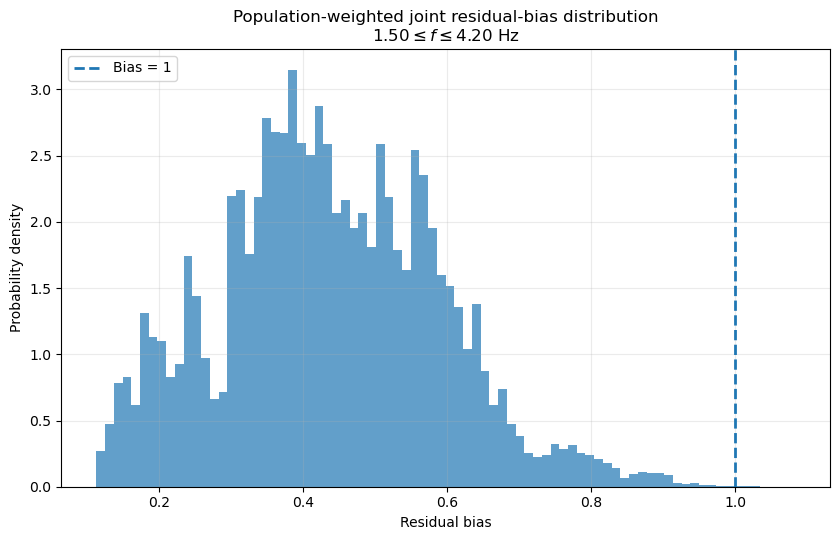


Created:
  joint_probability_summary_df
  joint_mc_df


In [44]:
# ============================================================
# TRUE POPULATION-WEIGHTED JOINT EXCEEDANCE PROBABILITY
#
# SECOND LOAD MODEL
#
# Calculates the joint probability of:
#
#     Bias > 1
#
# while jointly accounting for:
#
#     bridge frequency f
#     damping ratio xi_b
#     mass ratio mu
#     bridge material
#
#
# IMPORTANT:
#
# This is DIFFERENT from the previous frequency-only
# "any curve > 1" probability plot.
#
#
# Uses the residual-bias surface ALREADY calculated in:
#
#     probability_bias_df
#
# Therefore it automatically uses the CURRENT:
#
#     psi correction
#     P95 idealisation
#     intercept correction
#
# No P95 equation is hard-coded here.
# ============================================================


import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import (
    RegularGridInterpolator,
    LinearNDInterpolator,
)


# ============================================================
# 1. SETTINGS
# ============================================================

RANDOM_SEED = 42

N_SAMPLES = 300_000

BIAS_THRESHOLD = 1.0


# ------------------------------------------------------------
# Which residual-bias case?
#
# Use:
#
#     "bias_after_idealised_P95"
#
# for your FINAL proposed equation.
#
# You can change this to:
#
#     "bias_after_raw_P95"
#
# if you later want the joint probability for raw P95.
# ------------------------------------------------------------

BIAS_COLUMN = "bias_after_idealised_P95"


# ------------------------------------------------------------
# Population VSA range
# ------------------------------------------------------------

VSA_FMIN = 1.25
VSA_FMAX = 4.60


# ------------------------------------------------------------
# CURRENT second-load-model correction range
#
# IMPORTANT:
# your current model is 1.50–4.20 Hz,
# NOT the old 4.40 Hz.
# ------------------------------------------------------------

HSI_FMIN = 1.50
HSI_FMAX = 4.20


# ------------------------------------------------------------
# Bayesian population files
# ------------------------------------------------------------

DAMPING_CSV = (
    "master_all_bridges_vertical_damping_frequency_span_material.csv"
)

MU_PBOX_CSV = (
    "pbox_pymc_material_weighted_mass_ratio.csv"
)


EPS = 1e-12


# ============================================================
# 2. CHECK PREVIOUS PROBABILITY CELL
# ============================================================

if "probability_bias_df" not in globals():

    raise NameError(
        "probability_bias_df is missing.\n\n"
        "Run the previous bias + probability plotting cell first."
    )


if BIAS_COLUMN not in probability_bias_df.columns:

    raise KeyError(
        f"{BIAS_COLUMN} is missing from probability_bias_df."
    )


# ============================================================
# 3. MODEL DOMAIN
#
# Take directly from your CURRENT idealisation cell.
# ============================================================

required_domain_objects = [

    "MODEL2_MU_MIN",
    "MODEL2_MU_MAX",

    "MODEL2_XI_MIN",
    "MODEL2_XI_MAX",
]


missing = [

    name

    for name in required_domain_objects

    if name not in globals()
]


if missing:

    raise NameError(
        "Current P95 model-domain variables are missing:\n"
        f"{missing}"
    )


MU_MODEL_MIN = float(
    MODEL2_MU_MIN
)

MU_MODEL_MAX = float(
    MODEL2_MU_MAX
)

XI_MODEL_MIN = float(
    MODEL2_XI_MIN
)

XI_MODEL_MAX = float(
    MODEL2_XI_MAX
)


print(
    "\n============================================================"
)

print(
    "CURRENT JOINT-PROBABILITY DOMAIN"
)

print(
    "============================================================"
)


print(
    f"\nFrequency:"
    f" {HSI_FMIN:.2f} <= f <= {HSI_FMAX:.2f} Hz"
)


print(
    f"Damping:"
    f" {XI_MODEL_MIN:.4f} <= xi_b <= {XI_MODEL_MAX:.4f}"
)


print(
    f"Mass ratio:"
    f" {MU_MODEL_MIN:.4f} <= mu <= {MU_MODEL_MAX:.4f}"
)


print(
    f"\nBias column = {BIAS_COLUMN}"
)


# ============================================================
# 4. PREPARE CURRENT RESIDUAL-BIAS SURFACE
#
# We do NOT reconstruct bias.
#
# We use the exact values produced by your previous cell.
# ============================================================

joint_bias_df = (

    probability_bias_df[
        [
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
            BIAS_COLUMN,
        ]
    ]

    .copy()
)


for column in [

    "bridge_frequency",
    "target_beamdamp",
    "mass_ratio",
    BIAS_COLUMN,
]:

    joint_bias_df[
        column
    ] = pd.to_numeric(

        joint_bias_df[
            column
        ],

        errors="coerce"
    )


joint_bias_df = (

    joint_bias_df

    .dropna()

    .groupby(
        [
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
        ],
        as_index=False
    )[BIAS_COLUMN]

    .mean()

    .sort_values(
        [
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 5. KEEP CURRENT VALID MODEL DOMAIN
# ============================================================

joint_bias_df = (

    joint_bias_df[

        (
            joint_bias_df[
                "bridge_frequency"
            ]
            >=
            HSI_FMIN
        )

        &

        (
            joint_bias_df[
                "bridge_frequency"
            ]
            <=
            HSI_FMAX
        )

        &

        (
            joint_bias_df[
                "target_beamdamp"
            ]
            >=
            XI_MODEL_MIN
        )

        &

        (
            joint_bias_df[
                "target_beamdamp"
            ]
            <=
            XI_MODEL_MAX
        )

        &

        (
            joint_bias_df[
                "mass_ratio"
            ]
            >=
            MU_MODEL_MIN
        )

        &

        (
            joint_bias_df[
                "mass_ratio"
            ]
            <=
            MU_MODEL_MAX
        )

    ]

    .copy()
)


if joint_bias_df.empty:

    raise ValueError(
        "No residual-bias data remain inside the model domain."
    )


print(
    f"\nBias-surface rows = {len(joint_bias_df):,}"
)


# ============================================================
# 6. BUILD 3-D RESIDUAL-BIAS INTERPOLATOR
#
# Inputs:
#
#     f
#     xi_b
#     mu
#
# Output:
#
#     residual bias
# ============================================================

f_grid = np.sort(

    joint_bias_df[
        "bridge_frequency"
    ].unique()
)


xi_grid = np.sort(

    joint_bias_df[
        "target_beamdamp"
    ].unique()
)


mu_grid = np.sort(

    joint_bias_df[
        "mass_ratio"
    ].unique()
)


full_index = pd.MultiIndex.from_product(

    [
        f_grid,
        xi_grid,
        mu_grid,
    ],

    names=[
        "bridge_frequency",
        "target_beamdamp",
        "mass_ratio",
    ]
)


grid_series = (

    joint_bias_df

    .set_index(
        [
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
        ]
    )[BIAS_COLUMN]

    .reindex(
        full_index
    )
)


# ============================================================
# 7. REGULAR GRID IF COMPLETE
# ============================================================

if not grid_series.isna().any():


    bias_cube = (

        grid_series

        .to_numpy(
            dtype=float
        )

        .reshape(
            len(f_grid),
            len(xi_grid),
            len(mu_grid),
        )
    )


    bias_interpolator = RegularGridInterpolator(

        (
            f_grid,
            xi_grid,
            mu_grid,
        ),

        bias_cube,

        method="linear",

        bounds_error=False,

        fill_value=np.nan,
    )


    def evaluate_joint_bias(points):

        return bias_interpolator(
            points
        )


    INTERPOLATOR_TYPE = (
        "RegularGridInterpolator"
    )


# ============================================================
# 8. FALLBACK FOR INCOMPLETE GRID
# ============================================================

else:


    scattered_points = (

        joint_bias_df[
            [
                "bridge_frequency",
                "target_beamdamp",
                "mass_ratio",
            ]
        ]

        .to_numpy(
            dtype=float
        )
    )


    scattered_values = (

        joint_bias_df[
            BIAS_COLUMN
        ]

        .to_numpy(
            dtype=float
        )
    )


    scattered_interpolator = LinearNDInterpolator(

        scattered_points,

        scattered_values,

        fill_value=np.nan,
    )


    def evaluate_joint_bias(points):

        return np.asarray(

            scattered_interpolator(
                points
            )
        )


    INTERPOLATOR_TYPE = (
        "LinearNDInterpolator"
    )


print(
    "\nBias interpolator =",
    INTERPOLATOR_TYPE
)


print(
    "Bias grid = "
    f"{len(f_grid)} × "
    f"{len(xi_grid)} × "
    f"{len(mu_grid)}"
)


# ============================================================
# 9. CHECK BAYESIAN POPULATION FILES
# ============================================================

for filename in [

    DAMPING_CSV,
    MU_PBOX_CSV,
]:

    if not os.path.exists(
        filename
    ):

        raise FileNotFoundError(
            f"Cannot find:\n{filename}"
        )


# ============================================================
# 10. CLEANING FUNCTIONS
# ============================================================

def clean_numeric(series):


    s = series.astype(str)


    s = s.str.replace(
        "−",
        "-",
        regex=False
    )


    s = s.str.replace(
        "–",
        "-",
        regex=False
    )


    s = s.str.replace(
        "%",
        "",
        regex=False
    )


    s = s.str.replace(
        ",",
        "",
        regex=False
    )


    s = s.str.extract(

        r"([-+]?\d*\.?\d+"
        r"(?:[eE][-+]?\d+)?)"

    )[0]


    return pd.to_numeric(

        s,

        errors="coerce"
    )


def clean_damping(series):


    raw = (

        series

        .astype(str)

        .str.replace(
            "−",
            "-",
            regex=False
        )

        .str.replace(
            "–",
            "-",
            regex=False
        )

        .str.replace(
            "%",
            "",
            regex=False
        )
    )


    output = []


    for value in raw:


        numbers = re.findall(

            r"\d*\.?\d+(?:[eE][-+]?\d+)?",

            value
        )


        if len(numbers) == 0:

            output.append(
                np.nan
            )


        elif (

            len(numbers) >= 2

            and

            (
                "-" in value

                or

                "to" in value.lower()
            )
        ):


            output.append(

                np.mean(
                    [
                        float(
                            numbers[0]
                        ),

                        float(
                            numbers[1]
                        ),
                    ]
                )
            )


        else:

            output.append(

                float(
                    numbers[0]
                )
            )


    z = pd.Series(

        output,

        index=series.index,

        dtype=float
    )


    # --------------------------------------------------------
    # Convert percentage-looking values:
    #
    # 0.5 -> 0.005
    # 1.0 -> 0.010
    # etc.
    # --------------------------------------------------------

    percentage_like = (

        z.notna()

        &

        (
            z > 0.20
        )

        &

        (
            z <= 20.0
        )
    )


    z.loc[
        percentage_like
    ] /= 100.0


    invalid = (

        z.notna()

        &

        (
            (
                z <= 0
            )

            |

            (
                z > 0.20
            )
        )
    )


    z.loc[
        invalid
    ] = np.nan


    return z


# ============================================================
# 11. MATERIAL CLEANER
# ============================================================

MATERIAL_ORDER = [

    "Steel",

    "Concrete",

    "Steel-concrete composite",

    "FRP",

    "Timber",

    "Other",
]


def clean_material(x):


    s = str(
        x
    ).strip().lower()


    if s in [

        "",
        "nan",
        "none",
        "-",
        "unknown",
        "other",
        "other types",
    ]:

        return "Other"


    if (

        "frp" in s

        or

        "gfrp" in s

        or

        "fiber" in s

        or

        "fibre" in s

        or

        "fiberglass" in s

        or

        "fibreglass" in s

        or

        "glass fibre" in s

        or

        "glass fiber" in s
    ):

        return "FRP"


    if (

        "timber" in s

        or

        "wood" in s

        or

        "wooden" in s
    ):

        return "Timber"


    if (

        (
            "steel" in s
            and
            "concrete" in s
        )

        or

        "steel-concrete" in s

        or

        "steel concrete" in s

        or

        "composite" in s

        or

        "mixed steel" in s
    ):

        return "Steel-concrete composite"


    if (

        "concrete" in s

        or

        "reinforced concrete" in s

        or

        s == "rc"
    ):

        return "Concrete"


    if "steel" in s:

        return "Steel"


    return "Other"


def safe_material_name(
    material
):


    return (

        material

        .lower()

        .replace(
            " ",
            "_"
        )

        .replace(
            "-",
            "_"
        )
    )


# ============================================================
# 12. LOAD BRIDGE POPULATION
# ============================================================

population_df = pd.read_csv(

    DAMPING_CSV,

    encoding="utf-8-sig"
)


population_df = (

    population_df

    .dropna(
        how="all"
    )

    .copy()
)


# ============================================================
# 13. FREQUENCY COLUMN
# ============================================================

if (
    "first_vertical_frequency_Hz"
    in population_df.columns
):


    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "first_vertical_frequency_Hz"
        ]
    )


elif (
    "vertical_natural_frequency_Hz"
    in population_df.columns
):


    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "vertical_natural_frequency_Hz"
        ]
    )


else:

    raise KeyError(
        "No bridge-frequency column found."
    )


# ============================================================
# 14. MATERIAL COLUMN
# ============================================================

if (
    "material_used"
    in population_df.columns
):

    material_column = (
        "material_used"
    )


elif (
    "girder_material"
    in population_df.columns
):

    material_column = (
        "girder_material"
    )


elif (
    "material_group"
    in population_df.columns
):

    material_column = (
        "material_group"
    )


else:

    raise KeyError(
        "No material column found."
    )


population_df[
    "material"
] = (

    population_df[
        material_column
    ]

    .apply(
        clean_material
    )
)


# ============================================================
# 15. OBSERVED DAMPING
# ============================================================

if (
    "vertical_damping_ratio"
    in population_df.columns
):


    population_df[
        "observed_damping"
    ] = clean_damping(

        population_df[
            "vertical_damping_ratio"
        ]
    )


else:

    population_df[
        "observed_damping"
    ] = np.nan


# ============================================================
# 16. OBSERVED / IMPUTED FLAG
# ============================================================

if (
    "damping_observed"
    in population_df.columns
):


    flag = (

        population_df[
            "damping_observed"
        ]

        .astype(str)

        .str.strip()

        .str.lower()
    )


    population_df[
        "damping_observed_flag"
    ] = flag.isin(

        [
            "true",
            "1",
            "yes",
        ]
    )


else:


    population_df[
        "damping_observed_flag"
    ] = (

        population_df[
            "observed_damping"
        ]

        .notna()
    )


# ============================================================
# 17. IMPUTED DAMPING POSTERIOR MEAN + SD
# ============================================================

if (
    "zeta_imputed_mean"
    in population_df.columns
):


    population_df[
        "imputed_mean"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_mean"
        ]
    )


else:

    population_df[
        "imputed_mean"
    ] = np.nan


if (
    "zeta_imputed_sd"
    in population_df.columns
):


    population_df[
        "imputed_sd"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_sd"
        ]
    )


else:

    population_df[
        "imputed_sd"
    ] = np.nan


# ------------------------------------------------------------
# Fallback completed mean
# ------------------------------------------------------------

if (
    "zeta_completed_mean"
    in population_df.columns
):


    completed_mean = clean_numeric(

        population_df[
            "zeta_completed_mean"
        ]
    )


    missing_mean = (

        population_df[
            "imputed_mean"
        ]

        .isna()
    )


    population_df.loc[
        missing_mean,
        "imputed_mean"
    ] = completed_mean.loc[
        missing_mean
    ]


# ============================================================
# 18. ALL USABLE BRIDGES
# ============================================================

population_df = (

    population_df[

        np.isfinite(
            population_df[
                "frequency"
            ]
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_ALL = len(
    population_df
)


if N_ALL == 0:

    raise ValueError(
        "No usable bridge frequencies."
    )


# ============================================================
# 19. VSA POPULATION
# ============================================================

vsa_mask = (

    (
        population_df[
            "frequency"
        ]
        >=
        VSA_FMIN
    )

    &

    (
        population_df[
            "frequency"
        ]
        <=
        VSA_FMAX
    )
)


vsa_df = (

    population_df[
        vsa_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_VSA = len(
    vsa_df
)


P_VSA = (

    N_VSA

    /

    N_ALL
)


# ============================================================
# 20. CURRENT HSI / P95 FREQUENCY POPULATION
#
# 1.50 <= f <= 4.20
# ============================================================

hsi_mask = (

    (
        vsa_df[
            "frequency"
        ]
        >=
        HSI_FMIN
    )

    &

    (
        vsa_df[
            "frequency"
        ]
        <=
        HSI_FMAX
    )
)


hsi_df = (

    vsa_df[
        hsi_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_HSI = len(
    hsi_df
)


if N_HSI == 0:

    raise ValueError(
        "No bridges inside the current HSI frequency range."
    )


P_HSI_GIVEN_VSA = (

    N_HSI

    /

    N_VSA
)


P_HSI_ALL = (

    N_HSI

    /

    N_ALL
)


print(
    "\n============================================================"
)

print(
    "FREQUENCY POPULATION"
)

print(
    "============================================================"
)


print(
    f"\nAll bridges = {N_ALL}"
)


print(
    f"VSA bridges = {N_VSA}"
)


print(
    f"HSI-range bridges = {N_HSI}"
)


print(
    f"\nP(VSA) = "
    f"{P_VSA:.6f} "
    f"= {100*P_VSA:.3f}%"
)


print(
    f"P(HSI range | VSA) = "
    f"{P_HSI_GIVEN_VSA:.6f} "
    f"= {100*P_HSI_GIVEN_VSA:.3f}%"
)


# ============================================================
# 21. LOAD MASS-RATIO BAYESIAN P-BOX
# ============================================================

mu_pbox_df = pd.read_csv(

    MU_PBOX_CSV,

    encoding="utf-8-sig"
)


mu_pbox_df[
    "T"
] = pd.to_numeric(

    mu_pbox_df[
        "T"
    ],

    errors="coerce"
)


mu_pbox_df = (

    mu_pbox_df

    .dropna(
        subset=[
            "T"
        ]
    )

    .sort_values(
        "T"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 22. MATERIAL-SPECIFIC MU DISTRIBUTIONS
#
# theta(T) = P(mu < T | material)
# ============================================================

mu_models = {}


mu_summary_rows = []


for material in MATERIAL_ORDER:


    safe = safe_material_name(
        material
    )


    theta_column = (

        f"{safe}_theta_mean"
    )


    n_known_column = (

        f"{safe}_n_known"
    )


    if theta_column not in (
        mu_pbox_df.columns
    ):

        continue


    if n_known_column not in (
        mu_pbox_df.columns
    ):

        continue


    n_known_values = pd.to_numeric(

        mu_pbox_df[
            n_known_column
        ],

        errors="coerce"

    ).dropna()


    if len(
        n_known_values
    ) == 0:

        continue


    n_known = int(

        round(
            n_known_values.iloc[0]
        )
    )


    # --------------------------------------------------------
    # Do not use prior-only material distributions
    # --------------------------------------------------------

    if n_known <= 0:

        continue


    T = pd.to_numeric(

        mu_pbox_df[
            "T"
        ],

        errors="coerce"

    ).to_numpy(
        dtype=float
    )


    F = pd.to_numeric(

        mu_pbox_df[
            theta_column
        ],

        errors="coerce"

    ).to_numpy(
        dtype=float
    )


    valid = (

        np.isfinite(
            T
        )

        &

        np.isfinite(
            F
        )
    )


    T = T[
        valid
    ]


    F = F[
        valid
    ]


    order = np.argsort(
        T
    )


    T = T[
        order
    ]


    F = F[
        order
    ]


    # enforce monotonic CDF
    F = np.maximum.accumulate(
        F
    )


    F = np.clip(
        F,
        0.0,
        1.0
    )


    # ========================================================
    # Probability mu is inside current correction domain
    # ========================================================

    F_mu_min = float(

        np.interp(

            MU_MODEL_MIN,

            T,

            F
        )
    )


    F_mu_max = float(

        np.interp(

            MU_MODEL_MAX,

            T,

            F
        )
    )


    P_mu_inside = max(

        0.0,

        F_mu_max
        -
        F_mu_min
    )


    if P_mu_inside <= EPS:

        continue


    # ========================================================
    # CONDITIONAL mu DISTRIBUTION INSIDE DOMAIN
    # ========================================================

    internal_T = T[

        (
            T > MU_MODEL_MIN
        )

        &

        (
            T < MU_MODEL_MAX
        )
    ]


    edges = np.unique(

        np.concatenate(

            [
                [
                    MU_MODEL_MIN
                ],

                internal_T,

                [
                    MU_MODEL_MAX
                ],
            ]
        )
    )


    F_edges = np.interp(

        edges,

        T,

        F
    )


    F_edges = np.maximum.accumulate(
        F_edges
    )


    bin_probability = np.diff(
        F_edges
    )


    bin_probability = np.maximum(

        bin_probability,

        0.0
    )


    if np.sum(
        bin_probability
    ) <= EPS:

        continue


    weights = (

        bin_probability

        /

        np.sum(
            bin_probability
        )
    )


    mu_models[
        material
    ] = {

        "n_known":
            n_known,

        "P_inside":
            P_mu_inside,

        "edges":
            edges,

        "weights":
            weights,
    }


    mu_summary_rows.append({

        "Material":
            material,

        "n known mu":
            n_known,

        "P(mu inside current domain)":
            P_mu_inside,
    })


mu_model_summary_df = pd.DataFrame(
    mu_summary_rows
)


print(
    "\n============================================================"
)

print(
    "MASS-RATIO MODELS"
)

print(
    "============================================================\n"
)


print(

    mu_model_summary_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"
    )
)


# ============================================================
# 23. DAMPING SAMPLER
# ============================================================

def sample_lognormal_from_mean_sd(
    mean,
    sd,
    rng,
):


    mean = np.asarray(
        mean,
        dtype=float
    )


    sd = np.asarray(
        sd,
        dtype=float
    )


    output = np.full(

        len(mean),

        np.nan,

        dtype=float
    )


    deterministic = (

        np.isfinite(
            mean
        )

        &

        (
            mean > 0
        )

        &

        (
            ~np.isfinite(
                sd
            )

            |

            (
                sd <= 0
            )
        )
    )


    output[
        deterministic
    ] = mean[
        deterministic
    ]


    stochastic = (

        np.isfinite(
            mean
        )

        &

        (
            mean > 0
        )

        &

        np.isfinite(
            sd
        )

        &

        (
            sd > 0
        )
    )


    if np.any(
        stochastic
    ):


        m = mean[
            stochastic
        ]


        s = sd[
            stochastic
        ]


        sigma2_log = np.log(

            1.0

            +

            (
                s / m
            )**2
        )


        sigma_log = np.sqrt(
            sigma2_log
        )


        mu_log = (

            np.log(
                m
            )

            -

            0.5
            *
            sigma2_log
        )


        output[
            stochastic
        ] = rng.lognormal(

            mean=
                mu_log,

            sigma=
                sigma_log
        )


    return output


# ============================================================
# 24. MONTE CARLO
#
# Sample actual bridge rows from HSI-frequency population.
#
# This preserves the observed relationship between:
#
#     frequency
#     material
#     damping information
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)


sample_indices = rng.choice(

    hsi_df.index.to_numpy(),

    size=
        N_SAMPLES,

    replace=
        True
)


sample_df = (

    hsi_df.loc[
        sample_indices
    ]

    .reset_index(
        drop=True
    )
)


f_samples = (

    sample_df[
        "frequency"
    ]

    .to_numpy(
        dtype=float
    )
)


material_samples = (

    sample_df[
        "material"
    ]

    .to_numpy()
)


# ============================================================
# 25. SAMPLE DAMPING
# ============================================================

observed_flag = (

    sample_df[
        "damping_observed_flag"
    ]

    .to_numpy(
        dtype=bool
    )
)


observed_xi = (

    sample_df[
        "observed_damping"
    ]

    .to_numpy(
        dtype=float
    )
)


imputed_mean = (

    sample_df[
        "imputed_mean"
    ]

    .to_numpy(
        dtype=float
    )
)


imputed_sd = (

    sample_df[
        "imputed_sd"
    ]

    .to_numpy(
        dtype=float
    )
)


xi_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


use_observed = (

    observed_flag

    &

    np.isfinite(
        observed_xi
    )
)


xi_samples[
    use_observed
] = observed_xi[
    use_observed
]


use_imputed = (
    ~use_observed
)


xi_samples[
    use_imputed
] = sample_lognormal_from_mean_sd(

    mean=
        imputed_mean[
            use_imputed
        ],

    sd=
        imputed_sd[
            use_imputed
        ],

    rng=
        rng
)


# ============================================================
# 26. SAMPLE MASS RATIO
#
# Material-specific Bayesian population model.
# ============================================================

material_mu_supported = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_inside = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


for material in np.unique(
    material_samples
):


    indices = np.flatnonzero(

        material_samples
        ==
        material
    )


    if material not in mu_models:

        continue


    material_mu_supported[
        indices
    ] = True


    model = mu_models[
        material
    ]


    # ========================================================
    # First decide whether mu lies inside model domain
    # ========================================================

    inside_local = (

        rng.random(
            len(indices)
        )

        <

        model[
            "P_inside"
        ]
    )


    inside_indices = indices[
        inside_local
    ]


    mu_inside[
        inside_indices
    ] = True


    if len(
        inside_indices
    ) == 0:

        continue


    # ========================================================
    # Sample actual mu conditional on being in domain
    # ========================================================

    weights = model[
        "weights"
    ]


    edges = model[
        "edges"
    ]


    bin_index = rng.choice(

        np.arange(
            len(weights)
        ),

        size=
            len(
                inside_indices
            ),

        replace=
            True,

        p=
            weights
    )


    lower = edges[
        bin_index
    ]


    upper = edges[
        bin_index + 1
    ]


    mu_samples[
        inside_indices
    ] = rng.uniform(

        low=
            lower,

        high=
            upper
    )


# ============================================================
# 27. CHECK DAMPING DOMAIN
# ============================================================

xi_inside = (

    np.isfinite(
        xi_samples
    )

    &

    (
        xi_samples
        >=
        XI_MODEL_MIN
    )

    &

    (
        xi_samples
        <=
        XI_MODEL_MAX
    )
)


# ============================================================
# 28. COMPLETE JOINT MODEL DOMAIN
# ============================================================

complete_domain = (

    material_mu_supported

    &

    mu_inside

    &

    xi_inside

    &

    np.isfinite(
        mu_samples
    )
)


# ============================================================
# 29. EVALUATE JOINT RESIDUAL BIAS
# ============================================================

sampled_bias = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


points = np.column_stack(

    [

        f_samples[
            complete_domain
        ],

        xi_samples[
            complete_domain
        ],

        mu_samples[
            complete_domain
        ],
    ]
)


sampled_bias[
    complete_domain
] = evaluate_joint_bias(
    points
)


valid_bias = (

    complete_domain

    &

    np.isfinite(
        sampled_bias
    )
)


# ============================================================
# 30. JOINT EXCEEDANCE EVENT
#
# Now each event corresponds to one sampled:
#
#     (f, xi_b, mu)
#
# combination.
# ============================================================

exceedance = (

    valid_bias

    &

    (
        sampled_bias
        >
        BIAS_THRESHOLD
    )
)


N_VALID = int(

    np.sum(
        valid_bias
    )
)


N_EXCEED = int(

    np.sum(
        exceedance
    )
)


if N_VALID == 0:

    raise ValueError(
        "No Monte Carlo samples fell inside "
        "the complete joint model domain."
    )


# ============================================================
# 31. CONDITIONAL JOINT PROBABILITY
#
# Probability of B>1 given that:
#
# f is in HSI range,
# xi is in model domain,
# mu is in model domain.
# ============================================================

P_B_GT1_GIVEN_VALID = (

    N_EXCEED

    /

    N_VALID
)


# ============================================================
# 32. DOMAIN PROBABILITY AMONG HSI BRIDGES
# ============================================================

P_VALID_DOMAIN_GIVEN_HSI = (

    N_VALID

    /

    N_SAMPLES
)


# ============================================================
# 33. JOINT EXCEEDANCE MASS AMONG HSI BRIDGES
#
# THIS is:
#
# P(valid xi-mu domain AND B>1 | HSI frequency)
#
# It is NOT the frequency-envelope approximation.
# ============================================================

P_JOINT_EXCEED_GIVEN_HSI = (

    N_EXCEED

    /

    N_SAMPLES
)


# mathematical check

P_JOINT_CHECK = (

    P_VALID_DOMAIN_GIVEN_HSI

    *

    P_B_GT1_GIVEN_VALID
)


# ============================================================
# 34. JOINT PROBABILITY RELATIVE TO VSA BRIDGES
#
# P(
#     HSI-frequency
#     AND valid xi-mu domain
#     AND B>1
#     |
#     VSA
# )
# ============================================================

P_JOINT_EXCEED_GIVEN_VSA = (

    P_HSI_GIVEN_VSA

    *

    P_JOINT_EXCEED_GIVEN_HSI
)


# ============================================================
# 35. JOINT PROBABILITY RELATIVE TO ALL BRIDGES
# ============================================================

P_JOINT_EXCEED_ALL = (

    P_VSA

    *

    P_HSI_GIVEN_VSA

    *

    P_JOINT_EXCEED_GIVEN_HSI
)


# ============================================================
# 36. MONTE CARLO STANDARD ERRORS
# ============================================================

MC_SE_CONDITIONAL = np.sqrt(

    P_B_GT1_GIVEN_VALID

    *

    (
        1.0
        -
        P_B_GT1_GIVEN_VALID
    )

    /

    N_VALID
)


MC_SE_HSI = np.sqrt(

    P_JOINT_EXCEED_GIVEN_HSI

    *

    (
        1.0
        -
        P_JOINT_EXCEED_GIVEN_HSI
    )

    /

    N_SAMPLES
)


# ============================================================
# 37. RESULTS
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "JOINT POPULATION PROBABILITY OF BIAS > 1"
)

print(
    "============================================================"
)


print(
    "\nMonte Carlo draws = "
    f"{N_SAMPLES:,}"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "1. VALID JOINT PARAMETER DOMAIN"
)

print(
    "------------------------------------------------------------"
)


print(
    f"\nP(valid xi-mu domain | HSI frequency)"
    f"\n= {P_VALID_DOMAIN_GIVEN_HSI:.8f}"
    f"\n= {100*P_VALID_DOMAIN_GIVEN_HSI:.4f}%"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "2. BIAS > 1 GIVEN VALID JOINT DOMAIN"
)

print(
    "------------------------------------------------------------"
)


print(
    f"\nN valid = {N_VALID:,}"
)


print(
    f"N Bias > 1 = {N_EXCEED:,}"
)


print(
    f"\nP(Bias>1 | HSI frequency, valid xi-mu domain)"
    f"\n= {P_B_GT1_GIVEN_VALID:.8f}"
    f"\n= {100*P_B_GT1_GIVEN_VALID:.4f}%"
)


print(
    f"\nMonte Carlo SE = "
    f"{100*MC_SE_CONDITIONAL:.4f} percentage points"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "3. JOINT EXCEEDANCE AMONG HSI-FREQUENCY BRIDGES"
)

print(
    "------------------------------------------------------------"
)


print(
    "\nP(valid xi-mu domain AND Bias>1 | HSI frequency)"
)


print(
    f"\n= {P_JOINT_EXCEED_GIVEN_HSI:.8f}"
)


print(
    f"= {100*P_JOINT_EXCEED_GIVEN_HSI:.4f}%"
)


print(
    "\nCheck:"
)


print(
    f"{P_VALID_DOMAIN_GIVEN_HSI:.8f}"
    f" × "
    f"{P_B_GT1_GIVEN_VALID:.8f}"
    f" = "
    f"{P_JOINT_CHECK:.8f}"
)


print(
    "\n============================================================"
)

print(
    "KEY RESULT — JOINT PROBABILITY RELATIVE TO VSA BRIDGES"
)

print(
    "============================================================"
)


print(
    "\nP("
    "HSI frequency, "
    "valid xi-mu domain, "
    "Bias>1 "
    "| VSA"
    ")"
)


print(
    f"\n= {P_HSI_GIVEN_VSA:.8f}"
    f" × "
    f"{P_JOINT_EXCEED_GIVEN_HSI:.8f}"
)


print(
    f"\n= {P_JOINT_EXCEED_GIVEN_VSA:.10f}"
)


print(
    f"= {100*P_JOINT_EXCEED_GIVEN_VSA:.5f}% "
    f"of VSA bridges"
)


print(
    "\n============================================================"
)

print(
    "JOINT PROBABILITY RELATIVE TO ALL BRIDGES"
)

print(
    "============================================================"
)


print(
    "\nP("
    "VSA, "
    "HSI frequency, "
    "valid xi-mu domain, "
    "Bias>1"
    ")"
)


print(
    f"\n= {P_JOINT_EXCEED_ALL:.10f}"
)


print(
    f"= {100*P_JOINT_EXCEED_ALL:.5f}% "
    f"of all bridges"
)


# ============================================================
# 38. SUMMARY TABLE
# ============================================================

joint_probability_summary_df = pd.DataFrame({

    "Quantity": [

        "P(VSA)",

        "P(HSI frequency | VSA)",

        "P(valid xi-mu domain | HSI)",

        "P(Bias>1 | HSI + valid xi-mu domain)",

        "P(valid domain AND Bias>1 | HSI)",

        "P(HSI + valid domain + Bias>1 | VSA)",

        "P(VSA + HSI + valid domain + Bias>1)",
    ],

    "Probability": [

        P_VSA,

        P_HSI_GIVEN_VSA,

        P_VALID_DOMAIN_GIVEN_HSI,

        P_B_GT1_GIVEN_VALID,

        P_JOINT_EXCEED_GIVEN_HSI,

        P_JOINT_EXCEED_GIVEN_VSA,

        P_JOINT_EXCEED_ALL,
    ],
})


joint_probability_summary_df[
    "Probability [%]"
] = (

    100.0

    *

    joint_probability_summary_df[
        "Probability"
    ]
)


print(
    "\n============================================================"
)

print(
    "SUMMARY"
)

print(
    "============================================================\n"
)


print(

    joint_probability_summary_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.7f}"
    )
)


# ============================================================
# 39. SAVE MONTE CARLO DRAWS IN MEMORY
# ============================================================

joint_mc_df = pd.DataFrame({

    "frequency":
        f_samples,

    "material":
        material_samples,

    "damping":
        xi_samples,

    "mass_ratio":
        mu_samples,

    "valid_joint_domain":
        valid_bias,

    "residual_bias":
        sampled_bias,

    "Bias_gt_1":
        exceedance,
})


# ============================================================
# 40. PLOT POPULATION-WEIGHTED RESIDUAL BIAS DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(

    figsize=(
        8.5,
        5.5
    )
)


ax.hist(

    sampled_bias[
        valid_bias
    ],

    bins=
        80,

    density=
        True,

    alpha=
        0.70
)


ax.axvline(

    BIAS_THRESHOLD,

    linestyle=
        "--",

    linewidth=
        2.0,

    label=
        "Bias = 1"
)


ax.set_xlabel(
    "Residual bias"
)


ax.set_ylabel(
    "Probability density"
)


ax.set_title(

    "Population-weighted joint residual-bias distribution\n"

    rf"${HSI_FMIN:.2f}\leq f\leq{HSI_FMAX:.2f}$ Hz"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend()


plt.tight_layout()

plt.show()


print(
    "\nCreated:"
)

print(
    "  joint_probability_summary_df"
)

print(
    "  joint_mc_df"
)

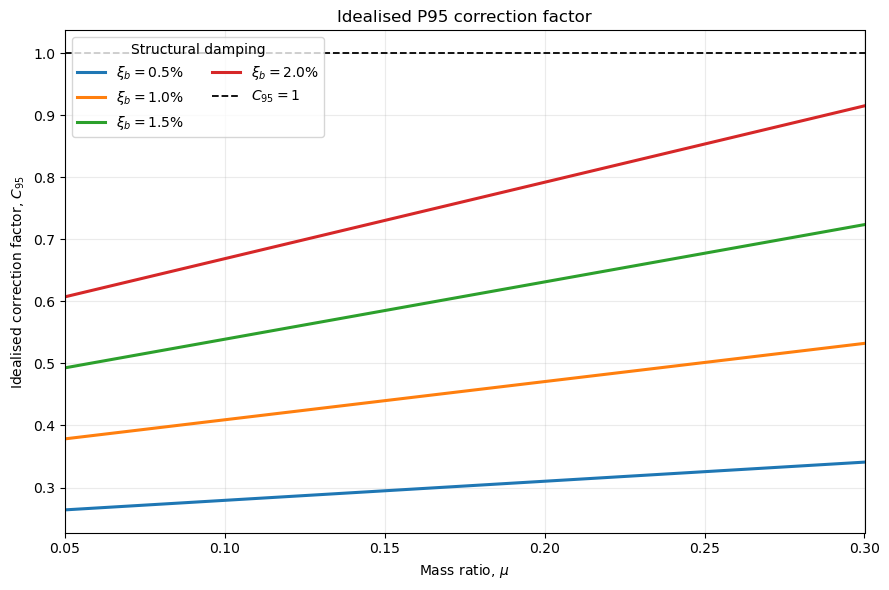

In [45]:
# ============================================================
# PLOT IDEALISED P95 CORRECTION FACTOR
#
# C95_final(mu, xi_b)
#
# x-axis  = mass ratio, mu
# y-axis  = idealised correction factor
# lines   = damping ratios
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

# Use damping values actually present in the calibration data
damping_values = sorted(
    model2_surface_df["xi_b"].unique()
)

# Smooth mass-ratio axis across calibrated domain
mu_plot = np.linspace(
    MODEL2_MU_MIN,
    MODEL2_MU_MAX,
    500
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.0, 6.0)
)


for xi_b in damping_values:

    xi_plot = np.full_like(
        mu_plot,
        xi_b
    )

    C95_plot = C95_model2_final(
        mu_plot,
        xi_plot
    )

    ax.plot(
        mu_plot,
        C95_plot,
        linewidth=2.2,
        label=rf"$\xi_b={100*xi_b:.1f}\%$"
    )


# ============================================================
# REFERENCE LINE
# ============================================================

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label=r"$C_{95}=1$"
)


# ============================================================
# FORMAT
# ============================================================

ax.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax.set_ylabel(
    r"Idealised correction factor, $C_{95}$"
)

ax.set_title(
    "Idealised P95 correction factor"
)

ax.set_xlim(
    MODEL2_MU_MIN,
    MODEL2_MU_MAX
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    title="Structural damping",
    ncol=2
)

plt.tight_layout()
plt.show()